In [1]:
#!/usr/bin/env python3
"""
RSA Lag Analysis — All Regions, Band × Pair (Long Format)
----------------------------------------------------------
Regions : LHP, RHP, LLTC, RLTC, LMTL, RMTL

Bands   : theta  (4–8 Hz,    freq idx 2–4  → 4.67, 5.82, 7.26 Hz)
          alpha  (8–12 Hz,   freq idx 4–6  → 7.26, 9.05, 11.28 Hz)
          beta   (12–40 Hz,  freq idx 7–11 → 14.07–34.03 Hz)
          gamma  (40–128 Hz, freq idx 12–17→ 42.44–128.00 Hz)

  NOTE on theta/alpha boundary: 7.26 Hz (idx 4) falls in both bands.
  This is intentional — theta ends at ~8 Hz, alpha starts at ~8 Hz,
  and the nearest log-spaced bin straddles the boundary.
  If you want strict non-overlapping bands, remove idx 4 from one.

For every trial × region × recall pair (i, j) with i < j × band:

  RSA_r_ret         : Pearson r between retrieval osc vectors at output pos i and j
  RSA_r_enc         : Pearson r between encoding  osc vectors at serial pos of i and j
  RSA_r_enc_i_ret_j : Pearson r between encoding  osc of word i  ×  retrieval osc of word j
  RSA_r_enc_j_ret_i : Pearson r between encoding  osc of word j  ×  retrieval osc of word i

Output (one master CSV per experiment):
  ./rsa_lag_allregions/ALL_SUBJECTS_{exp}_allregions_allbands_rsa_lag.csv

18 log-spaced frequencies (3–128 Hz):
  idx:  0     1     2     3     4     5      6      7      8
  Hz:  3.00  3.74  4.67  5.82  7.26  9.05  11.28  14.07  17.55
  idx:  9     10    11    12    13    14    15     16     17
  Hz: 21.88 27.29 34.03 42.44 52.92 66.00 82.31 102.64 128.00
"""

import warnings
import traceback
from pathlib import Path
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS = ['DBOY1', 'EFRCourierReadOnly', 'EFRCourierOpenLoop']

INPUT_DIRS = {
    'DBOY1':               Path('./subject_results_DBOY1'),
    'EFRCourierReadOnly':  Path('./subject_results_EFRCourierReadOnly'),
    'EFRCourierOpenLoop':  Path('./subject_results_EFRCourierOpenLoop'),
}

OUTPUT_DIR = Path('./rsa_lag_allregions')
OUTPUT_DIR.mkdir(exist_ok=True)

# All six regions
REGIONS = ['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']

HEMISPHERE = {
    'LHP':  'left',
    'RHP':  'right',
    'LLTC': 'left',
    'RLTC': 'right',
    'LMTL': 'left',
    'RMTL': 'right',
}

# 18 log-spaced frequencies 3–128 Hz
N_FREQS = 18

# Band definitions — freq indices into the 18-element IRASA vector
# theta: 4–8 Hz  → indices 2,3,4  (4.67, 5.82, 7.26 Hz)
# alpha: 8–12 Hz → indices 4,5,6  (7.26, 9.05, 11.28 Hz)
# beta : 12–40 Hz→ indices 7–11   (14.07–34.03 Hz)
# gamma: 40+     → indices 12–17  (42.44–128.00 Hz)
BANDS = {
    'theta': list(range(2, 5)),   # 4.67 – 7.26 Hz
    'alpha': list(range(5, 7)),   # 7.26 – 11.28 Hz
    'beta':  list(range(7, 12)),  # 14.07 – 34.03 Hz
    'gamma': list(range(12, 18)), # 42.44 – 128.00 Hz
}
BAND_ORDER = ['theta', 'alpha', 'beta', 'gamma']

RET_OSC_COLS = [f'ret_osc_f{i:02d}' for i in range(N_FREQS)]
ENC_OSC_COLS = [f'enc_osc_f{i:02d}' for i in range(N_FREQS)]

# Word2Vec
WORD2VEC_PATH = Path('/home1/noaherz/word2vec/GoogleNews-vectors-negative300.bin.gz')

OUTPUT_COLS = [
    'subject', 'session', 'experiment', 'trial',
    'region', 'hemisphere',
    'band', 'band_freq_indices',
    'output_pos_i', 'output_pos_j', 'output_lag',
    'word_i', 'word_j',
    'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag',
    'RSA_r_ret',          # ret_i  × ret_j
    'RSA_r_enc',          # enc_i  × enc_j
    'RSA_r_enc_i_ret_j',  # enc_i  × ret_j
    'RSA_r_enc_j_ret_i',  # enc_j  × ret_i
    'n_channels', 'semantic_sim',
]

# ============================================================================
# WORD2VEC
# ============================================================================

def load_word2vec(path: Path):
    if path is None or not path.exists():
        print(f"  ⚠  Word2Vec model not found at {path}. semantic_sim will be NaN.")
        return None
    try:
        import gensim.models as gensim_models
        print(f"  Loading Word2Vec from {path} …")
        model = gensim_models.KeyedVectors.load_word2vec_format(str(path), binary=True)
        try:
            vs = len(model)
        except TypeError:
            vs = len(model.vocab)
        print(f"  ✓ Word2Vec loaded — vocab: {vs:,}")
        return model
    except Exception as e:
        print(f"  ✗ Word2Vec load failed: {e}. semantic_sim will be NaN.")
        return None


def case_insensitive_similarity(word1: str, word2: str, model) -> Optional[float]:
    cases = [
        (word1.lower(), word2.lower()),
        (word1.lower(), word2.upper()),
        (word1.upper(), word2.lower()),
        (word1.upper(), word2.upper()),
    ]
    sims = []
    for w1, w2 in cases:
        try:
            sims.append(model.similarity(w1, w2))
        except KeyError:
            continue
    return float(max(sims)) if sims else None


def build_similarity_cache(words: set, model) -> dict:
    if model is None:
        return {}
    unique_words = sorted(w for w in words if isinstance(w, str))
    n = len(unique_words)
    print(f"    Building semsim cache: {n} words → {n*(n-1)//2} pairs …")
    cache = {}
    for i, w1 in enumerate(unique_words):
        for w2 in unique_words[i:]:
            key = frozenset({w1, w2})
            if key not in cache:
                sim = case_insensitive_similarity(w1, w2, model)
                cache[key] = sim if sim is not None else np.nan
    return cache


# ============================================================================
# VECTOR + STATISTICS HELPERS
# ============================================================================

def build_band_vector(recall_rows: pd.DataFrame,
                      channel_index: list,
                      band_freq_indices: list,
                      phase_cols: list) -> np.ndarray:
    """
    Build a 1-D vector for one event and one band:
      1. Align rows to channel_index       → (N_ch, 18) matrix
      2. Slice to band_freq_indices        → (N_ch, N_band_freqs) sub-matrix
      3. Flatten                           → (N_ch * N_band_freqs,) vector

    phase_cols : either RET_OSC_COLS or ENC_OSC_COLS (18 elements)
    Missing channels filled with NaN, handled pairwise in safe_pearsonr.
    """
    ch_df = (
        recall_rows
        .drop_duplicates(subset='channel_idx')
        .set_index('channel_idx')
        .reindex(channel_index)
    )
    band_cols = [phase_cols[i] for i in band_freq_indices]
    mat = ch_df[band_cols].values   # (N_ch, N_band_freqs)
    return mat.flatten()


def safe_pearsonr(v1: np.ndarray, v2: np.ndarray) -> float:
    """Pearson r ignoring NaN positions; returns NaN if fewer than 3 valid pairs."""
    if len(v1) != len(v2):
        return np.nan
    mask = np.isfinite(v1) & np.isfinite(v2)
    if mask.sum() < 3:
        return np.nan
    r, _ = pearsonr(v1[mask], v2[mask])
    return float(r)


def safe_euclidean(x1, z1, x2, z2) -> float:
    if any(not np.isfinite(v) for v in (x1, z1, x2, z2)):
        return np.nan
    return float(euclidean([x1, z1], [x2, z2]))


def extract_scalar(series: pd.Series, field: str, context: str):
    unique_vals = series.dropna().unique()
    if len(unique_vals) > 1:
        warnings.warn(
            f"[{context}] '{field}' has {len(unique_vals)} distinct values "
            f"({unique_vals[:3]}…). Taking first.")
    return series.iloc[0]


# ============================================================================
# TRIAL-LEVEL PROCESSING
# ============================================================================

def process_trial_region(trial_df: pd.DataFrame,
                         region: str,
                         sim_cache: dict) -> List[Dict]:
    """
    For one (subject, session, trial, region):
      - Enumerate all valid recall pairs (i, j), i < j (by output position)
      - For each pair × each band compute 4 RSA measures:
            RSA_r_ret         : ret_i  × ret_j
            RSA_r_enc         : enc_i  × enc_j
            RSA_r_enc_i_ret_j : enc_i  × ret_j
            RSA_r_enc_j_ret_i : enc_j  × ret_i
      - Returns list of dicts in OUTPUT_COLS order (long format)

    Encoding vectors carry the IRASA values from the encoding epoch of the
    presented word at that serial position, as written by the channel-wide
    pipeline — so enc_osc on the rows for output_pos == op_i already corresponds
    to the encoding of that recalled word.
    """
    rows = []

    output_positions = sorted(
        trial_df['recall_output_position'].unique(),
        key=lambda x: int(x),
    )
    if len(output_positions) < 2:
        return rows

    channel_index = sorted(trial_df['channel_idx'].unique(), key=int)
    sample_row    = trial_df.iloc[0]

    # ------------------------------------------------------------------
    # Pre-compute per-output-position metadata + per-band vectors
    # (retrieval AND encoding) so we only build each vector once
    # ------------------------------------------------------------------
    pos_data: Dict[int, Dict] = {}

    for op in output_positions:
        op_rows = trial_df[trial_df['recall_output_position'] == op]
        ctx = (f"subj={sample_row['subject']} sess={sample_row['session']} "
               f"trial={sample_row['trial']} region={region} op={op}")

        word       = extract_scalar(op_rows['recalled_word'],   'recalled_word',   ctx)
        serial_pos = extract_scalar(op_rows['serial_position'], 'serial_position', ctx)
        store_x    = extract_scalar(op_rows['store_x'],         'store_x',         ctx)
        store_z    = extract_scalar(op_rows['store_z'],         'store_z',         ctx)
        n_ch       = op_rows['channel_idx'].nunique()

        ret_band_vectors = {
            band_name: build_band_vector(op_rows, channel_index, freq_idx, RET_OSC_COLS)
            for band_name, freq_idx in BANDS.items()
        }
        enc_band_vectors = {
            band_name: build_band_vector(op_rows, channel_index, freq_idx, ENC_OSC_COLS)
            for band_name, freq_idx in BANDS.items()
        }

        pos_data[op] = {
            'ret_band_vectors': ret_band_vectors,
            'enc_band_vectors': enc_band_vectors,
            'word':             word,
            'serial_pos':       serial_pos,
            'store_x':          store_x,
            'store_z':          store_z,
            'n_channels':       n_ch,
        }

    subject    = sample_row['subject']
    session    = sample_row['session']
    experiment = sample_row['experiment']
    trial      = sample_row['trial']
    hemi       = HEMISPHERE.get(region, 'unknown')

    # ------------------------------------------------------------------
    # Enumerate pairs × bands
    # ------------------------------------------------------------------
    for idx_i, op_i in enumerate(output_positions):
        for op_j in output_positions[idx_i + 1:]:
            d_i = pos_data[op_i]
            d_j = pos_data[op_j]

            output_lag = int(op_j) - int(op_i)
            T_lag      = abs(int(d_i['serial_pos']) - int(d_j['serial_pos']))
            SP_lag     = safe_euclidean(d_i['store_x'], d_i['store_z'],
                                        d_j['store_x'], d_j['store_z'])
            n_channels = min(d_i['n_channels'], d_j['n_channels'])

            # Semantic similarity — identical across bands, compute once per pair
            w_i = str(d_i['word']).lower() if pd.notna(d_i['word']) else None
            w_j = str(d_j['word']).lower() if pd.notna(d_j['word']) else None
            sem_sim = (
                sim_cache.get(frozenset({w_i, w_j}), np.nan)
                if (w_i and w_j and sim_cache)
                else np.nan
            )

            # One row per band
            for band_name in BAND_ORDER:
                freq_idx = BANDS[band_name]

                v_ret_i = d_i['ret_band_vectors'][band_name]
                v_ret_j = d_j['ret_band_vectors'][band_name]
                v_enc_i = d_i['enc_band_vectors'][band_name]
                v_enc_j = d_j['enc_band_vectors'][band_name]

                rows.append({
                    'subject':           subject,
                    'session':           session,
                    'experiment':        experiment,
                    'trial':             trial,
                    'region':            region,
                    'hemisphere':        hemi,
                    'band':              band_name,
                    'band_freq_indices': str(freq_idx),
                    'output_pos_i':      op_i,
                    'output_pos_j':      op_j,
                    'output_lag':        output_lag,
                    'word_i':            d_i['word'],
                    'word_j':            d_j['word'],
                    'serial_pos_i':      d_i['serial_pos'],
                    'serial_pos_j':      d_j['serial_pos'],
                    'T_lag':             T_lag,
                    'SP_lag':            SP_lag,
                    'RSA_r_ret':          safe_pearsonr(v_ret_i, v_ret_j),
                    'RSA_r_enc':          safe_pearsonr(v_enc_i, v_enc_j),
                    'RSA_r_enc_i_ret_j':  safe_pearsonr(v_enc_i, v_ret_j),
                    'RSA_r_enc_j_ret_i':  safe_pearsonr(v_enc_j, v_ret_i),
                    'n_channels':        n_channels,
                    'semantic_sim':      sem_sim,
                })

    return rows


# ============================================================================
# PER-EXPERIMENT RUNNER
# ============================================================================

def run_experiment(exp: str, w2v_model):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {exp}")
    print(f"{'='*70}")

    input_dir  = INPUT_DIRS.get(exp)
    if input_dir is None:
        print(f"  ✗ No INPUT_DIR configured for '{exp}'.")
        return

    input_path = input_dir / f"ALL_SUBJECTS_{exp}_irasa_channel_wide.csv"
    if not input_path.exists():
        print(f"  ✗ Master CSV not found: {input_path}")
        return

    print(f"  Loading {input_path} …")
    df = pd.read_csv(input_path)
    print(f"  Loaded {len(df):,} rows | "
          f"{df['subject'].nunique()} subjects | "
          f"{df['session'].nunique()} sessions")

    # Filter to the 6 regions upfront
    df = df[df['region'].isin(REGIONS)].copy()
    print(f"  After region filter ({REGIONS}): {len(df):,} rows")
    if df.empty:
        print("  ✗ No matching data — check 'region' column values.")
        print(f"    Regions present in file: {df['region'].unique().tolist()}")
        return

    df['channel_idx'] = df['channel_idx'].astype(int)

    # Build Word2Vec cache once per experiment across all regions
    all_words_lower = set(
        df['recalled_word'].dropna().astype(str).str.lower().unique()
    )
    sim_cache = build_similarity_cache(all_words_lower, w2v_model)

    all_region_rows = []

    for region in REGIONS:
        print(f"\n  {'─'*60}")
        print(f"  Region: {region}")

        region_df = df[df['region'] == region].copy()
        if region_df.empty:
            print(f"  ✗ No rows for region {region} — skipping")
            continue

        print(f"  Rows: {len(region_df):,}")

        all_rows = []
        groups   = region_df.groupby(['subject', 'session', 'trial'])
        n_groups = len(groups)

        for g_idx, ((subj, sess, trial), trial_df) in enumerate(groups):
            if g_idx % 200 == 0:
                print(f"    Processing trial group {g_idx}/{n_groups} …")
            try:
                rows = process_trial_region(trial_df, region, sim_cache)
                all_rows.extend(rows)
            except Exception as e:
                print(f"    FAILED [{subj} sess={sess} trial={trial}]: {e}")
                traceback.print_exc()
                continue

        if not all_rows:
            print(f"  ✗ No pairs generated for region {region}")
            continue

        result_df = pd.DataFrame(all_rows, columns=OUTPUT_COLS)
        all_region_rows.append(result_df)

        # Per-region summary
        print(f"  ✓ {region}: {len(result_df):,} pair-band rows")
        for band_name in BAND_ORDER:
            b = result_df[result_df['band'] == band_name]
            print(
                f"    {band_name:6s}: {len(b):7,} pairs | "
                f"RSA_ret NaN={b['RSA_r_ret'].isna().mean()*100:.1f}% | "
                f"RSA_enc NaN={b['RSA_r_enc'].isna().mean()*100:.1f}% | "
                f"cross NaN={b['RSA_r_enc_i_ret_j'].isna().mean()*100:.1f}%"
            )

    # ── Master CSV: all regions × all bands ──────────────────────────────────
    if all_region_rows:
        master_df  = pd.concat(all_region_rows, ignore_index=True)
        master_path = OUTPUT_DIR / f"ALL_SUBJECTS_{exp}_allregions_allbands_rsa_lag.csv"
        master_df.to_csv(master_path, index=False)

        print(f"\n  {'='*60}")
        print(f"  ✓ Master CSV → {master_path.name}")
        print(f"    Rows       : {len(master_df):,}")
        print(f"    Subjects   : {master_df['subject'].nunique()}")
        print(f"    Sessions   : {master_df['session'].nunique()}")
        print(f"    Regions    : {sorted(master_df['region'].unique())}")
        print(f"    Bands      : {master_df['band'].unique().tolist()}")
        print(f"    RSA_ret  NaN: {master_df['RSA_r_ret'].isna().mean()*100:.1f}%")
        print(f"    RSA_enc  NaN: {master_df['RSA_r_enc'].isna().mean()*100:.1f}%")
        print(f"    cross_ij NaN: {master_df['RSA_r_enc_i_ret_j'].isna().mean()*100:.1f}%")
        print(f"    cross_ji NaN: {master_df['RSA_r_enc_j_ret_i'].isna().mean()*100:.1f}%")
        print(f"    SemSim   NaN: {master_df['semantic_sim'].isna().mean()*100:.1f}%")
    else:
        print(f"\n  ✗ No rows produced for {exp} — master CSV not written")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    w2v_model = load_word2vec(WORD2VEC_PATH)

    for exp in EXPERIMENTS:
        run_experiment(exp, w2v_model)

    print(f"\n{'='*70}")
    print("✓ ALL EXPERIMENTS COMPLETE")
    print(f"{'='*70}")

  Loading Word2Vec from /home1/noaherz/word2vec/GoogleNews-vectors-negative300.bin.gz …
  ✓ Word2Vec loaded — vocab: 3,000,000

EXPERIMENT: DBOY1
  Loading subject_results_DBOY1/ALL_SUBJECTS_DBOY1_irasa_channel_wide.csv …
  Loaded 59,568 rows | 40 subjects | 8 sessions
  After region filter (['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']): 53,318 rows
    Building semsim cache: 234 words → 27261 pairs …

  ────────────────────────────────────────────────────────────
  Region: LHP
  Rows: 10,827
    Processing trial group 0/179 …
  ✓ LHP: 7,256 pair-band rows
    theta :   1,814 pairs | RSA_ret NaN=0.0% | RSA_enc NaN=0.0% | cross NaN=0.0%
    alpha :   1,814 pairs | RSA_ret NaN=16.7% | RSA_enc NaN=16.7% | cross NaN=16.7%
    beta  :   1,814 pairs | RSA_ret NaN=0.0% | RSA_enc NaN=0.0% | cross NaN=0.0%
    gamma :   1,814 pairs | RSA_ret NaN=0.0% | RSA_enc NaN=0.0% | cross NaN=0.0%

  ────────────────────────────────────────────────────────────
  Region: RHP
  Rows: 7,692
    Processing t

In [22]:
import pandas as pd
df = pd.read_csv('./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv', nrows=2)
print(df.columns.tolist())

['subject', 'session', 'experiment', 'trial', 'region', 'hemisphere', 'band', 'band_freq_indices', 'output_pos_i', 'output_pos_j', 'output_lag', 'word_i', 'word_j', 'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag', 'RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i', 'n_channels', 'semantic_sim']


In [ ]:
#!/usr/bin/env python3
"""
LMM Analysis: T_lag / SP_lag → RSA (all measures)
All Regions × All Bands × All Outcomes
----------------------------------------------------------------------
Input : ./rsa_lag_allregions/ALL_SUBJECTS_{exp}_allregions_allbands_rsa_lag.csv

Regions  : LHP, RHP, LLTC, RLTC, LMTL, RMTL
Bands    : theta, alpha, beta, gamma
Outcomes : RSA_r_ret         — retrieval  × retrieval  (both words at retrieval)
           RSA_r_enc         — encoding   × encoding   (both words at encoding)
           RSA_r_enc_i_ret_j — encoding of word i × retrieval of word j
           RSA_r_enc_j_ret_i — encoding of word j × retrieval of word i

Models (per outcome × predictor × band × region):
  Model 1 (bare)      : outcome ~ predictor
  Model 2 (controlled): outcome ~ predictor + cross_covariate + output_lag [+ semantic_sim]

Random effects: nested session within subject
  groups     = subject
  vc_formula = {'subj_sess': '0 + C(subj_sess)'}

FDR: BH correction within each model across its terms.

Outputs (per experiment, under ./rsa_lag_lmm_allregions/):
  LMM_{region}_{predictor}_{band}_{outcome}_results.csv / .txt
  plots/forest_{...}.png
  plots/interaction_{...}.png
  plots/summary_heatmap_{region}_{outcome}.png
  plots/beta_bars_{region}_{outcome}.png
  LMM_ALL_results.csv   — master file, all regions × outcomes × bands
"""

import warnings
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_1samp
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection
 
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENT = 'DBOY1'

INPUT_DIR  = Path('./rsa_lag_allregions')
OUTPUT_DIR = Path('./rsa_lag_lmm_allregions')
PLOT_DIR   = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# All 6 regions from the RSA pipeline
REGIONS = ['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']

# All 4 RSA outcome columns
OUTCOMES = [
    'RSA_r_ret',          # retrieval  × retrieval
    'RSA_r_enc',          # encoding   × encoding
    'RSA_r_enc_i_ret_j',  # enc(word i) × ret(word j)
    'RSA_r_enc_j_ret_i',  # enc(word j) × ret(word i)
]
OUTCOME_LABELS = {
    'RSA_r_ret':          'Retrieval RSA  (ret_i × ret_j)',
    'RSA_r_enc':          'Encoding RSA   (enc_i × enc_j)',
    'RSA_r_enc_i_ret_j':  'Cross RSA  (enc_i × ret_j)',
    'RSA_r_enc_j_ret_i':  'Cross RSA  (enc_j × ret_i)',
}

PREDICTORS = ['SP_lag', 'T_lag']
BANDS      = ['theta', 'alpha', 'beta', 'gamma']

CROSS_COVARIATE = {
    'T_lag':  'SP_lag',
    'SP_lag': 'T_lag',
}
PRED_LABELS = {
    'T_lag':  'Temporal Lag (T_lag)',
    'SP_lag': 'Spatial Lag (SP_lag)',
}
MODEL_LABELS = {
    'Model1': 'Bare',
    'Model2': 'Controlled',
}

# ---- Palette ----------------------------------------------------------------
BG_COLOR    = 'white'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
TEXT_COLOR  = '#222222'
SPINE_COLOR = '#AAAAAA'

REGION_COLORS = {
    'LHP':  '#1A3A6B',
    'RHP':  '#8B1A1A',
    'LLTC': '#1A6B3A',
    'RLTC': '#6B3A1A',
    'LMTL': '#3A1A6B',
    'RMTL': '#6B1A5A',
}
BAND_COLORS = {
    'theta': '#4575B4',
    'alpha': '#74ADD1',
    'beta':  '#F46D43',
    'gamma': '#D73027',
}

# ============================================================================
# LMM FITTING
# ============================================================================

def fit_lmm(df: pd.DataFrame,
            pred_cols: List[str],
            label: str,
            outcome: str,
            formula_rhs: Optional[str] = None) -> Tuple[Optional[object], int]:
    df = df.copy()
    df['subj_sess'] = (df['subject'].astype(str)
                       + '_' + df['session'].astype(str))

    real_cols = [c for c in pred_cols if c in df.columns]
    keep      = [outcome] + real_cols + ['subject', 'subj_sess']
    df        = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    rhs     = formula_rhs if formula_rhs else ' + '.join(pred_cols)
    formula = f"{outcome} ~ {rhs}"
    print(f"    [{label}] {formula}  |  N={len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'},
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            if np.isfinite(result.llf):
                print(f"    [{label}] optimizer={method}  "
                      f"converged={getattr(result, 'converged', None)}  "
                      f"llf={result.llf:.4f}  AIC={result.aic:.4f}")
                break
            else:
                print(f"    [{label}] llf=NaN with {method}, trying next …")
        except Exception as e:
            print(f"    [{label}] {method} failed: {e}")
            result = None

    if result is None or not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: fit unsuccessful.")
    return result, len(df)


# ============================================================================
# RESULT EXTRACTION
# ============================================================================

def extract_rows(result,
                 pred_display: Dict[str, str],
                 model_label: str,
                 predictor: str,
                 band: str,
                 region: str,
                 outcome: str) -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits    = [k for k in result.params.index
                       if col.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            print(f"    WARNING: '{col}' not found in params — skipping")
            continue
        rows.append({
            'experiment':            EXPERIMENT,
            'outcome':               outcome,
            'region':                region,
            'predictor_of_interest': predictor,
            'band':                  band,
            'model':                 model_label,
            'term':                  name,
            'col':                   col,
            'beta':                  result.params[matched],
            'se':                    result.bse[matched],
            'z':                     result.tvalues[matched],
            'p_raw':                 result.pvalues[matched],
            'llf':                   result.llf,
            'aic':                   result.aic,
            'nobs':                  int(result.nobs),
        })
    return pd.DataFrame(rows)


def apply_fdr_within_model(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    _, df['p_fdr'] = fdrcorrection(df['p_raw'].values)
    return df


# ============================================================================
# TEXT FORMATTING
# ============================================================================

def sig_stars(p: float) -> str:
    return ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else
            '†'   if p < 0.10  else '')


def format_block(title: str, rows_df: pd.DataFrame, outcome: str) -> str:
    sep  = '=' * 92
    sep2 = '-' * 92
    hdr  = (f"{'Term':<40} {'β':>8} {'SE':>8} {'z':>8} "
            f"{'p_raw':>10} {'p_fdr':>10} {'AIC':>10} {'N':>8} {'sig':>5}")
    lines = [sep, title, sep2, hdr, sep2]
    for _, row in rows_df.iterrows():
        aic_s = (f"{row['aic']:>10.2f}"
                 if pd.notna(row.get('aic')) else '       NaN')
        p_fdr = row.get('p_fdr', np.nan)
        lines.append(
            f"{row['term']:<40} {row['beta']:>8.4f} {row['se']:>8.4f} "
            f"{row['z']:>8.3f} {row['p_raw']:>10.4f} "
            f"{p_fdr:>10.4f} {aic_s} {int(row['nobs']):>8,} "
            f"{sig_stars(p_fdr):>5}"
        )
    lines += [sep2,
              'FDR: BH correction within each model across terms.',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              f'Outcome = {outcome}.  Experiment = {EXPERIMENT}.',
              'All continuous predictors on raw scale.',
              sep]
    return '\n'.join(lines)


# ============================================================================
# PLOTTING HELPERS
# ============================================================================

def _style_ax(ax):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8.5)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
        spine.set_linewidth(0.8)


def plot_forest(all_results: pd.DataFrame,
                region: str,
                predictor: str,
                band: str,
                outcome: str,
                save_path: Path):
    df = all_results[
        (all_results['region']                == region) &
        (all_results['predictor_of_interest'] == predictor) &
        (all_results['band']                  == band) &
        (all_results['outcome']               == outcome) &
        (all_results['col']                   == predictor)
    ].copy()

    if df.empty:
        return

    df['ci_lo'] = df['beta'] - 1.96 * df['se']
    df['ci_hi'] = df['beta'] + 1.96 * df['se']

    models = [m for m in ['Model1', 'Model2'] if m in df['model'].values]
    color  = REGION_COLORS.get(region, '#444444')

    fig, ax = plt.subplots(figsize=(9, max(3, len(models) * 1.4 + 1)))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    y_pos, yticks, ylabels = 0, [], []
    for model in models:
        row = df[df['model'] == model]
        if row.empty:
            continue
        row  = row.iloc[0]
        xerr = [[row['beta'] - row['ci_lo']], [row['ci_hi'] - row['beta']]]
        ax.errorbar(row['beta'], y_pos, xerr=xerr,
                    fmt='o', color=color, ecolor=color,
                    elinewidth=1.5, capsize=4, capthick=1.5,
                    markersize=7, zorder=3)
        p_show = row.get('p_fdr', row['p_raw'])
        stars  = sig_stars(p_show)
        if stars:
            offset = abs(row['ci_hi'] - row['beta']) * 0.15 + 0.001
            ax.text(row['ci_hi'] + offset, y_pos, stars,
                    color=color, va='center', fontsize=9, fontweight='bold')
        yticks.append(y_pos)
        ylabels.append(MODEL_LABELS.get(model, model))
        y_pos -= 1

    ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel(f'β  ({PRED_LABELS[predictor]})', fontsize=10)
    ax.set_title(
        f"{region}  |  {OUTCOME_LABELS[outcome]} ~ {PRED_LABELS[predictor]}  |  "
        f"{band.capitalize()} band  [{EXPERIMENT}]",
        fontsize=10, fontweight='bold', pad=8)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"    ✓ Forest → {save_path.name}")


def _subject_slopes(hd: pd.DataFrame,
                    predictor: str,
                    outcome: str) -> pd.DataFrame:
    rows = []
    for subj, sg in hd.groupby('subject'):
        sg = sg.dropna(subset=[predictor, outcome])
        if len(sg) < 3:
            continue
        x = sg[predictor].values.astype(float)
        y = sg[outcome].values.astype(float)
        if x.std() == 0:
            continue
        m, b = np.polyfit(x, y, 1)
        rows.append({'subject': subj, 'slope': m,
                     'intercept': b, 'n_pairs': len(sg)})
    return pd.DataFrame(rows)


def _subject_zscore_rsa(hd: pd.DataFrame, outcome: str) -> pd.DataFrame:
    hd = hd.copy()
    def zscore(x):
        s = x.std()
        return (x - x.mean()) / s if s > 0 else x - x.mean()
    hd[f'{outcome}_z'] = hd.groupby('subject')[outcome].transform(zscore)
    return hd


def plot_interaction(region: str,
                     predictor: str,
                     band: str,
                     outcome: str,
                     raw_df: pd.DataFrame,
                     save_path: Path):
    outcome_z = f'{outcome}_z'

    sub_df = raw_df[
        raw_df['band'] == band
    ].copy().dropna(subset=[predictor, outcome])

    if sub_df.empty:
        return

    color       = REGION_COLORS.get(region, '#444444')
    is_discrete = (predictor == 'T_lag')

    fig, (ax_sp, ax_sl) = plt.subplots(2, 1, figsize=(10, 10))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax_sp)
    _style_ax(ax_sl)

    n_subj  = sub_df['subject'].nunique()
    n_pairs = len(sub_df)

    x_all = sub_df[predictor].values.astype(float)
    y_all = sub_df[outcome].values.astype(float)
    r_val, p_val = pearsonr(x_all, y_all)
    p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'

    hd = _subject_zscore_rsa(sub_df, outcome)

    if is_discrete:
        MAX_VALS = 20
        top_vals = sorted(
            hd[predictor].value_counts().nlargest(MAX_VALS).index.tolist())
        x_grid = np.array(top_vals, dtype=float)
    else:
        N_BINS     = 12
        hd['_bin'] = pd.cut(hd[predictor], bins=N_BINS)
        bin_mids   = (hd.groupby('_bin', observed=True)[predictor]
                       .mean().dropna())
        x_grid     = bin_mids.values

    subj_lines = []
    for subj, sg in hd.groupby('subject'):
        sg = sg.dropna(subset=[predictor, outcome_z])
        if len(sg) < 3:
            continue
        if is_discrete:
            pts = (sg.groupby(predictor)[outcome_z]
                     .mean().reindex(top_vals))
        else:
            pts = (sg.groupby('_bin', observed=True)[outcome_z].mean())
            pts.index = pts.index.map(
                lambda b: b.mid if hasattr(b, 'mid') else np.nan)
            pts = pts.dropna()
        pts = pts.dropna()
        if len(pts) < 2:
            continue
        subj_lines.append(pts.values)
        ax_sp.plot(x_grid[:len(pts.values)], pts.values,
                   color=color, alpha=0.15, lw=0.9, zorder=2)

    if subj_lines:
        max_len  = max(len(s) for s in subj_lines)
        padded   = np.array([
            np.pad(s.astype(float), (0, max_len - len(s)),
                   constant_values=np.nan)
            for s in subj_lines
        ])
        grp_mean = np.nanmean(padded, axis=0)
        grp_sem  = (np.nanstd(padded, axis=0)
                    / np.sqrt((~np.isnan(padded)).sum(axis=0)))
        xg = x_grid[:max_len]

        ax_sp.fill_between(xg, grp_mean - grp_sem, grp_mean + grp_sem,
                           color=color, alpha=0.20, zorder=3)
        ax_sp.plot(xg, grp_mean, color=color, lw=2.5, zorder=4,
                   label=f'Group mean ± SEM  (n={n_subj} subj)')

        valid = np.isfinite(grp_mean) & np.isfinite(xg)
        if valid.sum() >= 2:
            m_z, b_z = np.polyfit(xg[valid], grp_mean[valid], 1)
            ax_sp.plot(xg[valid], m_z * xg[valid] + b_z,
                       color=TEXT_COLOR, lw=1.5, ls='--', alpha=0.6,
                       zorder=5, label=f'OLS  r={r_val:.3f} {p_str}')

    ax_sp.axhline(0, color=SPINE_COLOR, lw=1, ls=':', zorder=1)
    if is_discrete:
        ax_sp.set_xticks(x_grid)
        ax_sp.set_xticklabels(
            [str(int(v)) for v in x_grid], fontsize=7,
            rotation=45 if len(x_grid) > 12 else 0)
    ax_sp.set_xlabel(PRED_LABELS[predictor], fontsize=9)
    ax_sp.set_ylabel(f'{outcome}  (z-scored within subject)', fontsize=9)
    ax_sp.set_title(
        f'{region}  |  {band.capitalize()} band  |  {EXPERIMENT}\n'
        f'Outcome: {OUTCOME_LABELS[outcome]}  |  '
        f'n={n_subj} subj, {n_pairs:,} pairs',
        fontsize=10, fontweight='bold')
    ax_sp.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=8)

    slopes_df = _subject_slopes(hd, predictor, outcome)

    if slopes_df.empty:
        ax_sl.set_visible(False)
    else:
        slopes     = slopes_df['slope'].values
        n_sl       = len(slopes)
        mean_slope = slopes.mean()
        sem_slope  = slopes.std() / np.sqrt(n_sl)
        ci95       = 1.96 * sem_slope
        n_neg      = (slopes < 0).sum()
        n_pos      = (slopes > 0).sum()

        order      = np.argsort(slopes)
        y_pos_sl   = np.arange(n_sl)
        dot_colors = [REGION_COLORS.get(region, '#444444')
                      if s >= 0 else '#888888'
                      for s in slopes[order]]

        ax_sl.scatter(slopes[order], y_pos_sl,
                      c=dot_colors, s=40, zorder=3,
                      edgecolors='white', linewidths=0.4)
        for yi, si, dc in zip(y_pos_sl, slopes[order], dot_colors):
            ax_sl.plot([0, si], [yi, yi],
                       color=dc, alpha=0.35, lw=0.8, zorder=2)

        ax_sl.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
        ax_sl.axvspan(mean_slope - ci95, mean_slope + ci95,
                      color=color, alpha=0.12, zorder=0)
        ax_sl.axvline(mean_slope, color=color, lw=2.5, zorder=4,
                      label=f'Mean β={mean_slope:.4f} ± {ci95:.4f} (95%CI)')

        t_stat, p_1samp = ttest_1samp(slopes, 0)
        p1_str = f'p={p_1samp:.3f}' if p_1samp >= 0.001 else 'p<0.001'
        stars  = sig_stars(p_1samp)
        ax_sl.text(mean_slope, n_sl + 0.3,
                   f'{stars}  {p1_str}' if stars else p1_str,
                   ha='center', va='bottom',
                   color=color, fontsize=9, fontweight='bold')

        ax_sl.set_yticks([])
        ax_sl.set_xlabel(
            f'Subject-level OLS slope  ({outcome} ~ {predictor})', fontsize=9)
        ax_sl.set_title(
            f'{region}  |  {band.capitalize()} band  |  {OUTCOME_LABELS[outcome]}\n'
            f'Each dot = 1 subject  '
            f'({n_neg}/{n_sl} negative, {n_pos}/{n_sl} positive)',
            fontsize=10, fontweight='bold')
        ax_sl.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=8)
        pct_neg = n_neg / n_sl * 100
        ax_sl.text(0.02, 0.04,
                   f'{pct_neg:.0f}% of subjects show negative slope',
                   transform=ax_sl.transAxes,
                   fontsize=8, color=TEXT_COLOR, style='italic')

    fig.suptitle(
        f"{outcome} ~ {PRED_LABELS[predictor]}  |  {region}  |  "
        f"{band.capitalize()} band\n"
        f"Top: z-scored spaghetti  |  Bottom: per-subject slopes",
        fontsize=12, fontweight='bold', y=1.01, color=TEXT_COLOR)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"    ✓ Interaction → {save_path.name}")


def plot_summary_heatmap(all_results: pd.DataFrame,
                         region: str,
                         outcome: str,
                         save_path: Path):
    """β heatmap: rows = predictors, cols = bands, Model 1 only."""
    pivot_rows = []
    for pred in PREDICTORS:
        for band in BANDS:
            sub = all_results[
                (all_results['region']                == region) &
                (all_results['predictor_of_interest'] == pred) &
                (all_results['band']                  == band) &
                (all_results['outcome']               == outcome) &
                (all_results['model']                 == 'Model1') &
                (all_results['col']                   == pred)
            ]
            if sub.empty:
                beta, stars = np.nan, ''
            else:
                r     = sub.iloc[0]
                beta  = r['beta']
                stars = sig_stars(r.get('p_fdr', r['p_raw']))
            pivot_rows.append({'predictor': PRED_LABELS[pred],
                                'band': band, 'beta': beta, 'stars': stars})

    piv       = pd.DataFrame(pivot_rows)
    beta_mat  = piv.pivot(index='predictor', columns='band', values='beta')[BANDS]
    stars_mat = piv.pivot(index='predictor', columns='band', values='stars')[BANDS]

    fig, ax = plt.subplots(figsize=(9, 3.0))
    fig.patch.set_facecolor(BG_COLOR)
    vmax = np.nanmax(np.abs(beta_mat.values)) or 1.0
    im   = ax.imshow(beta_mat.values.astype(float),
                     aspect='auto', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax)

    for i in range(beta_mat.shape[0]):
        for j in range(beta_mat.shape[1]):
            val  = beta_mat.values[i, j]
            star = stars_mat.values[i, j]
            if not np.isnan(val):
                cell_norm = (val + vmax) / (2 * vmax)
                txt_color = 'white' if (cell_norm < 0.35 or cell_norm > 0.65) else TEXT_COLOR
                ax.text(j, i, f"{val:.3f}\n{star}",
                        ha='center', va='center',
                        color=txt_color, fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(BANDS)))
    ax.set_xticklabels([b.capitalize() for b in BANDS], fontsize=10)
    ax.set_yticks(range(len(beta_mat.index)))
    ax.set_yticklabels(beta_mat.index.tolist(), fontsize=9)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label(f'β  (predictor → {outcome})', fontsize=9, color=TEXT_COLOR)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_COLOR)

    ax.set_title(
        f'{region}  |  {OUTCOME_LABELS[outcome]} ~ predictor  |  '
        f'β (Model 1)  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold', pad=8, color=TEXT_COLOR)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Heatmap → {save_path.name}")


def plot_beta_bars(all_results: pd.DataFrame,
                   region: str,
                   outcome: str,
                   save_path: Path):
    """Bar chart of β by band, one column per predictor, two rows (Model1/2)."""
    n_cols = len(PREDICTORS)
    fig, axes = plt.subplots(2, n_cols, figsize=(7 * n_cols, 8))
    fig.patch.set_facecolor(BG_COLOR)
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    x     = np.arange(len(BANDS))
    width = 0.50

    for col_idx, pred in enumerate(PREDICTORS):
        for row_idx, model_key in enumerate(['Model1', 'Model2']):
            ax = axes[row_idx, col_idx]
            _style_ax(ax)

            betas, errors, pvals = [], [], []
            for band in BANDS:
                sub = all_results[
                    (all_results['region']                == region) &
                    (all_results['predictor_of_interest'] == pred) &
                    (all_results['outcome']               == outcome) &
                    (all_results['model']                 == model_key) &
                    (all_results['band']                  == band) &
                    (all_results['col']                   == pred)
                ]
                if sub.empty:
                    betas.append(np.nan); errors.append(0); pvals.append(1.0)
                else:
                    r = sub.iloc[0]
                    betas.append(r['beta'])
                    errors.append(r['se'])
                    pvals.append(r.get('p_fdr', r['p_raw']))

            plot_betas  = [b if np.isfinite(b) else 0 for b in betas]
            plot_errors = [e if np.isfinite(betas[i]) else 0
                           for i, e in enumerate(errors)]

            bars = ax.bar(x, plot_betas, width,
                          color=[BAND_COLORS[b] for b in BANDS],
                          yerr=plot_errors,
                          error_kw=dict(ecolor=TEXT_COLOR, capsize=3, elinewidth=1),
                          alpha=0.82)

            for bar, beta, p in zip(bars, betas, pvals):
                if not np.isfinite(beta):
                    continue
                stars = sig_stars(p)
                if stars:
                    h    = bar.get_height()
                    sign = 1 if h >= 0 else -1
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            h + sign * max(abs(h) * 0.05, 0.005),
                            stars, ha='center', va='bottom',
                            color=TEXT_COLOR, fontsize=9, fontweight='bold')

            ax.axhline(0, color=SPINE_COLOR, lw=1.0, ls='--')
            ax.set_xticks(x)
            ax.set_xticklabels([b.capitalize() for b in BANDS], fontsize=9)
            ax.set_xlabel('Frequency Band', fontsize=9)
            ax.set_ylabel('β', fontsize=9)
            ax.set_title(
                f"{region}  |  {outcome} ~ {PRED_LABELS[pred]}\n"
                f"[{MODEL_LABELS[model_key]}]",
                fontsize=9, fontweight='bold')

    fig.suptitle(
        f'{region}  |  {OUTCOME_LABELS[outcome]} ~ T_lag / SP_lag  |  '
        f'β by Frequency Band  [{EXPERIMENT}]',
        fontsize=12, fontweight='bold', y=1.01, color=TEXT_COLOR)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Beta bars → {save_path.name}")


def plot_region_comparison(all_results: pd.DataFrame,
                            outcome: str,
                            predictor: str,
                            band: str,
                            save_path: Path):
    """
    Cross-region forest plot for one outcome × predictor × band combo.
    One row per region, showing Model1 and Model2 β side by side.
    Useful for quickly comparing e.g. LHP vs LLTC in theta-band T_lag.
    """
    sub = all_results[
        (all_results['outcome']               == outcome) &
        (all_results['predictor_of_interest'] == predictor) &
        (all_results['band']                  == band) &
        (all_results['col']                   == predictor)
    ].copy()

    if sub.empty:
        return

    sub['ci_lo'] = sub['beta'] - 1.96 * sub['se']
    sub['ci_hi'] = sub['beta'] + 1.96 * sub['se']

    regions_present = [r for r in REGIONS if r in sub['region'].values]
    n_regions = len(regions_present)
    if n_regions == 0:
        return

    fig, ax = plt.subplots(figsize=(10, max(4, n_regions * 1.6 + 1.5)))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    y_pos   = 0
    yticks  = []
    ylabels = []
    offsets = {'Model1': -0.18, 'Model2': 0.18}
    markers = {'Model1': 'o', 'Model2': 's'}

    for region in regions_present:
        color = REGION_COLORS.get(region, '#444444')
        for model_key in ['Model1', 'Model2']:
            row = sub[(sub['region'] == region) & (sub['model'] == model_key)]
            if row.empty:
                continue
            row  = row.iloc[0]
            yp   = y_pos + offsets[model_key]
            xerr = [[row['beta'] - row['ci_lo']], [row['ci_hi'] - row['beta']]]
            ax.errorbar(row['beta'], yp, xerr=xerr,
                        fmt=markers[model_key], color=color, ecolor=color,
                        elinewidth=1.4, capsize=3, capthick=1.4,
                        markersize=6, zorder=3,
                        label=f'{region} {MODEL_LABELS[model_key]}'
                              if y_pos == 0 else '')
            p_show = row.get('p_fdr', row['p_raw'])
            stars  = sig_stars(p_show)
            if stars:
                offset_x = abs(row['ci_hi'] - row['beta']) * 0.15 + 0.001
                ax.text(row['ci_hi'] + offset_x, yp, stars,
                        color=color, va='center', fontsize=8, fontweight='bold')

        yticks.append(y_pos)
        ylabels.append(region)
        y_pos -= 1

    ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.set_xlabel(f'β  ({PRED_LABELS[predictor]})', fontsize=10)
    ax.set_title(
        f"All regions  |  {OUTCOME_LABELS[outcome]} ~ {PRED_LABELS[predictor]}\n"
        f"{band.capitalize()} band  |  ○ = Bare  □ = Controlled  [{EXPERIMENT}]",
        fontsize=10, fontweight='bold', pad=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Region comparison → {save_path.name}")


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data() -> Optional[pd.DataFrame]:
    fpath = INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv"

    if not fpath.exists():
        print(f"  ✗ Master CSV not found: {fpath}")
        return None

    print(f"  Loading {fpath.name} …")
    df = pd.read_csv(fpath)
    print(f"  Loaded {len(df):,} rows")

    # Verify all expected outcome columns are present
    missing_outcomes = [o for o in OUTCOMES if o not in df.columns]
    if missing_outcomes:
        print(f"  ✗ Missing outcome columns: {missing_outcomes}")
        print(f"    Columns present: {df.columns.tolist()}")
        return None

    # Filter to configured regions
    df = df[df['region'].isin(REGIONS)].copy()
    print(f"  After region filter {REGIONS}: {len(df):,} rows")

    if df.empty:
        print("  ✗ No data after filtering.")
        return None

    # Prefix subject IDs to avoid collisions across sessions
    df['subject'] = EXPERIMENT + '_' + df['subject'].astype(str)

    print(f"\n  Rows         : {len(df):,}")
    print(f"  Subjects     : {df['subject'].nunique()}")
    print(f"  Regions      : {sorted(df['region'].unique().tolist())}")
    print(f"  Bands        : {sorted(df['band'].unique().tolist())}")
    print(f"  Outcomes     : {[o for o in OUTCOMES if o in df.columns]}")
    return df


# ============================================================================
# PER-COMBINATION ANALYSIS
# ============================================================================

def run_analysis_for_combination(df: pd.DataFrame,
                                  region: str,
                                  predictor: str,
                                  band: str,
                                  outcome: str,
                                  has_semsim: bool
                                  ) -> Tuple[pd.DataFrame, str]:
    """
    Fit Model1 and Model2 for one (region, predictor, band, outcome) cell.
    Returns (result_df, text_report).
    """
    sub = df[
        (df['region'] == region) &
        (df['band']   == band)
    ].copy()

    if sub.empty:
        return pd.DataFrame(), ""

    print(f"\n  ── {region}  |  {outcome} ~ {predictor}  |  {band.capitalize()} ──")
    print(f"     Rows: {len(sub):,}  |  Subjects: {sub['subject'].nunique()}")

    all_rows    = []
    text_blocks = [
        f"EXPERIMENT: {EXPERIMENT}  OUTCOME: {outcome}  "
        f"REGION: {region}  PREDICTOR: {predictor}  BAND: {band}",
        f"N rows: {len(sub):,}  |  subjects: {sub['subject'].nunique()}\n",
    ]

    cross_cov   = CROSS_COVARIATE[predictor]
    cross_label = PRED_LABELS[cross_cov]

    def run_and_collect(real_cols, model_key, title, pred_display,
                        formula_rhs=None):
        res, _ = fit_lmm(sub, real_cols, model_key, outcome,
                         formula_rhs=formula_rhs)
        rows   = extract_rows(res, pred_display, model_key,
                              predictor, band, region, outcome)
        rows   = apply_fdr_within_model(rows)
        if not rows.empty:
            all_rows.append(rows)
            block = format_block(title, rows, outcome)
            text_blocks.append(block)
            print('\n' + block)
        return res

    # Model 1: bare
    run_and_collect(
        [predictor],
        'Model1',
        f'Model 1 — {outcome} ~ {predictor}  [{region} / {band}]',
        {predictor: PRED_LABELS[predictor]},
    )

    # Model 2: controlled for cross-covariate + output_lag [+ semantic_sim]
    ctrl_cols = [predictor, cross_cov, 'output_lag']
    ctrl_disp = {
        predictor:    PRED_LABELS[predictor],
        cross_cov:    f'{cross_label}  [covariate]',
        'output_lag': 'output_lag  [covariate]',
    }
    if has_semsim:
        ctrl_cols.append('semantic_sim')
        ctrl_disp['semantic_sim'] = 'semantic_sim  [covariate]'

    run_and_collect(
        ctrl_cols,
        'Model2',
        f'Model 2 — {outcome} ~ {predictor} + {cross_cov} + controls  '
        f'[{region} / {band}]',
        ctrl_disp,
    )

    result_df = (pd.concat(all_rows, ignore_index=True)
                 if all_rows else pd.DataFrame())
    return result_df, '\n\n'.join(text_blocks)


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*80}")
    print(f"RSA ~ T_lag / SP_lag  |  All Regions  |  {EXPERIMENT}")
    print(f"Outcomes  : {OUTCOMES}")
    print(f"Predictors: {PREDICTORS}")
    print(f"Bands     : {BANDS}")
    print(f"Regions   : {REGIONS}")
    print(f"{'='*80}")

    df = load_data()
    if df is None or df.empty:
        print("No data loaded. Exiting.")
        return

    has_semsim = ('semantic_sim' in df.columns
                  and df['semantic_sim'].notna().any())
    print(f"\n  semantic_sim available: {has_semsim}")

    ALL_RESULTS = []

    # ── Outer loop: outcome → region → predictor → band ──────────────────────
    for outcome in OUTCOMES:
        print(f"\n{'━'*80}")
        print(f"OUTCOME: {outcome}  ({OUTCOME_LABELS[outcome]})")
        print(f"{'━'*80}")

        # Create a sub-directory per outcome to keep plots organised
        outcome_plot_dir = PLOT_DIR / outcome
        outcome_plot_dir.mkdir(exist_ok=True)

        for region in REGIONS:
            region_results = []
            print(f"\n{'─'*80}")
            print(f"REGION: {region}  |  OUTCOME: {outcome}")
            print(f"{'─'*80}")

            for predictor in PREDICTORS:
                for band in BANDS:
                    res_df, text = run_analysis_for_combination(
                        df, region, predictor, band, outcome, has_semsim)

                    if not res_df.empty:
                        region_results.append(res_df)
                        ALL_RESULTS.append(res_df)

                    tag      = f"{region}_{predictor}_{band}_{outcome}"
                    csv_path = OUTPUT_DIR / f"LMM_{tag}_results.csv"
                    txt_path = OUTPUT_DIR / f"LMM_{tag}_results.txt"

                    if not res_df.empty:
                        res_df.to_csv(csv_path, index=False)

                    if text:
                        with open(txt_path, 'w') as f:
                            f.write(text)

                    # Per-combination forest plot
                    if not res_df.empty:
                        plot_forest(
                            res_df, region, predictor, band, outcome,
                            outcome_plot_dir / f"forest_{tag}.png")

                    # Per-combination interaction/spaghetti plot
                    region_band_df = df[
                        (df['region'] == region) & (df['band'] == band)
                    ].copy()
                    if not region_band_df.empty:
                        plot_interaction(
                            region, predictor, band, outcome, region_band_df,
                            outcome_plot_dir / f"interaction_{tag}.png")

            # Per-region summary plots for this outcome
            if region_results:
                reg_df = pd.concat(region_results, ignore_index=True)
                plot_summary_heatmap(
                    reg_df, region, outcome,
                    outcome_plot_dir / f"summary_heatmap_{region}_{outcome}.png")
                plot_beta_bars(
                    reg_df, region, outcome,
                    outcome_plot_dir / f"beta_bars_{region}_{outcome}.png")

        # Cross-region comparison plots for this outcome
        # (one plot per predictor × band, all regions overlaid)
        if ALL_RESULTS:
            so_far = pd.concat(ALL_RESULTS, ignore_index=True)
            so_far_outcome = so_far[so_far['outcome'] == outcome]
            if not so_far_outcome.empty:
                for predictor in PREDICTORS:
                    for band in BANDS:
                        plot_region_comparison(
                            so_far_outcome, outcome, predictor, band,
                            outcome_plot_dir /
                            f"region_comparison_{outcome}_{predictor}_{band}.png")

    # ── Master CSV ────────────────────────────────────────────────────────────
    if ALL_RESULTS:
        master_df   = pd.concat(ALL_RESULTS, ignore_index=True)
        master_path = OUTPUT_DIR / 'LMM_ALL_results.csv'
        master_df.to_csv(master_path, index=False)

        print(f"\n{'='*80}")
        print(f"✓ Master results → {master_path.name}  ({len(master_df):,} rows)")
        print(f"  Outcomes  : {sorted(master_df['outcome'].unique())}")
        print(f"  Regions   : {sorted(master_df['region'].unique())}")
        print(f"  Bands     : {sorted(master_df['band'].unique())}")
        print(f"  Predictors: {sorted(master_df['predictor_of_interest'].unique())}")

    print(f"\n{'='*80}")
    print(f"✓ ANALYSIS COMPLETE  [{EXPERIMENT}]")
    print(f"  Results : {OUTPUT_DIR}")
    print(f"  Plots   : {PLOT_DIR}")
    print(f"{'='*80}")


if __name__ == '__main__':
    main()


RSA ~ T_lag / SP_lag  |  All Regions  |  DBOY1
Outcomes  : ['RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i']
Predictors: ['SP_lag', 'T_lag']
Bands     : ['theta', 'alpha', 'beta', 'gamma']
Regions   : ['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']
  Loading ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv …
  Loaded 44,692 rows
  After region filter ['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']: 44,692 rows

  Rows         : 44,692
  Subjects     : 39
  Regions      : ['LHP', 'LLTC', 'LMTL', 'RHP', 'RLTC', 'RMTL']
  Bands        : ['alpha', 'beta', 'gamma', 'theta']
  Outcomes     : ['RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i']

  semantic_sim available: True

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
OUTCOME: RSA_r_ret  (Retrieval RSA  (ret_i × ret_j))
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─────────────────────────────────────────────────────────────────────

In [3]:
#!/usr/bin/env python3
"""
Plot RSA Lag LMM Results — Predictor Variable Only
---------------------------------------------------
Reads : ./rsa_lag_lmm_allregions/LMM_ALL_results.csv

Produces 6 figures (2 predictors × 3 region groups):

  Predictors : T_lag, SP_lag
  Region groups:
    HC  : LHP + RHP
    LTC : LLTC + RLTC
    MTL : LMTL + RMTL

Each figure layout  (2 rows × 4 columns):
  Row 1 : Model 1 bare       — predictor β ± SE
  Row 2 : Model 2 controlled — predictor β ± SE

  Col 1 : RSA_r_enc
  Col 2 : RSA_r_ret
  Col 3 : RSA_r_enc_i_ret_j
  Col 4 : RSA_r_enc_j_ret_i

Within each panel:
  Left and right hemisphere overlaid as separate coloured errorbars.
  Stars = uncorrected p  (* <.05  ** <.01  *** <.001).
  Y-axis shared across all 4 columns within the same row.

Saved as:
  summary_{predictor}_{region_group}_{EXPERIMENT}.png
"""
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D



# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENT = 'DBOY1'
INPUT_DIR  = Path('./rsa_lag_lmm_allregions')
OUTPUT_DIR = Path('./rsa_lag_lmm_allregions/plots')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BANDS      = ['theta', 'alpha', 'beta', 'gamma']
PREDICTORS = ['T_lag', 'SP_lag']

OUTCOMES = [
    'RSA_r_enc',
    'RSA_r_ret',
    'RSA_r_enc_i_ret_j',
    'RSA_r_enc_j_ret_i',
]
OUTCOME_LABELS = {
    'RSA_r_enc':         'Enc × Enc',
    'RSA_r_ret':         'Ret × Ret',
    'RSA_r_enc_i_ret_j': 'Enc(i) × Ret(j)',
    'RSA_r_enc_j_ret_i': 'Enc(j) × Ret(i)',
}
PRED_LABELS = {
    'T_lag':  'Temporal Lag (T_lag)',
    'SP_lag': 'Spatial Lag (SP_lag)',
}

REGION_GROUPS = [
    ('HC',  'LHP',  'RHP'),
    ('LTC', 'LLTC', 'RLTC'),
    ('MTL', 'LMTL', 'RMTL'),
]

REGION_COLORS = {
    'LHP':  '#1A3A6B',
    'RHP':  '#8B1A1A',
    'LLTC': '#1A5C2A',
    'RLTC': '#8B4A10',
    'LMTL': '#2A1A6B',
    'RMTL': '#7A1A5A',
}

# ---- Visual parameters -------------------------------------------------------
BG_COLOR    = 'white'
AX_COLOR    = '#F5F5F5'
GRID_COLOR  = '#DDDDDD'
TEXT_COLOR  = '#111111'
SPINE_COLOR = '#888888'

TITLE_FS    = 17
SUPTITLE_FS = 20
LABEL_FS    = 15
TICK_FS     = 13
LEGEND_FS   = 13
ANNOT_FS    = 15
ROWLABEL_FS = 16

MARKER_SIZE = 11
CAP_SIZE    = 6
ERROR_LW    = 2.2

# ============================================================================
# DATA LOADING
# ============================================================================

def load_master(experiment: str) -> pd.DataFrame:
    path = INPUT_DIR / 'LMM_ALL_results.csv'
    if not path.exists():
        raise FileNotFoundError(f"Master CSV not found: {path}")
    df = pd.read_csv(path)
    df = df[df['experiment'].str.startswith(experiment)].copy()
    print(f"Loaded {len(df):,} rows for experiment '{experiment}'")
    for col in ['region', 'band', 'outcome', 'predictor_of_interest',
                'model', 'col']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df


def get_beta(df, region, band, outcome, predictor, model):
    """Fetch the predictor-of-interest β from a single model row."""
    sub = df[
        (df['region']                == region) &
        (df['band']                  == band) &
        (df['outcome']               == outcome) &
        (df['predictor_of_interest'] == predictor) &
        (df['model']                 == model) &
        (df['col']                   == predictor)   # predictor's own row
    ]
    if sub.empty:
        return np.nan, np.nan, np.nan
    r = sub.iloc[0]
    return float(r['beta']), float(r['se']), float(r['p_raw'])


# ============================================================================
# HELPERS
# ============================================================================

def _style_ax(ax):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_FS, length=4, width=0.9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, axis='y', color=GRID_COLOR, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
        spine.set_linewidth(1.0)


def sig_star(p):
    if np.isnan(p):
        return ''
    return ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else '')


def _place_star(ax, x, tip, star, color):
    if not star:
        return
    ylo, yhi = ax.get_ylim()
    span = yhi - ylo
    gap  = span * 0.04
    if tip >= 0:
        y, va = min(tip + gap, yhi - span * 0.01), 'bottom'
    else:
        y, va = max(tip - gap, ylo + span * 0.01), 'top'
    ax.text(x, y, star, ha='center', va=va,
            color=color, fontsize=ANNOT_FS, fontweight='bold', zorder=7)


def _compute_ylim(extremes, extra_frac=0.28, fallback=(-0.1, 0.1)):
    finite = [v for v in extremes if np.isfinite(v)]
    if not finite:
        return fallback
    lo, hi = min(finite), max(finite)
    span = hi - lo if hi != lo else max(abs(hi), 1e-4)
    pad  = span * extra_frac + 1e-4
    return (lo - pad, hi + pad)


# ============================================================================
# PANEL DRAWING
# ============================================================================

def draw_panel(ax, df, predictor, outcome, left_region, right_region, model):
    """
    Draw one panel: predictor β ± SE for left and right regions.
    Returns (y_extremes, pending_stars).
    """
    x_centers     = np.arange(len(BANDS), dtype=float)
    offsets       = {left_region: -0.14, right_region: 0.14}
    y_extremes    = []
    pending_stars = []

    for region in (left_region, right_region):
        color = REGION_COLORS[region]
        betas, ses, ps = [], [], []
        for band in BANDS:
            b, s, p = get_beta(df, region, band, outcome, predictor, model)
            betas.append(b); ses.append(s); ps.append(p)

        betas = np.array(betas, dtype=float)
        ses   = np.array(ses,   dtype=float)
        xpos  = x_centers + offsets[region]

        ax.errorbar(xpos, betas,
                    yerr=np.where(np.isfinite(ses), ses, 0),
                    fmt='o', color=color,
                    ecolor=color, elinewidth=ERROR_LW,
                    capsize=CAP_SIZE, capthick=ERROR_LW,
                    markersize=MARKER_SIZE,
                    markeredgewidth=1.4,
                    markeredgecolor='white',
                    zorder=5, label=region)

        valid = np.isfinite(betas)
        ax.plot(xpos[valid], betas[valid],
                color=color, lw=1.1, alpha=0.35, zorder=3)

        for xi, beta, se, p in zip(xpos, betas, ses, ps):
            if np.isfinite(beta) and np.isfinite(se):
                y_extremes += [beta + se, beta - se]
                star = sig_star(p)
                if star:
                    tip = beta + se if beta >= 0 else beta - se
                    pending_stars.append((ax, xi, tip, star, color))

    ax.axhline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_xticks(x_centers)
    ax.set_xticklabels([b.capitalize() for b in BANDS], fontsize=TICK_FS)
    ax.set_ylabel('β', fontsize=LABEL_FS)
    ax.set_title(OUTCOME_LABELS[outcome],
                 fontsize=TITLE_FS, fontweight='bold', pad=7)
    _style_ax(ax)
    return y_extremes, pending_stars


# ============================================================================
# FIGURE BUILDER
# ============================================================================

def make_figure(df, predictor, group_label, left_region, right_region):
    n_cols = len(OUTCOMES)
    fig, axes = plt.subplots(2, n_cols, figsize=(6.5 * n_cols, 12))
    fig.patch.set_facecolor(BG_COLOR)

    row_extremes = {0: [], 1: []}
    row_stars    = {0: [], 1: []}

    # ── Pass 1: draw all panels ───────────────────────────────────────────
    for col_idx, outcome in enumerate(OUTCOMES):
        ext0, st0 = draw_panel(axes[0, col_idx], df, predictor, outcome,
                               left_region, right_region, 'Model1')
        ext1, st1 = draw_panel(axes[1, col_idx], df, predictor, outcome,
                               left_region, right_region, 'Model2')
        row_extremes[0].extend(ext0); row_stars[0].extend(st0)
        row_extremes[1].extend(ext1); row_stars[1].extend(st1)

    # ── Pass 2: set shared ylim per row ──────────────────────────────────
    ylim0 = _compute_ylim(row_extremes[0])
    ylim1 = _compute_ylim(row_extremes[1])
    for col_idx in range(n_cols):
        axes[0, col_idx].set_ylim(*ylim0)
        axes[1, col_idx].set_ylim(*ylim1)

    # ── Pass 3: draw stars after ylim is finalised ────────────────────────
    for row_idx in (0, 1):
        for (ax, x, tip, star, color) in row_stars[row_idx]:
            _place_star(ax, x, tip, star, color)

    # ── Row labels ────────────────────────────────────────────────────────
    axes[0, 0].set_ylabel('β\nModel 1  (bare)\nPredictor β',
                          fontsize=ROWLABEL_FS, fontweight='bold', labelpad=16)
    axes[1, 0].set_ylabel('β\nModel 2  (controlled)\nPredictor β',
                          fontsize=ROWLABEL_FS, fontweight='bold', labelpad=16)

    # ── Legend ────────────────────────────────────────────────────────────
    handles = [
        Line2D([0], [0], marker='o',
               color=REGION_COLORS[left_region], alpha=0.95,
               markersize=13, markeredgecolor='white', markeredgewidth=1.4,
               linewidth=0, label=left_region),
        Line2D([0], [0], marker='o',
               color=REGION_COLORS[right_region], alpha=0.95,
               markersize=13, markeredgecolor='white', markeredgewidth=1.4,
               linewidth=0, label=right_region),
        Line2D([0], [0], color='none',
               label='Stars = uncorrected p:  * <.05  ** <.01  *** <.001'),
    ]
    fig.legend(handles=handles,
               loc='lower center',
               ncol=len(handles),
               fontsize=LEGEND_FS,
               frameon=True,
               facecolor='white',
               edgecolor=SPINE_COLOR,
               bbox_to_anchor=(0.5, -0.03))

    fig.suptitle(
        f'{PRED_LABELS[predictor]}  →  RSA  |  '
        f'{group_label}: {left_region} vs {right_region}  |  {EXPERIMENT}',
        fontsize=SUPTITLE_FS, fontweight='bold', color=TEXT_COLOR, y=1.01)

    fig.tight_layout(rect=[0, 0.04, 1, 1])

    save_path = OUTPUT_DIR / f"summary_{predictor}_{group_label}_{EXPERIMENT}.png"
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    print(f"  ✓ Saved → {save_path.name}")
    plt.close(fig)


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*70}")
    print(f"RSA Lag LMM Plot  |  {EXPERIMENT}")
    print(f"{'='*70}\n")

    df = load_master(EXPERIMENT)
    if df.empty:
        print("No data — exiting.")
        return

    for predictor in PREDICTORS:
        print(f"\n── Predictor: {predictor} ──")
        for group_label, left_region, right_region in REGION_GROUPS:
            print(f"   Region group: {group_label}  "
                  f"({left_region} vs {right_region})")
            make_figure(df, predictor, group_label, left_region, right_region)

    print(f"\n{'='*70}")
    print(f"✓ All figures saved to {OUTPUT_DIR}")
    print(f"  Total: {len(PREDICTORS) * len(REGION_GROUPS)} figures")
    print(f"{'='*70}")


if __name__ == '__main__':
    main()


RSA Lag LMM Plot  |  DBOY1

Loaded 960 rows for experiment 'DBOY1'

── Predictor: T_lag ──
   Region group: HC  (LHP vs RHP)
  ✓ Saved → summary_T_lag_HC_DBOY1.png
   Region group: LTC  (LLTC vs RLTC)
  ✓ Saved → summary_T_lag_LTC_DBOY1.png
   Region group: MTL  (LMTL vs RMTL)
  ✓ Saved → summary_T_lag_MTL_DBOY1.png

── Predictor: SP_lag ──
   Region group: HC  (LHP vs RHP)
  ✓ Saved → summary_SP_lag_HC_DBOY1.png
   Region group: LTC  (LLTC vs RLTC)
  ✓ Saved → summary_SP_lag_LTC_DBOY1.png
   Region group: MTL  (LMTL vs RMTL)
  ✓ Saved → summary_SP_lag_MTL_DBOY1.png

✓ All figures saved to rsa_lag_lmm_allregions/plots
  Total: 6 figures


Loading: rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv
  Shape    : (44692, 23)
  Columns  : ['subject', 'session', 'experiment', 'trial', 'region', 'hemisphere', 'band', 'band_freq_indices', 'output_pos_i', 'output_pos_j', 'output_lag', 'word_i', 'word_j', 'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag', 'RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i', 'n_channels', 'semantic_sim']
  Subjects : 39
  Theta rows: 11173

Fitting per-trial OLS — LHP ...
  Fitted 152 / 171 trials

Fitting per-trial OLS — RHP ...
  Fitted 128 / 141 trials

Saved per-trial slopes: rsa_enc_outputlag/per_trial_slopes.csv

  GROUP-LEVEL RESULTS  (RSA_r_enc ~ output_lag, theta)
  LHP: mean_slope=+0.0004  95%CI=[-0.0716, +0.0723]  t(151)=+0.011  p=0.9915  n.s.
  RHP: mean_slope=+0.0140  95%CI=[-0.0646, +0.0927]  t(127)=+0.353  p=0.7245  n.s.


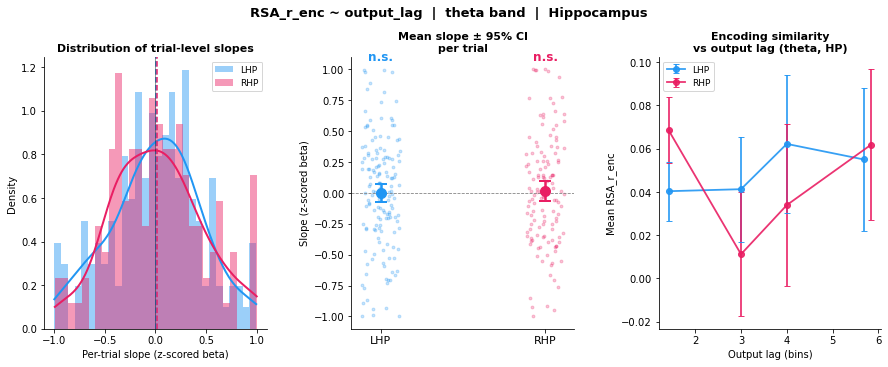


Saved figure: rsa_enc_outputlag/figure_rsa_enc_outputlag.png
Done.


In [4]:
#!/usr/bin/env python3
"""
Per-Trial OLS: RSA_r_enc ~ output_lag  (theta band, LHP / RHP)
---------------------------------------------------------------
For each (subject, session, trial) independently:
  - Collect all recall pairs in that trial
  - Fit OLS: RSA_r_enc ~ output_lag
  - Save the slope (beta) for that trial

Group-level test:
  - One-sample t-test on trial-level slopes (H0: mean slope = 0)

Visualization:
  - Panel 1: distribution of per-trial slopes (histogram + KDE), LHP vs RHP
  - Panel 2: mean slope ± 95% CI per region, with individual trial dots
  - Panel 3: scatter of RSA_r_enc vs output_lag (binned means ± SEM)

Input : ./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv
Output: ./rsa_enc_outputlag/
          per_trial_slopes.csv
          group_results.csv
          figure_rsa_enc_outputlag.png
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from pathlib import Path

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = Path('./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv')
OUTPUT_DIR = Path('./rsa_enc_outputlag')
OUTPUT_DIR.mkdir(exist_ok=True)

REGIONS   = ['LHP', 'RHP']
BAND      = 'theta'
OUTCOME   = 'RSA_r_enc'
PREDICTOR = 'output_lag'
MIN_PAIRS = 3    # minimum pairs in a trial to fit OLS

REGION_COLORS = {'LHP': '#2196F3', 'RHP': '#E91E63'}

# ============================================================================
# LOAD & FILTER
# ============================================================================

print(f'Loading: {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(f'  Shape    : {df.shape}')
print(f'  Columns  : {list(df.columns)}')
print(f'  Subjects : {df["subject"].nunique()}')

df_theta = df[df['band'] == BAND].copy()
print(f'  Theta rows: {len(df_theta)}')

# ============================================================================
# PER-TRIAL OLS
# ============================================================================

def fit_trial_ols(df_trial):
    """Fit OLS: RSA_r_enc ~ output_lag for one trial. Returns slope, se, r, p."""
    d = df_trial[[OUTCOME, PREDICTOR]].dropna()
    if len(d) < MIN_PAIRS:
        return None
    y = d[OUTCOME].values.astype(float)
    x = d[PREDICTOR].values.astype(float)
    # skip if no variance
    if x.std() < 1e-10 or y.std() < 1e-10:
        return None
    # z-score within trial for comparable betas
    y_z = (y - y.mean()) / y.std()
    x_z = (x - x.mean()) / x.std()
    X = add_constant(x_z)
    res = OLS(y_z, X).fit()
    r, p_r = pearsonr(x_z, y_z)
    return dict(slope=res.params[1], se=res.bse[1],
                t=res.tvalues[1], p_ols=res.pvalues[1],
                pearson_r=r, n_pairs=len(d))


all_slope_rows = []

for region in REGIONS:
    print(f'\nFitting per-trial OLS — {region} ...')
    df_r = df_theta[df_theta['region'] == region].copy()

    groups = df_r.groupby(['subject', 'session', 'trial'])
    n_total = len(groups)

    for (subj, sess, trial), g in groups:
        result = fit_trial_ols(g)
        if result is None:
            continue
        result.update(subject=subj, session=sess, trial=trial, region=region)
        all_slope_rows.append(result)

    n_fit = sum(1 for r in all_slope_rows if r['region'] == region)
    print(f'  Fitted {n_fit} / {n_total} trials')

slopes_df = pd.DataFrame(all_slope_rows)
slopes_df.to_csv(OUTPUT_DIR / 'per_trial_slopes.csv', index=False)
print(f'\nSaved per-trial slopes: {OUTPUT_DIR}/per_trial_slopes.csv')

# ============================================================================
# GROUP-LEVEL T-TEST
# ============================================================================

group_rows = []
print(f'\n{"="*55}')
print(f'  GROUP-LEVEL RESULTS  ({OUTCOME} ~ {PREDICTOR}, {BAND})')
print(f'{"="*55}')

for region in REGIONS:
    s = slopes_df[slopes_df['region'] == region]['slope'].dropna().values
    t_stat, p_val = stats.ttest_1samp(s, 0.0)
    ci_lo, ci_hi  = stats.t.interval(0.95, df=len(s)-1,
                                      loc=s.mean(), scale=stats.sem(s))
    sig = '***' if p_val < .001 else '**' if p_val < .01 else '*' if p_val < .05 else 'n.s.'
    print(f'  {region}: mean_slope={s.mean():+.4f}  '
          f'95%CI=[{ci_lo:+.4f}, {ci_hi:+.4f}]  '
          f't({len(s)-1})={t_stat:+.3f}  p={p_val:.4f}  {sig}')
    group_rows.append(dict(region=region, mean_slope=s.mean(),
                           sem=stats.sem(s), ci_lo=ci_lo, ci_hi=ci_hi,
                           t_stat=t_stat, p_val=p_val, n_trials=len(s)))

group_df = pd.DataFrame(group_rows)
group_df.to_csv(OUTPUT_DIR / 'group_results.csv', index=False)

# ============================================================================
# VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

ax1 = fig.add_subplot(gs[0])   # histogram of per-trial slopes
ax2 = fig.add_subplot(gs[1])   # mean ± CI per region + trial dots
ax3 = fig.add_subplot(gs[2])   # binned scatter: RSA vs output_lag

# ── Panel 1: slope distributions ────────────────────────────────────────────
for region in REGIONS:
    s    = slopes_df[slopes_df['region'] == region]['slope'].dropna().values
    color = REGION_COLORS[region]
    ax1.hist(s, bins=30, alpha=0.45, color=color, label=region, density=True)
    # KDE
    kde_x = np.linspace(s.min(), s.max(), 200)
    kde   = stats.gaussian_kde(s)
    ax1.plot(kde_x, kde(kde_x), color=color, lw=2)
    ax1.axvline(s.mean(), color=color, lw=1.5, ls='--')

ax1.axvline(0, color='black', lw=1.0, ls='-', alpha=0.4)
ax1.set_xlabel('Per-trial slope (z-scored beta)', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.set_title('Distribution of trial-level slopes', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: mean ± 95% CI + jittered trial dots ────────────────────────────
x_pos = [0, 1]
for xi, region in zip(x_pos, REGIONS):
    color = REGION_COLORS[region]
    row   = group_df[group_df['region'] == region].iloc[0]
    s_all = slopes_df[slopes_df['region'] == region]['slope'].dropna().values

    # jittered dots
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(s_all))
    ax2.scatter(xi + jitter, s_all, color=color, alpha=0.25, s=8, zorder=1)

    # mean + 95% CI bar
    ax2.errorbar(xi, row['mean_slope'],
                 yerr=[[row['mean_slope'] - row['ci_lo']],
                       [row['ci_hi']     - row['mean_slope']]],
                 fmt='o', color=color, ms=10, lw=2.5,
                 capsize=6, capthick=2, zorder=3)

    # significance label
    sig = ('***' if row['p_val'] < .001 else '**' if row['p_val'] < .01
           else '*' if row['p_val'] < .05 else 'n.s.')
    y_top = max(s_all.max(), row['ci_hi']) + 0.05
    ax2.text(xi, y_top, sig, ha='center', va='bottom',
             fontsize=12, color=color, fontweight='bold')

ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(REGIONS, fontsize=11)
ax2.set_ylabel('Slope (z-scored beta)', fontsize=10)
ax2.set_title('Mean slope ± 95% CI\nper trial', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Panel 3: binned RSA vs output_lag ───────────────────────────────────────
N_BINS = 8
for region in REGIONS:
    color  = REGION_COLORS[region]
    df_r   = df_theta[df_theta['region'] == region].dropna(
                 subset=[OUTCOME, PREDICTOR]).copy()

    bins    = pd.qcut(df_r[PREDICTOR], q=N_BINS, duplicates='drop')
    binned  = df_r.groupby(bins, observed=True)[OUTCOME].agg(['mean', 'sem', 'count'])
    x_cents = df_r.groupby(bins, observed=True)[PREDICTOR].mean().values

    ax3.errorbar(x_cents, binned['mean'].values,
                 yerr=binned['sem'].values,
                 fmt='o-', color=color, lw=1.8, ms=6,
                 capsize=3, label=region, alpha=0.9)

ax3.set_xlabel('Output lag (bins)', fontsize=10)
ax3.set_ylabel('Mean RSA_r_enc', fontsize=10)
ax3.set_title('Encoding similarity\nvs output lag (theta, HP)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

fig.suptitle(f'RSA_r_enc ~ output_lag  |  theta band  |  Hippocampus',
             fontsize=13, fontweight='bold', y=1.02)

fig.savefig(OUTPUT_DIR / 'figure_rsa_enc_outputlag.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved figure: {OUTPUT_DIR}/figure_rsa_enc_outputlag.png')
print('Done.')

Loading: rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv
  Shape    : (44692, 23)
  Subjects : 39
  All trial values: [0, 1, 2, 3, 4, 5, 6]

  Sessions before exclusion : 82
  Sessions after exclusion  : 44  (last trial > 1)

  Early (trial==0)          : 1992 pairs
  Late  (last trial/session): 2336 pairs
  Subjects remaining        : 26

subject              session      trials_used
-------------------------------------------------------
R1494D               0            [0, 4]
R1494D               1            [0, 3]
R1494D               2            [0, 4]
R1501J               0            [0, 5]
R1501J               1            [0, 5]
R1502D               0            [5]
R1502D               1            [0, 6]
R1503E               0            [0, 4]
R1503E               1            [0, 4]
R1503E               2            [0, 3]
R1504E               0            [0, 3]
R1509E               1            [0, 3]
R1509E               2            [0, 2]
R152

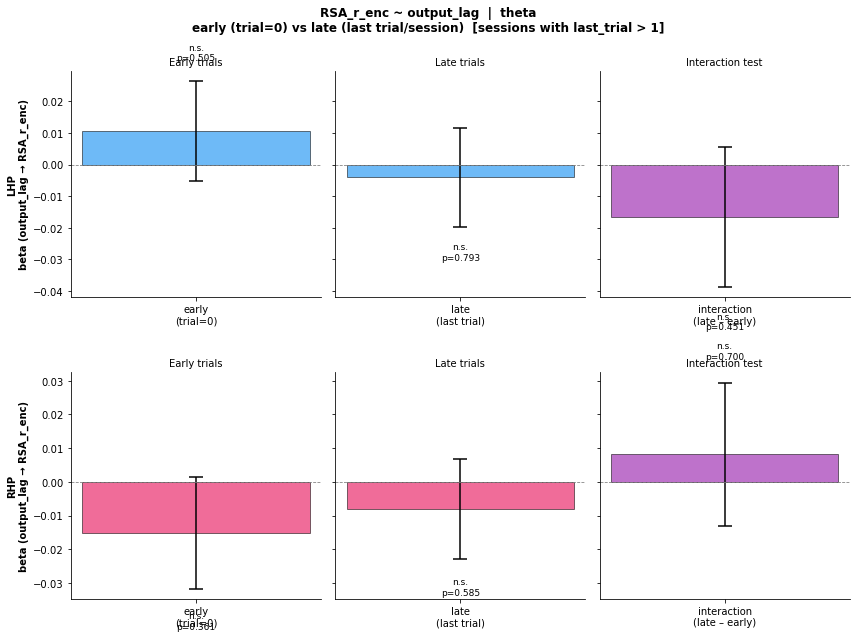


Saved figure : rsa_enc_outputlag/figure_early_late_interaction.png
Done.


In [5]:
#!/usr/bin/env python3
"""
LMM: RSA_r_enc ~ output_lag  (no z-score)
------------------------------------------
Separate models for early (trial == 0) and late (last trial per session).
Only sessions where last trial > 1 are included.

Then: interaction test via combined model
  RSA_r_enc ~ output_lag * C(trial_group, Treatment("early"))
            + (1|subject/session)

Band   : theta
Regions: LHP, RHP (separate)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from pathlib import Path

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = Path('./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv')
OUTPUT_DIR = Path('./rsa_enc_outputlag')
OUTPUT_DIR.mkdir(exist_ok=True)

REGIONS       = ['LHP', 'RHP']
BAND          = 'theta'
OUTCOME       = 'RSA_r_enc'
REGION_COLORS = {'LHP': '#2196F3', 'RHP': '#E91E63'}

EARLY_TRIAL   = 0

# ============================================================================
# LOAD & FILTER
# ============================================================================

print(f'Loading: {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(f'  Shape    : {df.shape}')
print(f'  Subjects : {df["subject"].nunique()}')
print(f'  All trial values: {sorted(df["trial"].unique())}')

df = df[df['band'] == BAND].copy()

# ── Find last trial per session, keep only sessions where last trial > 1 ─────
last_trial_df = (
    df.groupby(['subject', 'session'])['trial']
    .max()
    .reset_index()
    .rename(columns={'trial': 'last_trial'})
)

df = df.merge(last_trial_df, on=['subject', 'session'], how='left')

n_before = df[['subject', 'session']].drop_duplicates().shape[0]
df = df[df['last_trial'] > 1].copy()
n_after = df[['subject', 'session']].drop_duplicates().shape[0]

print(f'\n  Sessions before exclusion : {n_before}')
print(f'  Sessions after exclusion  : {n_after}  (last trial > 1)')

is_early = df['trial'] == EARLY_TRIAL
is_late  = df['trial'] == df['last_trial']

df = df[is_early | is_late].copy()
df['trial_group'] = np.where(df['trial'] == EARLY_TRIAL, 'early', 'late')

print(f'\n  Early (trial==0)          : {(df["trial_group"]=="early").sum()} pairs')
print(f'  Late  (last trial/session): {(df["trial_group"]=="late").sum()} pairs')
print(f'  Subjects remaining        : {df["subject"].nunique()}')

# ── Print table: subject / session / trials used ─────────────────────────────
summary = (
    df.groupby(['subject', 'session'])['trial']
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
    .rename(columns={'trial': 'trials_used'})
)
print(f'\n{"subject":<20} {"session":<12} {"trials_used"}')
print('-' * 55)
for _, row in summary.iterrows():
    print(f'{str(row["subject"]):<20} {str(row["session"]):<12} {row["trials_used"]}')

# ── Nested grouping variable (no z-score of output_lag) ──────────────────────
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)

formula_sep = f'{OUTCOME} ~ output_lag'

# ============================================================================
# MODELS PER REGION
# ============================================================================

all_results = {}

for region in REGIONS:
    print(f'\n{"="*65}')
    print(f'  Region : {region}')
    print(f'{"="*65}')

    df_r = df[df['region'] == region].dropna(subset=[OUTCOME, 'output_lag']).copy()
    df_early = df_r[df_r['trial_group'] == 'early']
    df_late  = df_r[df_r['trial_group'] == 'late']

    vc_formula = {'subj_sess': '0 + C(subj_sess)'}

    # ── Model A: early ───────────────────────────────────────────────────────
    print(f'\n  [Model A – early trials only]')
    print(f'  N pairs: {len(df_early)}   N subjects: {df_early["subject"].nunique()}')

    lmm_early = smf.mixedlm(
        formula_sep, df_early,
        groups=df_early['subject'],
        vc_formula={'subj_sess': '0 + C(subj_sess)'}
    ).fit(reml=False, method='lbfgs')

    b_early  = lmm_early.params['output_lag']
    se_early = lmm_early.bse['output_lag']
    t_early  = lmm_early.tvalues['output_lag']
    p_early  = lmm_early.pvalues['output_lag']
    sig_e    = '***' if p_early<.001 else '**' if p_early<.01 else '*' if p_early<.05 else 'n.s.'
    print(f'  output_lag:  beta={b_early:+.6f}  SE={se_early:.6f}  t={t_early:+.3f}  p={p_early:.4f}  {sig_e}')

    # ── Model B: late ────────────────────────────────────────────────────────
    print(f'\n  [Model B – late trials only]')
    print(f'  N pairs: {len(df_late)}   N subjects: {df_late["subject"].nunique()}')

    lmm_late = smf.mixedlm(
        formula_sep, df_late,
        groups=df_late['subject'],
        vc_formula={'subj_sess': '0 + C(subj_sess)'}
    ).fit(reml=False, method='lbfgs')

    b_late  = lmm_late.params['output_lag']
    se_late = lmm_late.bse['output_lag']
    t_late  = lmm_late.tvalues['output_lag']
    p_late  = lmm_late.pvalues['output_lag']
    sig_l   = '***' if p_late<.001 else '**' if p_late<.01 else '*' if p_late<.05 else 'n.s.'
    print(f'  output_lag:  beta={b_late:+.6f}  SE={se_late:.6f}  t={t_late:+.3f}  p={p_late:.4f}  {sig_l}')

    # ── Model C: interaction (combined) ──────────────────────────────────────
    print(f'\n  [Model C – interaction test (combined)]')
    print(f'  N pairs: {len(df_r)}   N subjects: {df_r["subject"].nunique()}')

    formula_int = f'{OUTCOME} ~ output_lag * C(trial_group, Treatment("early"))'
    lmm_int = smf.mixedlm(
        formula_int, df_r,
        groups=df_r['subject'],
        vc_formula={'subj_sess': '0 + C(subj_sess)'}
    ).fit(reml=False, method='lbfgs')

    print(lmm_int.summary())

    # Find interaction term (handle term ordering)
    int_term = 'output_lag:C(trial_group, Treatment("early"))[T.late]'
    if int_term not in lmm_int.params.index:
        alt = 'C(trial_group, Treatment("early"))[T.late]:output_lag'
        int_term = alt if alt in lmm_int.params.index else int_term

    if int_term in lmm_int.params.index:
        b_int  = lmm_int.params[int_term]
        se_int = lmm_int.bse[int_term]
        t_int  = lmm_int.tvalues[int_term]
        p_int  = lmm_int.pvalues[int_term]
        sig_i  = '***' if p_int<.001 else '**' if p_int<.01 else '*' if p_int<.05 else 'n.s.'
        print(f'\n  interaction: beta={b_int:+.6f}  SE={se_int:.6f}  t={t_int:+.3f}  p={p_int:.4f}  {sig_i}')
    else:
        b_int = se_int = t_int = p_int = np.nan
        sig_i = 'n.a.'
        print(f'  WARNING: interaction term not found.')
        print(f'  Available: {list(lmm_int.params.index)}')

    # ── Save CSV ──────────────────────────────────────────────────────────────
    rows = [
        dict(region=region, model='early', term='output_lag',
             beta=b_early, se=se_early, t_stat=t_early, p_val=p_early),
        dict(region=region, model='late',  term='output_lag',
             beta=b_late,  se=se_late,  t_stat=t_late,  p_val=p_late),
        dict(region=region, model='interaction', term=int_term,
             beta=b_int,   se=se_int,   t_stat=t_int,   p_val=p_int),
    ]
    pd.DataFrame(rows).to_csv(
        OUTPUT_DIR / f'results_{region}.csv', index=False)

    all_results[region] = dict(
        b_early=b_early, se_early=se_early, p_early=p_early, sig_e=sig_e,
        b_late=b_late,   se_late=se_late,   p_late=p_late,   sig_l=sig_l,
        b_int=b_int,     se_int=se_int,     p_int=p_int,     sig_i=sig_i,
    )

# ============================================================================
# PLOT  –  3 panels per region row: early | late | interaction
# ============================================================================

nrows = len(REGIONS)
ncols = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.5 * nrows),
                         sharey='row')
if nrows == 1:
    axes = axes[np.newaxis, :]   # ensure 2-D indexing

fig.suptitle(
    f'RSA_r_enc ~ output_lag  |  theta\n'
    f'early (trial=0) vs late (last trial/session)  '
    f'[sessions with last_trial > 1]',
    fontsize=12, fontweight='bold'
)

GROUP_LABELS = ['early\n(trial=0)', 'late\n(last trial)', 'interaction\n(late – early)']

for ri, region in enumerate(REGIONS):
    color = REGION_COLORS[region]
    res   = all_results[region]

    betas = [res['b_early'], res['b_late'], res['b_int']]
    ses   = [res['se_early'], res['se_late'], res['se_int']]
    ps    = [res['p_early'],  res['p_late'],  res['p_int']]
    sigs  = [res['sig_e'],    res['sig_l'],   res['sig_i']]

    for ci in range(ncols):
        ax = axes[ri, ci]
        b, se, p, sig = betas[ci], ses[ci], ps[ci], sigs[ci]

        bar_color = color if ci < 2 else '#9C27B0'   # purple for interaction

        if not np.isnan(b):
            ax.bar([0], [b], color=bar_color, alpha=0.65, width=0.5,
                   edgecolor='black', linewidth=0.8)
            ax.errorbar([0], [b], yerr=[se], fmt='none',
                        color='black', capsize=7, capthick=1.5, lw=1.5)

            # significance annotation
            y_ann = b + se + abs(b + se) * 0.15 + 0.002
            if b < 0:
                y_ann = b - se - abs(b - se) * 0.15 - 0.002
            ax.text(0, y_ann, f'{sig}\np={p:.3f}',
                    ha='center', va='bottom' if b >= 0 else 'top',
                    fontsize=9)

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_xticks([0])
        ax.set_xticklabels([GROUP_LABELS[ci]], fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if ci == 0:
            ax.set_ylabel(f'{region}\nbeta (output_lag → RSA_r_enc)',
                          fontsize=10, fontweight='bold')

        title_map = ['Early trials', 'Late trials', 'Interaction test']
        ax.set_title(f'{title_map[ci]}', fontsize=10)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'figure_early_late_interaction.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved figure : {fig_path}')
print('Done.')

In [50]:
plt.close(fig)

Loading: rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv
  Shape    : (44692, 23)
  Subjects : 39
  All trial values: [0, 1, 2, 3, 4, 5, 6]

  Sessions before exclusion : 82
  Sessions after exclusion  : 42  (kept sessions with >= 3 trials)

  Early (trial==0)   : 1987 pairs
  Late  (trial>=3)   : 2563 pairs
  Subjects remaining : 26

subject              session      trials_used
-------------------------------------------------------
R1494D               0            [0, 4]
R1494D               2            [0, 3, 4]
R1501J               0            [0, 3, 4, 5]
R1501J               1            [0, 3, 4, 5]
R1502D               0            [3, 4, 5]
R1502D               1            [0, 3, 4, 5, 6]
R1503E               0            [0, 3, 4]
R1503E               1            [0, 3, 4]
R1503E               2            [0, 3]
R1504E               0            [0, 3]
R1509E               1            [0, 3]
R1509E               2            [0]
R1521E           

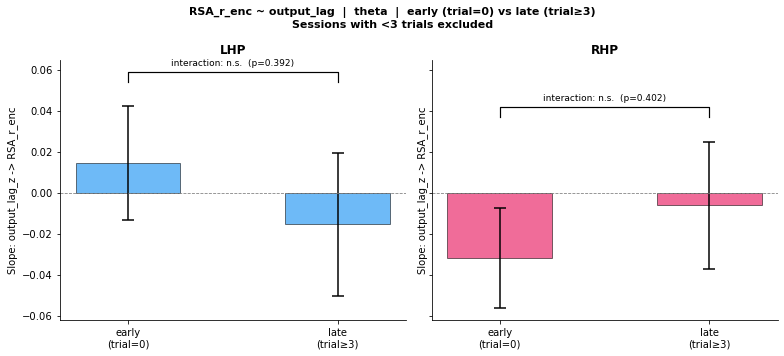


Saved figure : rsa_enc_outputlag/figure_early_vs_late.png
Done.


In [6]:
#!/usr/bin/env python3
"""
LMM: RSA_r_enc ~ output_lag_z * trial_group
--------------------------------------------
trial_group:
  early = trial == 0
  late  = trial >= 3

Sessions with fewer than 3 distinct trial numbers are excluded.

Model: RSA_r_enc ~ output_lag_z * C(trial_group, Treatment("early"))
                 + (1|subject/session)

Band   : theta
Regions: LHP, RHP (separate)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from pathlib import Path

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = Path('./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv')
OUTPUT_DIR = Path('./rsa_enc_outputlag')
OUTPUT_DIR.mkdir(exist_ok=True)

REGIONS       = ['LHP', 'RHP']
BAND          = 'theta'
OUTCOME       = 'RSA_r_enc'
REGION_COLORS = {'LHP': '#2196F3', 'RHP': '#E91E63'}

EARLY_TRIAL   = 0       # trial == 0
LATE_MIN      = 3       # trial >= 3
MIN_TRIALS_PER_SESSION = 3   # exclude sessions with fewer distinct trials

# ============================================================================
# LOAD & FILTER
# ============================================================================

print(f'Loading: {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(f'  Shape    : {df.shape}')
print(f'  Subjects : {df["subject"].nunique()}')
print(f'  All trial values: {sorted(df["trial"].unique())}')

df = df[df['band'] == BAND].copy()

# ── Exclude sessions with fewer than MIN_TRIALS_PER_SESSION distinct trials ─
session_trial_counts = (
    df.groupby(['subject', 'session'])['trial']
    .nunique()
    .reset_index()
    .rename(columns={'trial': 'n_trials'})
)

valid_sessions = session_trial_counts[
    session_trial_counts['n_trials'] >= MIN_TRIALS_PER_SESSION
][['subject', 'session']]

n_before = df[['subject','session']].drop_duplicates().shape[0]
df = df.merge(valid_sessions, on=['subject', 'session'], how='inner')
n_after = df[['subject','session']].drop_duplicates().shape[0]

print(f'\n  Sessions before exclusion : {n_before}')
print(f'  Sessions after exclusion  : {n_after}  '
      f'(kept sessions with >= {MIN_TRIALS_PER_SESSION} trials)')

# ── Keep only early (trial==0) and late (trial>=3) ──────────────────────────
df = df[(df['trial'] == EARLY_TRIAL) | (df['trial'] >= LATE_MIN)].copy()
df['trial_group'] = np.where(df['trial'] == EARLY_TRIAL, 'early', 'late')

print(f'\n  Early (trial==0)   : {(df["trial_group"]=="early").sum()} pairs')
print(f'  Late  (trial>=3)   : {(df["trial_group"]=="late").sum()} pairs')
print(f'  Subjects remaining : {df["subject"].nunique()}')

# ── Print table: subject / session / trials used ────────────────────────────
summary = (
    df.groupby(['subject', 'session'])['trial']
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index()
    .rename(columns={'trial': 'trials_used'})
)
print(f'\n{"subject":<20} {"session":<12} {"trials_used"}')
print('-' * 55)
for _, row in summary.iterrows():
    print(f'{str(row["subject"]):<20} {str(row["session"]):<12} {row["trials_used"]}')

# ── Nested grouping + z-score ────────────────────────────────────────────────
df['subj_sess']     = df['subject'].astype(str) + '_' + df['session'].astype(str)
df['output_lag_z']  = (df['output_lag'] - df['output_lag'].mean()) / df['output_lag'].std()

# ============================================================================
# ONE LMM PER REGION
# ============================================================================

all_results = {}

for region in REGIONS:
    print(f'\n{"="*60}')
    print(f'  Region : {region}')
    print(f'  Model  : {OUTCOME} ~ output_lag_z * trial_group + (1|subj/sess)')
    print(f'  Ref    : early (trial == 0)')
    print(f'{"="*60}')

    df_r = df[df['region'] == region].dropna(
        subset=[OUTCOME, 'output_lag_z']).copy()

    print(f'  N pairs   : {len(df_r)}')
    print(f'  N subjects: {df_r["subject"].nunique()}')

    vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    formula    = f'{OUTCOME} ~ output_lag_z * C(trial_group, Treatment("early"))'

    lmm = smf.mixedlm(
        formula, df_r,
        groups=df_r['subject'],
        vc_formula=vc_formula
    ).fit(reml=False, method='lbfgs')

    print(lmm.summary())

    # ── Extract terms ────────────────────────────────────────────────────────
    rows = []
    terms_to_extract = {
        'early_slope':       'output_lag_z',
        'group_main_effect': 'C(trial_group, Treatment("early"))[T.late]',
        'interaction':       'output_lag_z:C(trial_group, Treatment("early"))[T.late]',
    }

    for label, term in terms_to_extract.items():
        if term not in lmm.params.index:
            alt  = ':'.join(reversed(term.split(':')))
            term = alt if alt in lmm.params.index else term

        if term in lmm.params.index:
            b   = lmm.params[term]
            se  = lmm.bse[term]
            t   = lmm.tvalues[term]
            p   = lmm.pvalues[term]
            sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'
            print(f'\n  [{label}]')
            print(f'    beta={b:+.4f}  SE={se:.4f}  t={t:+.3f}  p={p:.4f}  {sig}')
            rows.append(dict(region=region, label=label, term=term,
                             beta=b, se=se, t_stat=t, p_val=p))
        else:
            print(f'\n  WARNING: "{term}" not found in model params.')
            print(f'  Available params: {list(lmm.params.index)}')

    early_b  = next((r['beta'] for r in rows if r['label'] == 'early_slope'), np.nan)
    inter_b  = next((r['beta'] for r in rows if r['label'] == 'interaction'), np.nan)
    late_b   = early_b + inter_b
    early_se = next((r['se']   for r in rows if r['label'] == 'early_slope'), np.nan)
    inter_se = next((r['se']   for r in rows if r['label'] == 'interaction'), np.nan)
    inter_p  = next((r['p_val']for r in rows if r['label'] == 'interaction'), np.nan)

    print(f'\n  Total slope early : {early_b:+.4f}')
    print(f'  Total slope late  : {late_b:+.4f}  (early + interaction)')

    pd.DataFrame(rows).to_csv(
        OUTPUT_DIR / f'interaction_early_late_{region}.csv', index=False)

    all_results[region] = dict(
        rows=rows,
        early_b=early_b, early_se=early_se,
        late_b=late_b,   inter_se=inter_se,
        inter_p=inter_p
    )

# ============================================================================
# PLOT
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
fig.suptitle(
    f'RSA_r_enc ~ output_lag  |  theta  |  '
    f'early (trial=0) vs late (trial≥3)\n'
    f'Sessions with <{MIN_TRIALS_PER_SESSION} trials excluded',
    fontsize=11, fontweight='bold'
)

GROUP_LABELS = [f'early\n(trial=0)', f'late\n(trial≥3)']
X_POS        = [0, 1]

for ax, region in zip(axes, REGIONS):
    color = REGION_COLORS[region]
    res   = all_results.get(region, {})

    early_b  = res.get('early_b',  np.nan)
    late_b   = res.get('late_b',   np.nan)
    early_se = res.get('early_se', np.nan)
    inter_se = res.get('inter_se', np.nan)
    inter_p  = res.get('inter_p',  np.nan)

    betas = [early_b, late_b]
    ses   = [early_se, inter_se]

    ax.bar(X_POS, betas, color=color, alpha=0.65, width=0.5,
           edgecolor='black', linewidth=0.8)
    ax.errorbar(X_POS, betas, yerr=ses, fmt='none',
                color='black', capsize=6, capthick=1.5, lw=1.5)

    # significance bracket for interaction
    if not np.isnan(inter_p):
        valid = [(b, s) for b, s in zip(betas, ses)
                 if not np.isnan(b) and not np.isnan(s)]
        if valid:
            y_br = max(b + s for b, s in valid) + 0.012
            ax.plot([0, 0, 1, 1],
                    [y_br, y_br + 0.005, y_br + 0.005, y_br],
                    color='black', lw=1.2)
            sig = ('***' if inter_p < .001 else '**' if inter_p < .01
                   else '*' if inter_p < .05 else 'n.s.')
            ax.text(0.5, y_br + 0.007,
                    f'interaction: {sig}  (p={inter_p:.3f})',
                    ha='center', va='bottom', fontsize=9)

    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xticks(X_POS)
    ax.set_xticklabels(GROUP_LABELS, fontsize=10)
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_ylabel('Slope: output_lag_z -> RSA_r_enc', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'figure_early_vs_late.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved figure : {fig_path}')
print('Done.')

In [7]:
"""
Compute mean temporal clustering score (T_clustering_to_next) 
per subject × session × trial (list).

Logic:
- Each row is one recalled word × channel. Deduplicate to one row per
  (subject, session, trial, recalled_word) since T is channel-invariant.
- NaN values (last recall in a list has no "next" item) are excluded.
- Final output: one row per subject × session × trial (list).
"""

import pandas as pd

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv('subject_results_DBOY1/ALL_SUBJECTS_DBOY1_irasa_channel_wide.csv')
print(f"Loaded {len(df):,} rows, {df['subject'].nunique()} subjects")

# ── Deduplicate to word level (collapse across channels) ──────────────────────
word_level = (
    df[['subject', 'session', 'trial', 'recalled_word', 'T_clustering_to_next']]
    .drop_duplicates(subset=['subject', 'session', 'trial', 'recalled_word'])
    .reset_index(drop=True)
)
print(f"Unique recalled-word events: {len(word_level):,}")

# ── Mean T per subject × session × trial (list) ───────────────────────────────
mean_T = (
    word_level
    .groupby(['subject', 'session', 'trial'], sort=True)['T_clustering_to_next']
    .agg(
        n_recalled_words='count',
        n_valid_T=lambda x: x.notna().sum(),
        mean_T_clustering=lambda x: x.mean()   # skips NaN automatically
    )
    .reset_index()
)

mean_T['mean_T_clustering'] = mean_T['mean_T_clustering'].round(6)

print(f"\nOutput shape: {mean_T.shape}  (subject × session × trial rows)")
print(mean_T.head(15).to_string(index=False))

# ── Save ───────────────────────────────────────────────────────────────────────
mean_T.to_csv('mean_temporal_clustering_per_list.csv')

Loaded 59,568 rows, 40 subjects
Unique recalled-word events: 1,077

Output shape: (246, 6)  (subject × session × trial rows)
subject  session  trial  n_recalled_words  n_valid_T  mean_T_clustering
 R1494D        0      0                 2          2           0.611111
 R1494D        0      1                 0          0                NaN
 R1494D        0      2                 3          3           0.578241
 R1494D        0      3                 0          0                NaN
 R1494D        0      4                 1          1           0.550000
 R1494D        1      0                 1          1           0.750000
 R1494D        1      1                 0          0                NaN
 R1494D        1      3                 1          1           1.000000
 R1494D        2      0                 2          2           0.463889
 R1494D        2      1                 3          3           0.701389
 R1494D        2      2                 3          3           0.507407
 R1494D    

Loading: rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv
  Shape    : (44692, 23)
  Subjects : 39
  All trial values: [0, 1, 2, 3, 4, 5, 6]

  Sessions before exclusion : 82
  Sessions after exclusion  : 69

subject              session    lowest_trial    highest_trial
------------------------------------------------------------
R1494D               0          0               4
R1494D               1          0               3
R1494D               2          0               4
R1501J               0          0               5
R1501J               1          0               5
R1502D               0          1               5
R1502D               1          0               6
R1503E               0          0               4
R1503E               1          0               4
R1503E               2          0               3
R1504E               0          0               3
R1509E               0          0               1
R1509E               1          0              

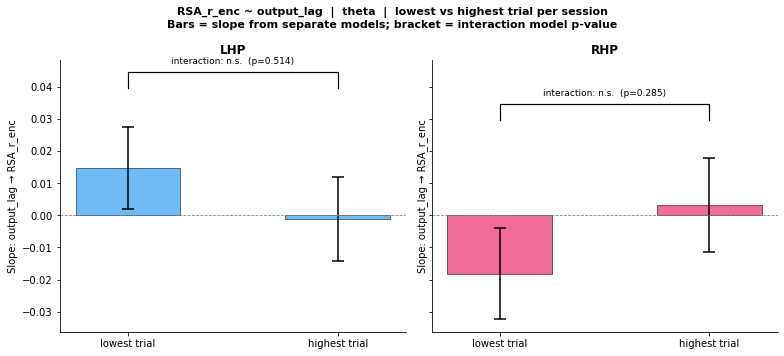

Saved figure : rsa_enc_outputlag_highlow/figure_lowest_vs_highest_trial.png
Done.


In [8]:
#!/usr/bin/env python3
"""
Three LMMs per region (LHP, RHP):
  Model 1 — lowest trial only  : RSA_r_enc ~ output_lag + (1|subj/sess)
  Model 2 — highest trial only : RSA_r_enc ~ output_lag + (1|subj/sess)
  Model 3 — interaction model  : RSA_r_enc ~ output_lag * C(trial_group, Treatment("lowest"))
                                            + (1|subj/sess)

trial_group assigned per subject/session:
  lowest  = trial == min(trial) for that subject/session
  highest = trial == max(trial) for that subject/session

Sessions with fewer than 2 distinct trial numbers are excluded.
No z-scoring of output_lag.

Band   : theta
Regions: LHP, RHP (separate)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = Path('./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv')
OUTPUT_DIR = Path('./rsa_enc_outputlag_highlow')
OUTPUT_DIR.mkdir(exist_ok=True)

REGIONS       = ['LHP', 'RHP']
BAND          = 'theta'
OUTCOME       = 'RSA_r_enc'
REGION_COLORS = {'LHP': '#2196F3', 'RHP': '#E91E63'}

MIN_DISTINCT_TRIALS = 2

# ============================================================================
# LOAD & FILTER
# ============================================================================

print(f'Loading: {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(f'  Shape    : {df.shape}')
print(f'  Subjects : {df["subject"].nunique()}')
print(f'  All trial values: {sorted(df["trial"].unique())}')

df = df[df['band'] == BAND].copy()

# ── Exclude sessions with too few distinct trials ───────────────────────────
session_trial_counts = (
    df.groupby(['subject', 'session'])['trial']
    .nunique().reset_index()
    .rename(columns={'trial': 'n_trials'})
)
valid_sessions = session_trial_counts[
    session_trial_counts['n_trials'] >= MIN_DISTINCT_TRIALS
][['subject', 'session']]

n_before = df[['subject', 'session']].drop_duplicates().shape[0]
df = df.merge(valid_sessions, on=['subject', 'session'], how='inner')
n_after = df[['subject', 'session']].drop_duplicates().shape[0]
print(f'\n  Sessions before exclusion : {n_before}')
print(f'  Sessions after exclusion  : {n_after}')

# ============================================================================
# IDENTIFY LOWEST / HIGHEST TRIAL PER SUBJECT/SESSION
# ============================================================================

trial_bounds = (
    df.groupby(['subject', 'session'])['trial']
    .agg(lowest_trial='min', highest_trial='max')
    .reset_index()
)

print(f'\n{"subject":<20} {"session":<10} {"lowest_trial":<15} {"highest_trial"}')
print('-' * 60)
for _, row in trial_bounds.iterrows():
    print(f'{str(row["subject"]):<20} {str(row["session"]):<10} '
          f'{str(row["lowest_trial"]):<15} {str(row["highest_trial"])}')

df = df.merge(trial_bounds, on=['subject', 'session'], how='left')

# Subsets
df_low  = df[df['trial'] == df['lowest_trial']].copy()
df_high = df[df['trial'] == df['highest_trial']].copy()

# Combined for interaction model
df_both = df[
    (df['trial'] == df['lowest_trial']) | (df['trial'] == df['highest_trial'])
].copy()
df_both['trial_group'] = np.where(
    df_both['trial'] == df_both['lowest_trial'], 'lowest', 'highest'
)

# Nested session grouping (no z-score)
for d in [df_low, df_high, df_both]:
    d['subj_sess'] = d['subject'].astype(str) + '_' + d['session'].astype(str)

print(f'\n  Lowest-trial rows  : {len(df_low)}')
print(f'  Highest-trial rows : {len(df_high)}')
print(f'  Combined rows      : {len(df_both)}')

# ============================================================================
# HELPER: fit simple LMM and extract output_lag term
# ============================================================================

def fit_simple_lmm(df_r, region, label, outcome=OUTCOME):
    """RSA_r_enc ~ output_lag + (1|subj/sess)"""
    df_r = df_r[df_r['region'] == region].dropna(subset=[outcome, 'output_lag']).copy()
    print(f'\n  [{label}]  N pairs={len(df_r)}  N subjects={df_r["subject"].nunique()}')

    vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    lmm = smf.mixedlm(
        f'{outcome} ~ output_lag', df_r,
        groups=df_r['subject'],
        vc_formula=vc_formula
    ).fit(reml=False, method='lbfgs')

    term = 'output_lag'
    b, se, t, p = (lmm.params[term], lmm.bse[term],
                   lmm.tvalues[term], lmm.pvalues[term])
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    print(f'    output_lag: beta={b:+.6f}  SE={se:.6f}  t={t:+.3f}  p={p:.4f}  {sig}')
    return dict(region=region, model=label, term=term,
                beta=b, se=se, t_stat=t, p_val=p, n_pairs=len(df_r))


# ============================================================================
# HELPER: fit interaction LMM
# ============================================================================

def fit_interaction_lmm(df_r, region, outcome=OUTCOME):
    """RSA_r_enc ~ output_lag * trial_group + (1|subj/sess), ref=lowest"""
    df_r = df_r[df_r['region'] == region].dropna(subset=[outcome, 'output_lag']).copy()
    print(f'\n  [interaction]  N pairs={len(df_r)}  N subjects={df_r["subject"].nunique()}')

    vc_formula = {'subj_sess': '0 + C(subj_sess)'}
    formula    = f'{outcome} ~ output_lag * C(trial_group, Treatment("lowest"))'

    lmm = smf.mixedlm(
        formula, df_r,
        groups=df_r['subject'],
        vc_formula=vc_formula
    ).fit(reml=False, method='lbfgs')

    print(lmm.summary())

    terms_to_extract = {
        'lowest_slope':      'output_lag',
        'group_main_effect': 'C(trial_group, Treatment("lowest"))[T.highest]',
        'interaction':       'output_lag:C(trial_group, Treatment("lowest"))[T.highest]',
    }

    rows = []
    for label, term in terms_to_extract.items():
        if term not in lmm.params.index:
            alt  = ':'.join(reversed(term.split(':')))
            term = alt if alt in lmm.params.index else term
        if term in lmm.params.index:
            b, se, t, p = (lmm.params[term], lmm.bse[term],
                           lmm.tvalues[term], lmm.pvalues[term])
            sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
            print(f'\n  [{label}]')
            print(f'    beta={b:+.6f}  SE={se:.6f}  t={t:+.3f}  p={p:.4f}  {sig}')
            rows.append(dict(region=region, model='interaction', label=label,
                             term=term, beta=b, se=se, t_stat=t, p_val=p,
                             n_pairs=len(df_r)))
        else:
            print(f'\n  WARNING: "{term}" not in model. Available: {list(lmm.params.index)}')

    low_b  = next((r['beta'] for r in rows if r['label'] == 'lowest_slope'),  np.nan)
    int_b  = next((r['beta'] for r in rows if r['label'] == 'interaction'),   np.nan)
    high_b = low_b + int_b
    print(f'\n  Derived slope (lowest trial)  : {low_b:+.6f}')
    print(f'  Derived slope (highest trial) : {high_b:+.6f}  (lowest + interaction)')
    return rows


# ============================================================================
# RUN MODELS
# ============================================================================

all_simple  = []   # rows from models 1 & 2
all_inter   = []   # rows from model 3
all_results = {}   # for plotting

for region in REGIONS:
    print(f'\n{"="*60}')
    print(f'  REGION : {region}  |  band : {BAND}')
    print(f'{"="*60}')

    # Model 1: lowest trial only
    row_low  = fit_simple_lmm(df_low,  region, label='lowest_trial_only')
    # Model 2: highest trial only
    row_high = fit_simple_lmm(df_high, region, label='highest_trial_only')
    all_simple.extend([row_low, row_high])

    # Model 3: interaction
    inter_rows = fit_interaction_lmm(df_both, region)
    all_inter.extend(inter_rows)

    # Collect for plot
    low_b  = row_low['beta'];  low_se  = row_low['se']
    high_b = row_high['beta']; high_se = row_high['se']
    inter_b  = next((r['beta']  for r in inter_rows if r['label'] == 'interaction'), np.nan)
    inter_se = next((r['se']    for r in inter_rows if r['label'] == 'interaction'), np.nan)
    inter_p  = next((r['p_val'] for r in inter_rows if r['label'] == 'interaction'), np.nan)

    all_results[region] = dict(
        low_b=low_b,   low_se=low_se,
        high_b=high_b, high_se=high_se,
        inter_b=inter_b, inter_se=inter_se, inter_p=inter_p
    )

# ── Save CSVs ────────────────────────────────────────────────────────────────
pd.DataFrame(all_simple).to_csv(
    OUTPUT_DIR / 'simple_lmm_lowest_highest.csv', index=False)
pd.DataFrame(all_inter).to_csv(
    OUTPUT_DIR / 'interaction_lmm.csv', index=False)
print(f'\nSaved CSVs to {OUTPUT_DIR}')

# ============================================================================
# PLOT  — 2 panels (LHP / RHP), each showing low / high bars + interaction p
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
fig.suptitle(
    f'RSA_r_enc ~ output_lag  |  theta  |  lowest vs highest trial per session\n'
    f'Bars = slope from separate models; bracket = interaction model p-value',
    fontsize=11, fontweight='bold'
)

GROUP_LABELS = ['lowest trial', 'highest trial']
X_POS        = [0, 1]

for ax, region in zip(axes, REGIONS):
    color = REGION_COLORS[region]
    res   = all_results[region]

    betas   = [res['low_b'],  res['high_b']]
    ses     = [res['low_se'], res['high_se']]
    inter_p = res['inter_p']

    bars = ax.bar(X_POS, betas, color=color, alpha=0.65, width=0.5,
                  edgecolor='black', linewidth=0.8)
    ax.errorbar(X_POS, betas, yerr=ses, fmt='none',
                color='black', capsize=6, capthick=1.5, lw=1.5)

    # significance bracket from interaction model
    if not np.isnan(inter_p):
        y_br = max(b + s for b, s in zip(betas, ses)
                   if not np.isnan(b) and not np.isnan(s)) + 0.012
        ax.plot([0, 0, 1, 1],
                [y_br, y_br + 0.005, y_br + 0.005, y_br],
                color='black', lw=1.2)
        sig = ('***' if inter_p < .001 else '**' if inter_p < .01
               else '*' if inter_p < .05 else 'n.s.')
        ax.text(0.5, y_br + 0.007,
                f'interaction: {sig}  (p={inter_p:.3f})',
                ha='center', va='bottom', fontsize=9)

    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xticks(X_POS)
    ax.set_xticklabels(GROUP_LABELS, fontsize=10)
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_ylabel('Slope: output_lag → RSA_r_enc', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'figure_lowest_vs_highest_trial.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure : {fig_path}')
print('Done.')

Loaded 228 rows | 39 subjects
Lists available: [0, 1, 2, 3, 4, 5, 6]

Model: T_vs_chance ~ 1 + (1 | subject)
Beta = mean temporal clustering above chance (0.5)
List 0: beta=+0.0535  SE=0.0146  t=+3.649  p=0.0003  ***  (n_subj=38, n_sess=76)
List 1: beta=+0.1072  SE=0.0262  t=+4.093  p=0.0000  ***  (n_subj=33, n_sess=70)
List 2: beta=+0.1474  SE=0.0366  t=+4.034  p=0.0001  ***  (n_subj=24, n_sess=40)
List 3: beta=+0.0961  SE=0.0486  t=+1.979  p=0.0478  *  (n_subj=17, n_sess=26)
List 4: beta=+0.1631  SE=0.0681  t=+2.393  p=0.0167  *  (n_subj=7, n_sess=11)
List 5: skipping (n_subj=2)
List 6: skipping (n_subj=1)

Saved: ./temporal_clustering_LMM_and_mean_per_list.png


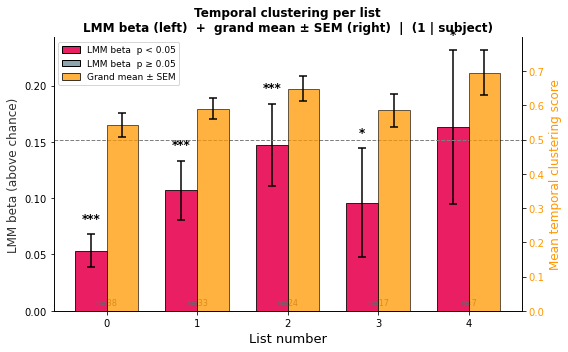

In [9]:
#!/usr/bin/env python3
"""
For each list (trial number), fit a linear mixed model:
    T_vs_chance ~ 1 + (1 | subject)

where T_vs_chance = mean_T_clustering - 0.5 (deviation from chance).

Subject random intercept accounts for non-independence of multiple
sessions per subject. One row per subject x session x list.

Plot: LMM beta ± SE (left axis) + grand mean ± SEM (right axis) per list.
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
INPUT_CSV  = './mean_temporal_clustering_per_list.csv'
OUTPUT_PNG = './temporal_clustering_LMM_and_mean_per_list.png'
MIN_SUBJ   = 3   # skip lists with fewer subjects

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['mean_T_clustering']).copy()

# Center against chance (0.5)
df['T_vs_chance'] = df['mean_T_clustering'] - 0.5

print(f"Loaded {len(df)} rows | {df['subject'].nunique()} subjects")
print(f"Lists available: {sorted(df['trial'].unique())}\n")

# ── LMM per list ──────────────────────────────────────────────────────────────
print("Model: T_vs_chance ~ 1 + (1 | subject)")
print("Beta = mean temporal clustering above chance (0.5)")
print("=" * 65)

results = []
for trial in sorted(df['trial'].unique()):
    grp    = df[df['trial'] == trial].copy()
    n_subj = grp['subject'].nunique()
    n_sess = len(grp)

    if n_subj < MIN_SUBJ:
        print(f"List {trial}: skipping (n_subj={n_subj})")
        continue

    lmm = smf.mixedlm(
        'T_vs_chance ~ 1',
        grp,
        groups=grp['subject']
    ).fit(reml=True, method='nm')

    b  = lmm.params['Intercept']
    se = lmm.bse['Intercept']
    t  = lmm.tvalues['Intercept']
    p  = lmm.pvalues['Intercept']
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

    # Grand mean ± SEM: subject-level means to avoid session pseudoreplication
    subj_means = grp.groupby('subject')['mean_T_clustering'].mean()
    grand_mean = subj_means.mean()
    grand_sem  = subj_means.sem()

    print(f"List {trial}: beta={b:+.4f}  SE={se:.4f}  t={t:+.3f}  "
          f"p={p:.4f}  {sig}  (n_subj={n_subj}, n_sess={n_sess})")

    results.append(dict(trial=trial, beta=b, se=se, t=t, p=p,
                        grand_mean=grand_mean, grand_sem=grand_sem,
                        n_subj=n_subj, n_sess=n_sess))

res = pd.DataFrame(results)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

x     = res['trial'].values
width = 0.35
x_bar = x - width / 2   # LMM beta bars
x_avg = x + width / 2   # grand mean bars

colors_beta = ['#E91E63' if p < 0.05 else '#90A4AE' for p in res['p']]

# Left axis: LMM beta ± SE
ax1.bar(x_bar, res['beta'], yerr=res['se'], width=width,
        color=colors_beta, edgecolor='black', linewidth=0.8,
        error_kw=dict(capsize=4, capthick=1.5, lw=1.5, color='black'),
        label='LMM beta (vs chance)', zorder=3)

# Right axis: grand mean ± SEM
ax2.bar(x_avg, res['grand_mean'], yerr=res['grand_sem'], width=width,
        color='#FF9800', alpha=0.75, edgecolor='black', linewidth=0.8,
        error_kw=dict(capsize=4, capthick=1.5, lw=1.5, color='black'),
        label='Grand mean ± SEM', zorder=3)
ax2.axhline(0.5, color='gray', lw=1, ls='--', zorder=2)

# Significance stars above beta bars
for _, row in res.iterrows():
    sig = ('***' if row['p'] < 0.001 else '**' if row['p'] < 0.01
           else '*' if row['p'] < 0.05 else '')
    if sig:
        ax1.text(row['trial'] - width / 2,
                 row['beta'] + row['se'] + 0.008,
                 sig, ha='center', va='bottom', fontsize=12, fontweight='bold')

# n labels at bottom
y_bot = ax1.get_ylim()[0]
for _, row in res.iterrows():
    ax1.text(row['trial'], y_bot + 0.003,
             f"n={int(row['n_subj'])}", ha='center', va='bottom',
             fontsize=8, color='dimgray')

ax1.set_xlabel('List number', fontsize=13)
ax1.set_ylabel('LMM beta (above chance)', fontsize=12, color='#333333')
ax2.set_ylabel('Mean temporal clustering score', fontsize=12, color='#FF9800')
ax2.tick_params(axis='y', labelcolor='#FF9800')
ax1.set_xticks(x)
ax1.set_title(
    'Temporal clustering per list\n'
    'LMM beta (left)  +  grand mean ± SEM (right)  |  (1 | subject)',
    fontsize=12, fontweight='bold'
)

legend_elements = [
    Patch(facecolor='#E91E63', edgecolor='black', label='LMM beta  p < 0.05'),
    Patch(facecolor='#90A4AE', edgecolor='black', label='LMM beta  p ≥ 0.05'),
    Patch(facecolor='#FF9800', edgecolor='black', alpha=0.75, label='Grand mean ± SEM'),
]
ax1.legend(handles=legend_elements, fontsize=9, loc='upper left')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
print(f'\nSaved: {OUTPUT_PNG}')

In [14]:
#!/usr/bin/env python3
"""
For each trial (0, 1, 2, 3, 4) and each region (LHP, RHP):

  Model: RSA_r_enc ~ output_lag + (1|subj/sess)

  Extracts:
    - Intercept : mean RSA_r_enc above 0 (baseline test)
    - output_lag slope : does output_lag predict RSA_r_enc?

Plot: x = trial number (0–4), y = beta
      Two subplots: one for intercept, one for output_lag slope
      Two lines/bars per subplot: LHP and RHP
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = Path('./rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv')
OUTPUT_DIR = Path('./rsa_enc_outputlag_per_trial')
OUTPUT_DIR.mkdir(exist_ok=True)

REGIONS       = ['LHP', 'RHP']
BAND          = 'theta'
OUTCOME       = 'RSA_r_enc'
TRIALS        = [0, 1, 2, 3, 4]
REGION_COLORS = {'LHP': '#2196F3', 'RHP': '#E91E63'}

# ============================================================================
# LOAD & FILTER
# ============================================================================

print(f'Loading: {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)
print(f'  Shape    : {df.shape}')
print(f'  Subjects : {df["subject"].nunique()}')
print(f'  All trial values: {sorted(df["trial"].unique())}')

df = df[df['band'] == BAND].copy()
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)

# ============================================================================
# RUN LMM PER TRIAL PER REGION
# ============================================================================

all_rows = []

for trial in TRIALS:
    df_t = df[df['trial'] == trial].copy()

    print(f'\n{"="*65}')
    print(f'  TRIAL {trial}  |  band: {BAND}')
    print(f'  Total rows: {len(df_t)}  |  subjects: {df_t["subject"].nunique()}')
    print(f'{"="*65}')

    for region in REGIONS:
        df_r = df_t[df_t['region'] == region].dropna(
            subset=[OUTCOME, 'output_lag']).copy()

        n_subj = df_r['subject'].nunique()
        n_sess = df_r['subj_sess'].nunique()
        n_pairs = len(df_r)

        print(f'\n  Region: {region}  |  N pairs={n_pairs}  '
              f'N subjects={n_subj}  N sessions={n_sess}')

        if n_subj < 3:
            print(f'  Skipping: too few subjects ({n_subj})')
            continue

        vc_formula = {'subj_sess': '0 + C(subj_sess)'}
        lmm = smf.mixedlm(
            f'{OUTCOME} ~ output_lag', df_r,
            groups=df_r['subject'],
            vc_formula=vc_formula
        ).fit(reml=False, method='lbfgs')

        for term_key, term_name in [('intercept', 'Intercept'),
                                     ('output_lag', 'output_lag')]:
            if term_name not in lmm.params.index:
                print(f'  WARNING: {term_name} not in model params')
                continue

            b  = lmm.params[term_name]
            se = lmm.bse[term_name]
            t  = lmm.tvalues[term_name]
            p  = lmm.pvalues[term_name]
            sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

            print(f'    [{term_key}]  beta={b:+.6f}  SE={se:.6f}  '
                  f't={t:+.3f}  p={p:.4f}  {sig}')

            all_rows.append(dict(
                trial=trial, region=region, term=term_key,
                beta=b, se=se, t_stat=t, p_val=p,
                n_subj=n_subj, n_sess=n_sess, n_pairs=n_pairs
            ))

results = pd.DataFrame(all_rows)
results.to_csv(OUTPUT_DIR / 'lmm_per_trial_per_region.csv', index=False)
print(f'\nSaved results CSV to {OUTPUT_DIR}')

# ============================================================================
# PLOT
# Two panels: top = intercept, bottom = output_lag slope
# x = trial number, one line per region
# ============================================================================

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
fig.suptitle(
    f'RSA_r_enc ~ output_lag  |  band: {BAND}\n'
    f'LMM per trial  |  (1 | subject / session)',
    fontsize=12, fontweight='bold'
)

term_labels = {
    'intercept':  'Intercept (mean RSA_r_enc)',
    'output_lag': 'output_lag slope'
}

x_all    = np.array(TRIALS)
width    = 0.3
x_offsets = {'LHP': -width/2, 'RHP': +width/2}

for ax, term_key in zip(axes, ['intercept', 'output_lag']):
    for region in REGIONS:
        color  = REGION_COLORS[region]
        subset = results[(results['term'] == term_key) &
                         (results['region'] == region)].sort_values('trial')

        if subset.empty:
            continue

        trials = subset['trial'].values
        betas  = subset['beta'].values
        ses    = subset['se'].values
        pvals  = subset['p_val'].values
        x_pos  = trials + x_offsets[region]

        bars = ax.bar(x_pos, betas, width=width,
                      color=color, alpha=0.7, edgecolor='black',
                      linewidth=0.8, label=region)
        ax.errorbar(x_pos, betas, yerr=ses, fmt='none',
                    color='black', capsize=4, capthick=1.2, lw=1.2)

        # Significance stars
        for xi, b, se_val, p in zip(x_pos, betas, ses, pvals):
            sig = ('***' if p < .001 else '**' if p < .01
                   else '*' if p < .05 else '')
            if sig:
                y_star = b + se_val + abs(ax.get_ylim()[1]) * 0.02 if b >= 0 \
                         else b - se_val - abs(ax.get_ylim()[1]) * 0.02
                ax.text(xi, b + se_val + 0.002, sig,
                        ha='center', va='bottom', fontsize=10,
                        fontweight='bold', color=color)

    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_ylabel(f'Beta\n({term_labels[term_key]})', fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Trial (list number)', fontsize=12)
axes[-1].set_xticks(x_all)
axes[-1].set_xticklabels([str(t) for t in TRIALS], fontsize=11)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'figure_lmm_per_trial.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Saved figure: {fig_path}')
print('Done.')

Loading: rsa_lag_allregions/ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv
  Shape    : (44692, 23)
  Subjects : 39
  All trial values: [0, 1, 2, 3, 4, 5, 6]

  TRIAL 0  |  band: theta
  Total rows: 3349  |  subjects: 38

  Region: LHP  |  N pairs=529  N subjects=26  N sessions=53
    [intercept]  beta=+0.032410  SE=0.226835  t=+0.143  p=0.8864  n.s.
    [output_lag]  beta=+0.014282  SE=0.012886  t=+1.108  p=0.2677  n.s.

  Region: RHP  |  N pairs=414  N subjects=23  N sessions=44
    [intercept]  beta=+0.144536  SE=0.247837  t=+0.583  p=0.5598  n.s.
    [output_lag]  beta=-0.026522  SE=0.013675  t=-1.939  p=0.0524  n.s.

  TRIAL 1  |  band: theta
  Total rows: 2995  |  subjects: 33

  Region: LHP  |  N pairs=502  N subjects=23  N sessions=52
    [intercept]  beta=+0.147260  SE=0.227674  t=+0.647  p=0.5178  n.s.
    [output_lag]  beta=+0.002336  SE=0.012931  t=+0.181  p=0.8566  n.s.

  Region: RHP  |  N pairs=328  N subjects=20  N sessions=40
    [intercept]  beta=+0.018563  SE=0.2

In [13]:
def get_beta(df, region, band, outcome, predictor_of_interest, model, col):
    sub = df[
        (df['region'] == region) & ...
    ]
    if sub.empty:
        # Uncomment temporarily to debug:
        # print(f"  MISS: {region} {band} {outcome} poi={predictor_of_interest} model={model} col={col}")
        return np.nan, np.nan, np.nan


RSA Lag LMM Plot  |  DBOY1

Loaded 160 rows for experiment 'DBOY1'

── Plotting T_lag ──
✓ Saved → summary_T_lag_DBOY1.png


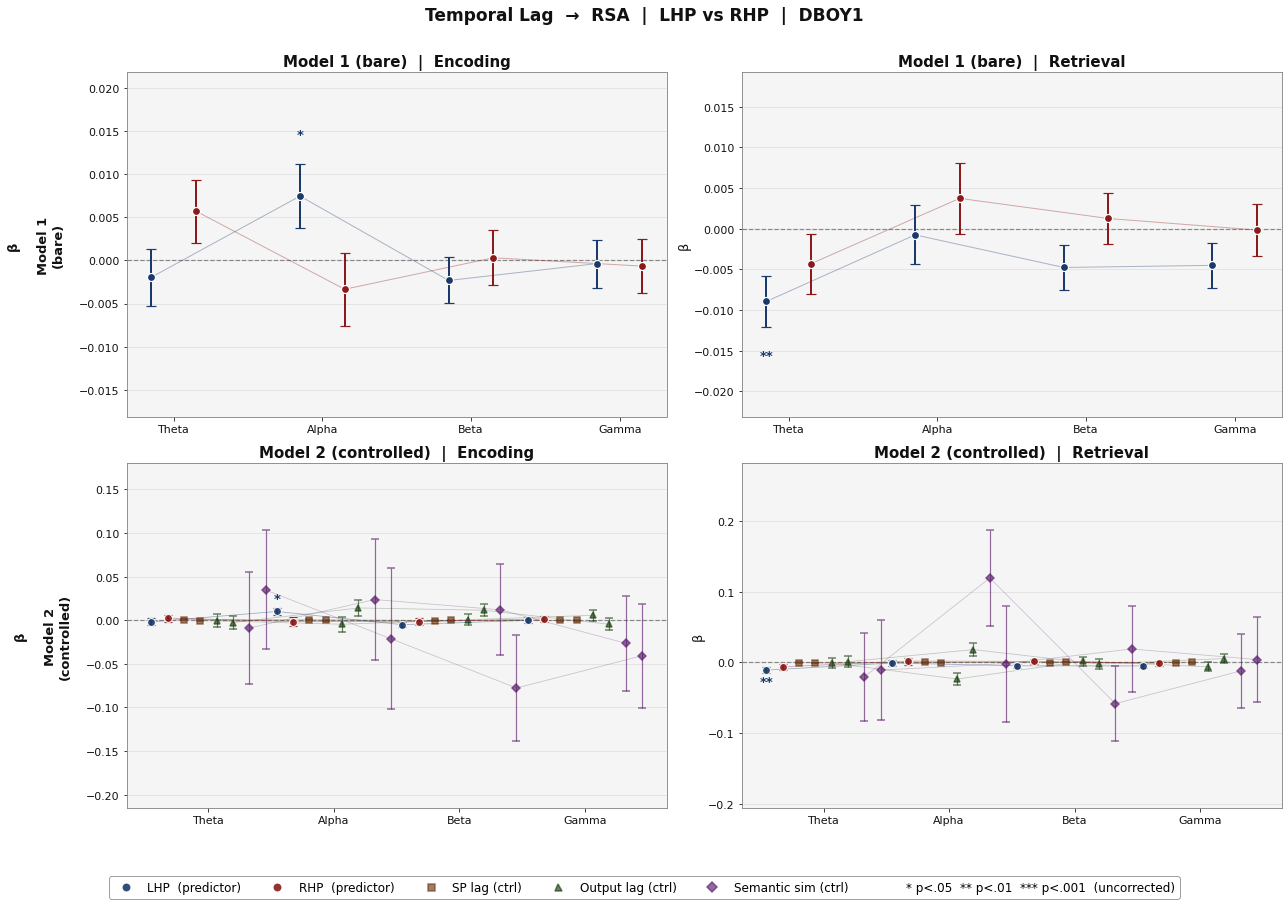


── Plotting SP_lag ──
✓ Saved → summary_SP_lag_DBOY1.png


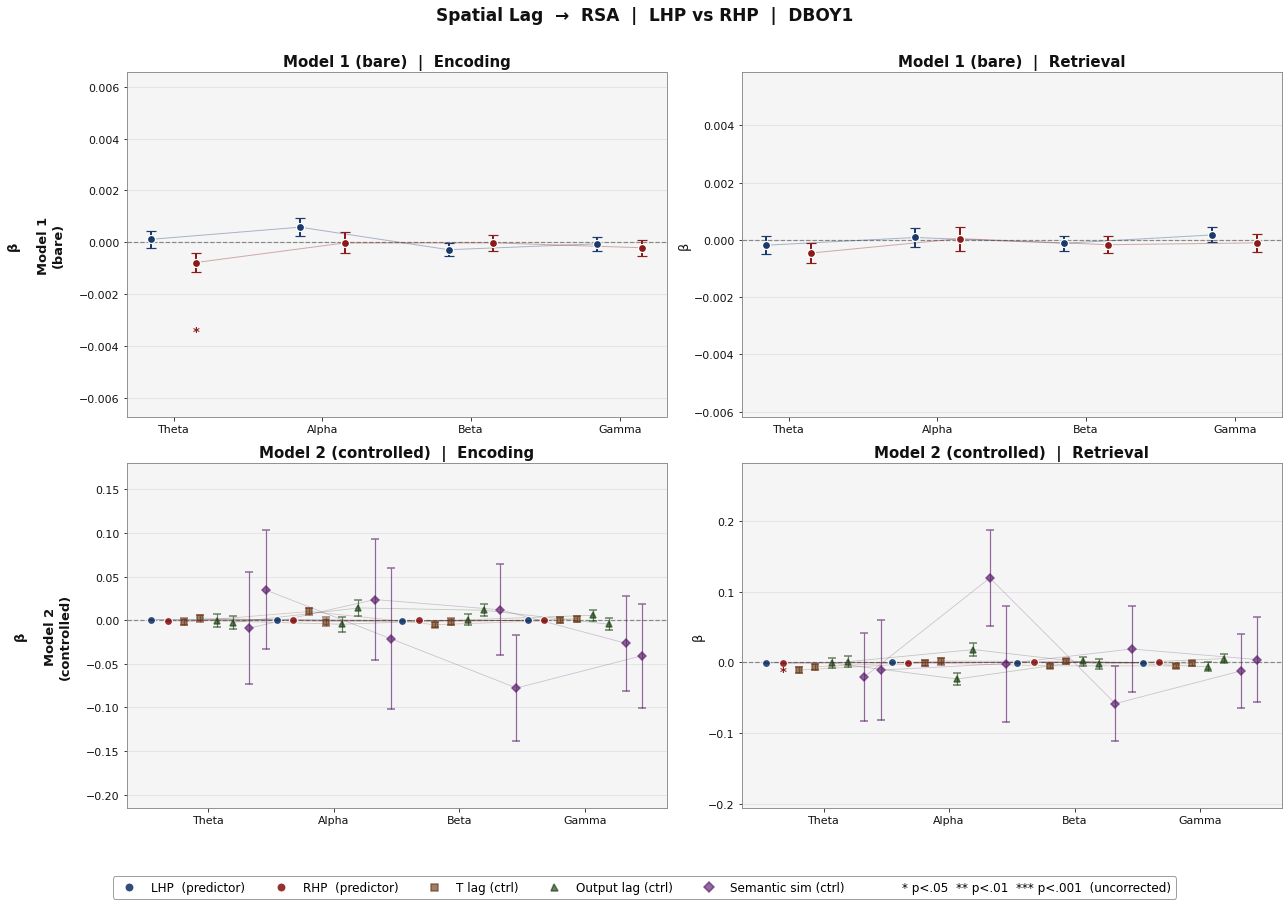


✓ All plots saved to rsa_lag_hc_bands_lmm/plots


In [13]:
#!/usr/bin/env python3
"""
Plot RSA Lag LMM Results
------------------------
Two figures:
  Figure 1 — T_lag predictor
  Figure 2 — SP_lag predictor

Each figure layout:
  Row 1 : Model 1 (bare)      — T_lag/SP_lag beta, LHP vs RHP side-by-side per band
  Row 2 : Model 2 (controlled)— predictor beta + covariate beta overlaid, LHP vs RHP

  Col 1 : Encoding  (RSA_r_enc)
  Col 2 : Retrieval (RSA_r_ret)

Color scheme (consistent across all plots):
  LHP          : dark blue   #1A3A6B
  RHP          : dark red    #8B1A1A
  Covariate    : brown       #6B3A1A
  Significance : * p<.05 (uncorrected), raw p values only

Error bars : SE from LMM
Background : white with dark text/spines
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

# ============================================================================
# CONFIGURATION — match analyze_iim_hc_bands.py
# ============================================================================

EXPERIMENT  = 'DBOY1'
INPUT_DIR   = Path('./rsa_lag_hc_bands_lmm')
OUTPUT_DIR  = Path('./rsa_lag_hc_bands_lmm/plots')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BANDS       = ['theta', 'alpha', 'beta', 'gamma']
REGIONS     = ['LHP', 'RHP']
OUTCOMES    = ['RSA_r_enc', 'RSA_r_ret']          # enc first (col 1), ret second (col 2)
PREDICTORS  = ['T_lag', 'SP_lag']
CROSS_COVARIATE = {'T_lag': 'SP_lag', 'SP_lag': 'T_lag'}

OUTCOME_LABELS  = {'RSA_r_enc': 'Encoding', 'RSA_r_ret': 'Retrieval'}
PRED_LABELS     = {'T_lag': 'Temporal Lag', 'SP_lag': 'Spatial Lag'}
CROSS_LABELS    = {'SP_lag': 'SP lag (ctrl)', 'T_lag': 'T lag (ctrl)',
                   'output_lag': 'Output lag (ctrl)', 'semantic_sim': 'Sem sim (ctrl)'}

# ---- Consistent color palette -----------------------------------------------
COLOR_LHP       = '#1A3A6B'   # dark blue
COLOR_RHP       = '#8B1A1A'   # dark red
COLOR_CROSS     = '#6B3A1A'   # brown  (cross-covariate)
COLOR_OUTLG     = '#1A4010'   # very dark green (output_lag covariate)
COLOR_SEMSIM    = '#5A1A6B'   # dark purple (semantic_sim covariate)
COLOR_ERR       = '#222222'   # error bar colour
BG_COLOR        = 'white'
AX_COLOR        = '#F5F5F5'
GRID_COLOR      = '#DDDDDD'
TEXT_COLOR      = '#111111'
SPINE_COLOR     = '#888888'

COVARIATE_COLORS = {
    'SP_lag':       COLOR_CROSS,
    'T_lag':        COLOR_CROSS,
    'output_lag':   COLOR_OUTLG,
    'semantic_sim': COLOR_SEMSIM,
}

# ---- Font sizes -------------------------------------------------------------
TITLE_FS    = 15
SUPTITLE_FS = 17
LABEL_FS    = 13
TICK_FS     = 11
LEGEND_FS   = 12
ANNOT_FS    = 13   # significance stars

BAR_WIDTH   = 0.32
BAR_GAP     = 0.04   # gap between LHP and RHP within a band

# ============================================================================
# HELPERS
# ============================================================================

def _style_ax(ax):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_FS)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, axis='y', color=GRID_COLOR, lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
        spine.set_linewidth(0.9)


def sig_star(p: float) -> str:
    """Uncorrected significance stars."""
    if np.isnan(p):
        return ''
    return ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else '')


def _annotate_bar(ax, x_center: float, bar_top: float, star: str, color: str):
    if not star:
        return
    offset = abs(bar_top) * 0.06 + 0.002
    y      = bar_top + offset if bar_top >= 0 else bar_top - offset
    va     = 'bottom' if bar_top >= 0 else 'top'
    ax.text(x_center, y, star,
            ha='center', va=va,
            color=color, fontsize=ANNOT_FS, fontweight='bold', zorder=6)


def load_master(experiment: str) -> pd.DataFrame:
    path = INPUT_DIR / 'LMM_ALL_results.csv'
    if not path.exists():
        raise FileNotFoundError(f"Master CSV not found: {path}")
    df = pd.read_csv(path)
    df = df[df['experiment'].str.startswith(experiment)].copy()
    print(f"Loaded {len(df):,} rows for experiment '{experiment}'")
    return df


def get_beta(df: pd.DataFrame,
             region: str, band: str, outcome: str,
             predictor_of_interest: str, model: str, col: str):
    """
    Extract (beta, se, p_raw) for a specific cell.
    Returns (nan, nan, nan) if not found.
    """
    sub = df[
        (df['region']                == region) &
        (df['band']                  == band) &
        (df['outcome']               == outcome) &
        (df['predictor_of_interest'] == predictor_of_interest) &
        (df['model']                 == model) &
        (df['col']                   == col)
    ]
    if sub.empty:
        return np.nan, np.nan, np.nan
    r = sub.iloc[0]
    return float(r['beta']), float(r['se']), float(r['p_raw'])


# ============================================================================
# PANEL DRAWING
# ============================================================================

def draw_model1_panel(ax, df: pd.DataFrame,
                      predictor: str, outcome: str):
    """
    Model 1 (bare): mean ± SE errorbar plot.
    LHP and RHP shown side-by-side at each band position.
    """
    x_centers = np.arange(len(BANDS), dtype=float)

    offsets = {
        'LHP': -0.15,
        'RHP':  0.15,
    }
    colors = {'LHP': COLOR_LHP, 'RHP': COLOR_RHP}

    # collect all beta±se extremes to set y-limits with star headroom
    y_extremes = []

    for region in REGIONS:
        betas, ses, ps = [], [], []
        for band in BANDS:
            b, s, p = get_beta(df, region, band, outcome,
                               predictor, 'Model1', predictor)
            betas.append(b); ses.append(s); ps.append(p)

        betas = np.array(betas, dtype=float)
        ses   = np.array(ses,   dtype=float)
        xpos  = x_centers + offsets[region]
        color = colors[region]

        ax.errorbar(xpos, betas,
                    yerr=np.where(np.isfinite(ses), ses, 0),
                    fmt='o', color=color,
                    ecolor=color, elinewidth=2.0,
                    capsize=5, capthick=2.0,
                    markersize=8, markeredgewidth=1.2,
                    markeredgecolor='white',
                    zorder=4, label=region)

        # connect dots with a faint line so bands read as a series
        valid = np.isfinite(betas)
        ax.plot(xpos[valid], betas[valid],
                color=color, lw=1.0, alpha=0.35, zorder=3)

        for xi, beta, se, p in zip(xpos, betas, ses, ps):
            star = sig_star(p)
            if star and np.isfinite(beta) and np.isfinite(se):
                tip = beta + se if beta >= 0 else beta - se
                _annotate_bar(ax, xi, tip, star, color)
            # track extremes including error bar tips
            if np.isfinite(beta) and np.isfinite(se):
                y_extremes.append(beta + se)
                y_extremes.append(beta - se)

    ax.axhline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_xticks(x_centers)
    ax.set_xticklabels([b.capitalize() for b in BANDS], fontsize=TICK_FS)
    ax.set_ylabel('β', fontsize=LABEL_FS)
    ax.set_title(
        f'Model 1 (bare)  |  {OUTCOME_LABELS[outcome]}',
        fontsize=TITLE_FS, fontweight='bold', pad=6)
    _style_ax(ax)

    # y-limits: span of beta±SE plus 30% headroom for stars
    if y_extremes:
        lo, hi = min(y_extremes), max(y_extremes)
        pad = (hi - lo) * 0.30 + 0.005
        ax.set_ylim(lo - pad, hi + pad)


def draw_model2_panel(ax, df: pd.DataFrame,
                      predictor: str, outcome: str):
    """
    Model 2 (controlled): mean ± SE errorbar plot.
    Predictor of interest: solid markers (LHP dark blue, RHP dark red).
    Covariates: open/distinct markers, covariate colours, offset slightly.
    All terms plotted at each band x-position with small horizontal offsets.
    """
    covariates = [CROSS_COVARIATE[predictor], 'output_lag']
    all_terms  = [predictor] + covariates

    # Check if semantic_sim exists
    check = df[
        (df['predictor_of_interest'] == predictor) &
        (df['outcome']               == outcome) &
        (df['model']                 == 'Model2') &
        (df['col']                   == 'semantic_sim')
    ]
    if not check.empty:
        all_terms.append('semantic_sim')

    x_centers = np.arange(len(BANDS), dtype=float)

    # Assign horizontal offsets: spread term×region combos symmetrically
    n_series  = len(all_terms) * len(REGIONS)
    slot_w    = 0.13
    offsets_all = np.linspace(-(n_series - 1) / 2 * slot_w,
                               (n_series - 1) / 2 * slot_w,
                               n_series)

    # Marker styles: predictor = filled circle; covariates = distinct open shapes
    markers = {predictor: 'o'}
    cov_markers = ['s', '^', 'D', 'v']
    for i, cv in enumerate(all_terms[1:]):
        markers[cv] = cov_markers[i % len(cov_markers)]

    colors_map = {'LHP': COLOR_LHP, 'RHP': COLOR_RHP}

    y_extremes = []
    slot_idx   = 0

    for term in all_terms:
        for region in REGIONS:
            betas, ses, ps = [], [], []
            for band in BANDS:
                b, s, p = get_beta(df, region, band, outcome,
                                   predictor, 'Model2', term)
                betas.append(b); ses.append(s); ps.append(p)

            betas = np.array(betas, dtype=float)
            ses   = np.array(ses,   dtype=float)
            xpos  = x_centers + offsets_all[slot_idx]

            if term == predictor:
                color     = colors_map[region]
                alpha     = 0.90
                msize     = 8
                lw        = 1.8
                mew       = 1.2
                mec       = 'white'
                zord      = 5
                linealpha = 0.40
            else:
                color     = COVARIATE_COLORS.get(term, COLOR_CROSS)
                alpha     = 0.65
                msize     = 6
                lw        = 1.2
                mew       = 1.5
                mec       = color
                zord      = 3
                linealpha = 0.25

            ax.errorbar(xpos, betas,
                        yerr=np.where(np.isfinite(ses), ses, 0),
                        fmt=markers[term],
                        color=color, alpha=alpha,
                        ecolor=color, elinewidth=lw,
                        capsize=4, capthick=lw,
                        markersize=msize,
                        markeredgewidth=mew,
                        markeredgecolor=mec,
                        zorder=zord)

            valid = np.isfinite(betas)
            ax.plot(xpos[valid], betas[valid],
                    color=color, lw=0.8, alpha=linealpha, zorder=zord - 1)

            # stars only on predictor of interest
            if term == predictor:
                for xi, beta, se, p in zip(xpos, betas, ses, ps):
                    star = sig_star(p)
                    if star and np.isfinite(beta) and np.isfinite(se):
                        tip = beta + se if beta >= 0 else beta - se
                        _annotate_bar(ax, xi, tip, star, color)

            for beta, se in zip(betas, ses):
                if np.isfinite(beta) and np.isfinite(se):
                    y_extremes.append(beta + se)
                    y_extremes.append(beta - se)

            slot_idx += 1

    ax.axhline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_xticks(x_centers)
    ax.set_xticklabels([b.capitalize() for b in BANDS], fontsize=TICK_FS)
    ax.set_ylabel('β', fontsize=LABEL_FS)
    ax.set_title(
        f'Model 2 (controlled)  |  {OUTCOME_LABELS[outcome]}',
        fontsize=TITLE_FS, fontweight='bold', pad=6)
    _style_ax(ax)

    if y_extremes:
        lo, hi = min(y_extremes), max(y_extremes)
        pad = (hi - lo) * 0.30 + 0.005
        ax.set_ylim(lo - pad, hi + pad)


# ============================================================================
# LEGEND BUILDER
# ============================================================================

def build_legend_handles(predictor: str, has_semsim: bool = False):
    cov_markers = ['s', '^', 'D']
    cross_term  = CROSS_COVARIATE[predictor]
    handles = [
        Line2D([0], [0], marker='o', color=COLOR_LHP, alpha=0.90,
               markersize=9, markeredgecolor='white', markeredgewidth=1.2,
               linewidth=0, label='LHP  (predictor)'),
        Line2D([0], [0], marker='o', color=COLOR_RHP, alpha=0.90,
               markersize=9, markeredgecolor='white', markeredgewidth=1.2,
               linewidth=0, label='RHP  (predictor)'),
        Line2D([0], [0], marker=cov_markers[0],
               color=COVARIATE_COLORS[cross_term], alpha=0.65,
               markersize=7, markeredgecolor=COVARIATE_COLORS[cross_term],
               markeredgewidth=1.5, linewidth=0,
               label=CROSS_LABELS[cross_term]),
        Line2D([0], [0], marker=cov_markers[1],
               color=COLOR_OUTLG, alpha=0.65,
               markersize=7, markeredgecolor=COLOR_OUTLG,
               markeredgewidth=1.5, linewidth=0,
               label='Output lag (ctrl)'),
    ]
    if has_semsim:
        handles.append(
            Line2D([0], [0], marker=cov_markers[2],
                   color=COLOR_SEMSIM, alpha=0.65,
                   markersize=7, markeredgecolor=COLOR_SEMSIM,
                   markeredgewidth=1.5, linewidth=0,
                   label='Semantic sim (ctrl)'))
    handles.append(
        Line2D([0], [0], color='none',
               label='* p<.05  ** p<.01  *** p<.001  (uncorrected)'))
    return handles


# ============================================================================
# FIGURE BUILDER
# ============================================================================

def make_predictor_figure(df: pd.DataFrame, predictor: str):
    """
    One figure for one predictor (T_lag or SP_lag).

    Layout:
      Rows : Model 1 (top) | Model 2 (bottom)
      Cols : Encoding (left) | Retrieval (right)
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.patch.set_facecolor(BG_COLOR)

    for col_idx, outcome in enumerate(OUTCOMES):        # enc=0, ret=1
        draw_model1_panel(axes[0, col_idx], df, predictor, outcome)
        draw_model2_panel(axes[1, col_idx], df, predictor, outcome)

    # Row labels on the left
    for row_idx, model_lbl in enumerate(['Model 1\n(bare)', 'Model 2\n(controlled)']):
        axes[row_idx, 0].set_ylabel(
            f'β\n\n{model_lbl}', fontsize=LABEL_FS, fontweight='bold',
            labelpad=14)

    # Check if semantic_sim present
    has_semsim = not df[
        (df['predictor_of_interest'] == predictor) &
        (df['model'] == 'Model2') &
        (df['col']   == 'semantic_sim')
    ].empty

    legend_handles = build_legend_handles(predictor, has_semsim)
    fig.legend(handles=legend_handles,
               loc='lower center', ncol=len(legend_handles),
               fontsize=LEGEND_FS, frameon=True,
               facecolor='white', edgecolor=SPINE_COLOR,
               bbox_to_anchor=(0.5, -0.03))

    fig.suptitle(
        f'{PRED_LABELS[predictor]}  →  RSA  |  LHP vs RHP  |  {EXPERIMENT}',
        fontsize=SUPTITLE_FS, fontweight='bold',
        color=TEXT_COLOR, y=1.01)

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    save_path = OUTPUT_DIR / f"summary_{predictor}_{EXPERIMENT}.png"
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    print(f"✓ Saved → {save_path.name}")
    plt.show()
    plt.close(fig)


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*70}")
    print(f"RSA Lag LMM Plot  |  {EXPERIMENT}")
    print(f"{'='*70}\n")

    df = load_master(EXPERIMENT)
    if df.empty:
        print("No data — exiting.")
        return

    for predictor in PREDICTORS:
        print(f"\n── Plotting {predictor} ──")
        make_predictor_figure(df, predictor)

    print(f"\n{'='*70}")
    print(f"✓ All plots saved to {OUTPUT_DIR}")
    print(f"{'='*70}")


if __name__ == '__main__':
    main()

In [41]:
#!/usr/bin/env python3
"""
LMM: T_lag × Hemisphere → RSA_r_ret
Band: theta only
Interaction test: does the T_lag effect differ between LHP and RHP?

Model:
    RSA_r_ret ~ T_lag * hemisphere + (1|subject) + (1|subj_sess)

where hemisphere is treatment-coded: LHP = 0 (reference), RHP = 1.

The key coefficient is T_lag:hemisphere[T.RHP] — a significant β means
the T_lag slope is reliably different in RHP vs LHP.
"""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENT  = 'DBOY1'
OUTCOME     = 'RSA_r_ret'
PREDICTOR   = 'T_lag'
BAND        = 'theta'
REGIONS     = ['LHP', 'RHP']                  # LHP = reference hemisphere

INPUT_DIR   = Path('./rsa_lag_hc_bands')
OUTPUT_DIR  = Path('./rsa_lag_hc_bands_lmm/hemisphere_interaction')
PLOT_DIR    = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Palette ----------------------------------------------------------------
BG_COLOR    = 'white'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
TEXT_COLOR  = '#222222'
SPINE_COLOR = '#AAAAAA'
REGION_COLORS = {'LHP': '#1A3A6B', 'RHP': '#8B1A1A'}


def sig_stars(p: float) -> str:
    return ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else '†' if p < 0.10 else 'ns')


def _style_ax(ax):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8.5)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR); sp.set_linewidth(0.8)


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data() -> pd.DataFrame:
    fpath = INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_hc_allbands_rsa_lag.csv"
    if not fpath.exists():
        raise FileNotFoundError(f"Master CSV not found: {fpath}")

    print(f"Loading {fpath.name} …")
    df = pd.read_csv(fpath)
    print(f"  Raw rows : {len(df):,}")

    # Keep theta band and the two hippocampal regions
    df = df[
        (df['band']   == BAND) &
        (df['region'].isin(REGIONS))
    ].copy()
    print(f"  After band={BAND!r}, regions={REGIONS}: {len(df):,} rows")

    if df.empty:
        raise ValueError("No data after filtering.")

    # Prefix subject IDs to avoid cross-experiment collisions
    df['subject'] = EXPERIMENT + '_' + df['subject'].astype(str)

    # Session-level grouping for nested random effect
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)

    # Treatment-code hemisphere: LHP = 0 (reference), RHP = 1
    df['hemisphere'] = pd.Categorical(
        df['region'], categories=['LHP', 'RHP'])

    print(f"  Subjects : {df['subject'].nunique()}")
    print(f"  Regions  : {sorted(df['region'].unique().tolist())}")
    print(f"  Outcome  : {OUTCOME}  — non-null: {df[OUTCOME].notna().sum():,}")
    return df


# ============================================================================
# LMM FITTING
# ============================================================================

def fit_interaction_model(df: pd.DataFrame) -> object:
    """
    Model: RSA_r_ret ~ T_lag * hemisphere + (1|subject) + (1|subj_sess)

    hemisphere is treatment-coded so:
      - Intercept         : mean RSA_r_ret for LHP at T_lag = 0
      - T_lag             : slope of T_lag in LHP  (reference hemisphere)
      - hemisphere[T.RHP] : RHP vs LHP intercept difference
      - T_lag:hemisphere  : difference in T_lag slope RHP vs LHP  ← KEY TEST
    """
    keep_cols = [OUTCOME, PREDICTOR, 'hemisphere', 'region', 'subject', 'subj_sess']
    df = df[keep_cols].dropna()
    print(f"\n  LMM rows after dropna : {len(df):,}")
    print(f"  Subjects              : {df['subject'].nunique()}")

    formula = f"{OUTCOME} ~ {PREDICTOR} * C(hemisphere, Treatment('LHP'))"
    print(f"  Formula: {formula}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'},
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            if np.isfinite(result.llf):
                print(f"  Optimizer: {method}  |  "
                      f"converged={getattr(result, 'converged', None)}  |  "
                      f"llf={result.llf:.4f}  AIC={result.aic:.4f}")
                break
            else:
                print(f"  llf=NaN with {method}, trying next …")
        except Exception as e:
            print(f"  {method} failed: {e}")
            result = None

    if result is None or not np.isfinite(result.llf):
        raise RuntimeError("All optimizers failed to converge.")
    return result, df


# ============================================================================
# RESULTS FORMATTING
# ============================================================================

def print_and_save_results(result, df: pd.DataFrame) -> pd.DataFrame:
    params   = result.params
    bse      = result.bse
    tvals    = result.tvalues
    pvals    = result.pvalues

    # FDR across all fixed-effect terms
    _, p_fdr = fdrcorrection(pvals.values)

    rows = []
    for i, (term, beta) in enumerate(params.items()):
        rows.append({
            'term'    : term,
            'beta'    : beta,
            'se'      : bse[term],
            'z'       : tvals[term],
            'p_raw'   : pvals[term],
            'p_fdr'   : p_fdr[i],
        })
    res_df = pd.DataFrame(rows)

    # ── Console / text report ────────────────────────────────────────────────
    sep  = '=' * 90
    sep2 = '-' * 90
    hdr  = (f"{'Term':<50} {'β':>8} {'SE':>8} {'z':>8} "
            f"{'p_raw':>10} {'p_fdr':>10} {'sig':>5}")
    lines = [
        sep,
        f"LMM: {OUTCOME} ~ {PREDICTOR} * hemisphere  |  Band={BAND}  |  {EXPERIMENT}",
        f"N rows={int(result.nobs):,}  |  subjects={df['subject'].nunique()}  |  "
        f"AIC={result.aic:.2f}  llf={result.llf:.4f}",
        sep2, hdr, sep2
    ]
    for _, row in res_df.iterrows():
        lines.append(
            f"{row['term']:<50} {row['beta']:>8.4f} {row['se']:>8.4f} "
            f"{row['z']:>8.3f} {row['p_raw']:>10.4f} "
            f"{row['p_fdr']:>10.4f} {sig_stars(row['p_fdr']):>5}"
        )
    lines += [
        sep2,
        "FDR: BH correction across all fixed-effect terms.",
        "† p<.10  * p<.05  ** p<.01  *** p<.001",
        "",
        "KEY TERMS:",
        f"  T_lag                          → T_lag slope in LHP (reference)",
        f"  C(hemisphere)[T.RHP]           → RHP vs LHP intercept difference",
        f"  T_lag:C(hemisphere)[T.RHP]     → Δslope RHP–LHP  ← INTERACTION TEST",
        sep
    ]
    report = '\n'.join(lines)
    print('\n' + report)

    txt_path = OUTPUT_DIR / f"LMM_{OUTCOME}_{PREDICTOR}_hemisphere_interaction.txt"
    csv_path = OUTPUT_DIR / f"LMM_{OUTCOME}_{PREDICTOR}_hemisphere_interaction.csv"
    with open(txt_path, 'w') as f:
        f.write(report)
    res_df.to_csv(csv_path, index=False)
    print(f"\n  ✓ Text  → {txt_path}")
    print(f"  ✓ CSV   → {csv_path}")
    return res_df


# ============================================================================
# PLOTS
# ============================================================================

def plot_interaction(df: pd.DataFrame, res_df: pd.DataFrame):
    """
    Two-panel figure:
      Left  — spaghetti: z-scored RSA_r_ret vs T_lag, one line per subject,
               separate panel per hemisphere, group mean ± SEM overlaid.
      Right — per-subject slope distributions (LHP vs RHP), with t-test
               comparing the two distributions.
    """
    outcome_z = f'{OUTCOME}_z'

    # Z-score RSA_r_ret within subject × hemisphere
    df = df.copy()
    def zscore_group(x):
        s = x.std()
        return (x - x.mean()) / s if s > 0 else x - x.mean()
    df[outcome_z] = df.groupby(['subject', 'region'])[OUTCOME].transform(zscore_group)

    # Bin T_lag (discrete lag values; keep top-20 most common)
    top_lags = sorted(
        df[PREDICTOR].value_counts().nlargest(20).index.tolist())

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor(BG_COLOR)

    # ── Panel A & B: spaghetti per hemisphere ──────────────────────────────
    for panel_idx, region in enumerate(REGIONS):
        ax    = axes[panel_idx]
        color = REGION_COLORS[region]
        _style_ax(ax)

        rdf = df[df['region'] == region].copy()

        subj_lines = []
        for subj, sg in rdf.groupby('subject'):
            sg = sg.dropna(subset=[PREDICTOR, outcome_z])
            pts = (sg.groupby(PREDICTOR)[outcome_z]
                     .mean().reindex(top_lags))
            pts = pts.dropna()
            if len(pts) < 2:
                continue
            subj_lines.append(pts.values)
            ax.plot(top_lags[:len(pts.values)], pts.values,
                    color=color, alpha=0.15, lw=0.9, zorder=2)

        if subj_lines:
            max_len  = max(len(s) for s in subj_lines)
            padded   = np.array([
                np.pad(s.astype(float), (0, max_len - len(s)),
                       constant_values=np.nan)
                for s in subj_lines])
            gm  = np.nanmean(padded, axis=0)
            gsem = (np.nanstd(padded, axis=0)
                    / np.sqrt((~np.isnan(padded)).sum(axis=0)))
            xg  = np.array(top_lags[:max_len])

            ax.fill_between(xg, gm - gsem, gm + gsem,
                            color=color, alpha=0.20, zorder=3)
            ax.plot(xg, gm, color=color, lw=2.5, zorder=4,
                    label=f'Group mean ± SEM  (n={rdf["subject"].nunique()})')

            valid = np.isfinite(gm) & np.isfinite(xg)
            if valid.sum() >= 2:
                m_z, b_z = np.polyfit(xg[valid], gm[valid], 1)
                r_val, p_val = pearsonr(xg[valid], gm[valid])
                p_str = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
                ax.plot(xg[valid], m_z * xg[valid] + b_z,
                        color=TEXT_COLOR, lw=1.5, ls='--', alpha=0.6,
                        zorder=5, label=f'OLS  r={r_val:.3f} {p_str}')

        ax.axhline(0, color=SPINE_COLOR, lw=1, ls=':', zorder=1)
        ax.set_xticks(top_lags)
        ax.set_xticklabels([str(int(v)) for v in top_lags],
                           fontsize=7, rotation=45)
        ax.set_xlabel('T_lag (list position gap)', fontsize=9)
        ax.set_ylabel(f'{OUTCOME}  (z-scored within subject × hemisphere)',
                      fontsize=9)
        ax.set_title(f'{region}  |  {BAND.capitalize()} band  |  {EXPERIMENT}',
                     fontsize=10, fontweight='bold')
        ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=8)

    # ── Panel C: per-subject slope comparison ─────────────────────────────
    ax = axes[2]
    _style_ax(ax)

    slopes_by_hemi = {}
    for region in REGIONS:
        rdf    = df[df['region'] == region].dropna(subset=[PREDICTOR, OUTCOME])
        slopes = []
        for subj, sg in rdf.groupby('subject'):
            sg = sg.dropna(subset=[PREDICTOR, OUTCOME])
            if len(sg) < 3 or sg[PREDICTOR].std() == 0:
                continue
            m, _ = np.polyfit(sg[PREDICTOR].values.astype(float),
                              sg[OUTCOME].values.astype(float), 1)
            slopes.append(m)
        slopes_by_hemi[region] = np.array(slopes)

    positions   = {'LHP': 1, 'RHP': 2}
    offset      = 0.08
    for region, slopes in slopes_by_hemi.items():
        color = REGION_COLORS[region]
        x_pos = positions[region]
        jitter = np.random.default_rng(42).uniform(-offset, offset, len(slopes))
        ax.scatter(x_pos + jitter, slopes,
                   color=color, alpha=0.5, s=30, zorder=3,
                   edgecolors='white', linewidths=0.4)
        mean_s = slopes.mean()
        sem_s  = slopes.std() / np.sqrt(len(slopes))
        ax.errorbar(x_pos, mean_s, yerr=1.96 * sem_s,
                    fmt='D', color=color, ecolor=color,
                    elinewidth=2, capsize=5, capthick=2,
                    markersize=8, zorder=5,
                    label=f'{region}  mean={mean_s:.4f}')

    # Look up interaction p-value from results
    interaction_row = res_df[res_df['term'].str.contains('T_lag.*RHP|RHP.*T_lag',
                                                          case=False, regex=True)]
    if not interaction_row.empty:
        p_int   = interaction_row.iloc[0]['p_fdr']
        b_int   = interaction_row.iloc[0]['beta']
        p_str   = f'p_fdr={p_int:.3f}' if p_int >= 0.001 else 'p_fdr<0.001'
        stars   = sig_stars(p_int)
        ax.text(1.5, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 0.01,
                f'Δβ={b_int:.4f}\n{stars}  {p_str}',
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', color=TEXT_COLOR)

    ax.axhline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['LHP', 'RHP'], fontsize=11)
    ax.set_ylabel(f'Per-subject OLS slope\n({OUTCOME} ~ T_lag)', fontsize=9)
    ax.set_title(f'Slope distribution by hemisphere\n'
                 f'{BAND.capitalize()} band  |  {EXPERIMENT}',
                 fontsize=10, fontweight='bold')
    ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=8)

    fig.suptitle(
        f'{OUTCOME} ~ T_lag × Hemisphere  |  {BAND.capitalize()} band  |  {EXPERIMENT}\n'
        f'Key test: T_lag:C(hemisphere)[T.RHP]  — is the T_lag slope different in RHP vs LHP?',
        fontsize=12, fontweight='bold', y=1.01, color=TEXT_COLOR)
    fig.tight_layout()

    save_path = PLOT_DIR / f"interaction_{OUTCOME}_{PREDICTOR}_hemisphere_{BAND}.png"
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"\n  ✓ Interaction plot → {save_path.name}")


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*80}")
    print(f"LMM: {OUTCOME} ~ {PREDICTOR} × Hemisphere  |  Band={BAND}  |  {EXPERIMENT}")
    print(f"{'='*80}")

    df              = load_data()
    result, df_fit  = fit_interaction_model(df)
    res_df          = print_and_save_results(result, df_fit)
    plot_interaction(df_fit, res_df)

    print(f"\n{'='*80}")
    print(f"✓ DONE  |  Results → {OUTPUT_DIR}")
    print(f"{'='*80}")


if __name__ == '__main__':
    main()
    


LMM: RSA_r_ret ~ T_lag × Hemisphere  |  Band=theta  |  DBOY1
Loading ALL_SUBJECTS_DBOY1_hc_allbands_rsa_lag.csv …
  Raw rows : 13,028
  After band='theta', regions=['LHP', 'RHP']: 3,257 rows
  Subjects : 34
  Regions  : ['LHP', 'RHP']
  Outcome  : RSA_r_ret  — non-null: 3,257

  LMM rows after dropna : 3,257
  Subjects              : 34
  Formula: RSA_r_ret ~ T_lag * C(hemisphere, Treatment('LHP'))
  Optimizer: lbfgs  |  converged=True  |  llf=-1842.9936  AIC=nan

LMM: RSA_r_ret ~ T_lag * hemisphere  |  Band=theta  |  DBOY1
N rows=3,257  |  subjects=34  |  AIC=nan  llf=-1842.9936
------------------------------------------------------------------------------------------
Term                                                      β       SE        z      p_raw      p_fdr   sig
------------------------------------------------------------------------------------------
Intercept                                            0.1326   0.1901    0.697     0.4856        nan    ns
C(hemisphere, Trea

In [12]:
#!/usr/bin/env python3
"""
STEP 1 — Per-subject controlled OLS fitting
=============================================
For each subject × region × outcome × predictor, fits a MULTIPLE regression:

    outcome ~ predictor  +  cross_covariate  +  output_lag  [+  semantic_sim]

Only the β (partial regression coefficient) of `predictor` is retained —
the control variables soak up shared variance but their betas are discarded.

This mirrors Model 2 from the original LMM script, applied subject-by-subject.

Outputs
-------
For each (region, outcome, predictor) combination:

  subject_slopes_{region}_{predictor}_{outcome}_theta.csv

Columns:
  subject | region | predictor | outcome | band
  beta          — partial β of predictor (controlling for covariates)
  se            — OLS standard error of that β
  t_stat        — t-statistic
  p_ols         — two-tailed p-value from OLS
  partial_r     — partial correlation of predictor after removing covariates
  n_pairs       — number of trials used
  n_covariates  — number of covariates actually included (for bookkeeping)

These CSVs are the sole input to Step 2.
"""

import warnings
from pathlib import Path
from typing import Optional, List

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENT    = 'DBOY1'
BAND          = 'theta'                       # fixed for this two-step analysis

INPUT_DIR     = Path('./rsa_lag_hc_bands')
STEP1_OUT_DIR = Path('./rsa_lag_hc_bands_step1')
STEP1_OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTCOMES    = ['RSA_r_ret', 'RSA_r_enc']
PREDICTORS  = ['SP_lag', 'T_lag']
REGIONS     = ['LHP']                         # LHP only (left hippocampus)

CROSS_COVARIATE = {
    'T_lag':  'SP_lag',
    'SP_lag': 'T_lag',
}

# Minimum trials for a subject to be included
MIN_PAIRS = 10


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data() -> Optional[pd.DataFrame]:
    fpath = INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_hc_allbands_rsa_lag.csv"

    if fpath.exists():
        print(f"  Loading {fpath.name} …")
        df = pd.read_csv(fpath)
        print(f"  Loaded {len(df):,} rows")
    else:
        print(f"  ✗ Master CSV not found: {fpath}")
        print("  Trying per-region/band fallback …")
        dfs = []
        for region in REGIONS:
            p = INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_{region}_{BAND}_rsa_lag.csv"
            if p.exists():
                dfs.append(pd.read_csv(p))
        if not dfs:
            print("  ✗ No fallback files found.")
            return None
        df = pd.concat(dfs, ignore_index=True)

    # Keep only theta band
    if 'band' in df.columns:
        df = df[df['band'] == BAND].copy()
        print(f"  Theta filter: {len(df):,} rows")

    # Keep only requested regions
    if 'region' in df.columns:
        df = df[df['region'].isin(REGIONS)].copy()
        print(f"  Region filter {REGIONS}: {len(df):,} rows")

    if df.empty:
        print("  ✗ No data after filtering.")
        return None

    df['subject'] = EXPERIMENT + '_' + df['subject'].astype(str)

    print(f"\n  Total rows   : {len(df):,}")
    print(f"  Subjects     : {df['subject'].nunique()}")
    print(f"  Regions      : {sorted(df['region'].unique().tolist())}")

    has_semsim = ('semantic_sim' in df.columns
                  and df['semantic_sim'].notna().any())
    print(f"  semantic_sim : {has_semsim}")
    return df


# ============================================================================
# PER-SUBJECT CONTROLLED OLS
# ============================================================================

def _partial_correlation(y: np.ndarray,
                         x_focus: np.ndarray,
                         x_controls: np.ndarray) -> float:
    """
    Partial correlation of y with x_focus after regressing out x_controls.
    Returns Pearson r on the residuals.
    """
    def resid(dep, indep):
        indep_c = sm.add_constant(indep, has_constant='add')
        try:
            return sm.OLS(dep, indep_c).fit().resid
        except Exception:
            return dep - dep.mean()

    ry = resid(y, x_controls)
    rx = resid(x_focus, x_controls)
    if rx.std() == 0 or ry.std() == 0:
        return np.nan
    r, _ = pearsonr(rx, ry)
    return r


def fit_subject_slopes(df: pd.DataFrame,
                       region: str,
                       predictor: str,
                       outcome: str,
                       has_semsim: bool) -> pd.DataFrame:
    """
    For each subject, fit the controlled multiple regression:

        outcome ~ predictor + cross_cov + output_lag [+ semantic_sim]

    Returns one row per subject containing only the β of `predictor`
    (the partial coefficient after controlling for all other regressors).
    """
    cross_cov = CROSS_COVARIATE[predictor]

    # Build covariate list; silently drop any column not present in data
    base_covariates: List[str] = [cross_cov, 'output_lag']
    if has_semsim:
        base_covariates.append('semantic_sim')

    all_cols  = [predictor, outcome] + base_covariates
    region_df = df[df['region'] == region].copy()

    # Only keep columns that actually exist
    present_cols = [c for c in all_cols if c in region_df.columns]
    region_df    = region_df[['subject'] + present_cols].dropna()

    # Covariates we can actually use
    covariates = [c for c in base_covariates if c in region_df.columns]
    all_needed = ['subject', predictor, outcome] + covariates

    rows = []
    skipped = {'too_few': 0, 'zero_var': 0, 'fit_error': 0}

    for subj, sg in region_df.groupby('subject'):
        sg = sg[all_needed].dropna()

        if len(sg) < MIN_PAIRS:
            skipped['too_few'] += 1
            continue

        y       = sg[outcome].values.astype(float)
        x_focus = sg[predictor].values.astype(float)
        x_ctrl  = sg[covariates].values.astype(float) if covariates \
                  else np.empty((len(sg), 0))

        if x_focus.std() == 0:
            skipped['zero_var'] += 1
            continue

        # Design matrix: intercept | predictor | covariates
        # predictor is always column index 1 after the intercept
        if x_ctrl.shape[1] > 0:
            X = np.column_stack([x_focus, x_ctrl])
        else:
            X = x_focus.reshape(-1, 1)
        X = sm.add_constant(X, has_constant='add')

        try:
            ols_res = sm.OLS(y, X).fit()
        except Exception as e:
            print(f"    [{subj}] OLS failed: {e}")
            skipped['fit_error'] += 1
            continue

        # Index 1 is always the predictor of interest (right after intercept)
        beta   = ols_res.params[1]
        se     = ols_res.bse[1]
        t_stat = ols_res.tvalues[1]
        p_ols  = ols_res.pvalues[1]

        # Partial correlation: predictor with outcome after removing covariates
        if x_ctrl.shape[1] > 0:
            part_r = _partial_correlation(y, x_focus, x_ctrl)
        else:
            part_r, _ = pearsonr(x_focus, y)

        rows.append({
            'subject':      subj,
            'region':       region,
            'predictor':    predictor,
            'outcome':      outcome,
            'band':         BAND,
            'beta':         beta,
            'se':           se,
            't_stat':       t_stat,
            'p_ols':        p_ols,
            'partial_r':    part_r,
            'n_pairs':      len(sg),
            'n_covariates': len(covariates),
        })

    result_df = pd.DataFrame(rows)

    n_fit = len(result_df)
    print(f"    {region} | {predictor} → {outcome}: "
          f"{n_fit} subjects fit  "
          f"(skipped: too_few={skipped['too_few']}, "
          f"zero_var={skipped['zero_var']}, "
          f"fit_error={skipped['fit_error']})")
    if n_fit > 0:
        print(f"      covariates : {covariates}")
        print(f"      mean β     = {result_df['beta'].mean():.4f}  "
              f"std={result_df['beta'].std():.4f}  "
              f"mean n_pairs={result_df['n_pairs'].mean():.1f}")

    return result_df


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*70}")
    print(f"STEP 1 — Per-subject controlled OLS  |  {EXPERIMENT}  |  {BAND.upper()} band")
    print(f"Regions : {REGIONS}  (fitted separately)")
    print(f"Model   : outcome ~ predictor + cross_cov + output_lag [+ semsim]")
    print(f"Output  : β of predictor only (partial coefficient)")
    print(f"{'='*70}")

    df = load_data()
    if df is None or df.empty:
        print("No data loaded. Exiting.")
        return

    has_semsim = ('semantic_sim' in df.columns
                  and df['semantic_sim'].notna().any())

    summary_rows = []

    for region in REGIONS:
        print(f"\n{'─'*60}")
        print(f"REGION: {region}")
        print(f"{'─'*60}")

        for outcome in OUTCOMES:
            for predictor in PREDICTORS:
                print(f"\n  {outcome} ~ {predictor} + controls")

                slopes_df = fit_subject_slopes(
                    df, region, predictor, outcome, has_semsim)

                if slopes_df.empty:
                    print(f"    ✗ No subjects fit — skipping save")
                    continue

                tag      = f"{region}_{predictor}_{outcome}_{BAND}"
                out_path = STEP1_OUT_DIR / f"subject_slopes_{tag}.csv"
                slopes_df.to_csv(out_path, index=False)
                print(f"    ✓ Saved {len(slopes_df)} subjects → {out_path.name}")

                summary_rows.append({
                    'region':         region,
                    'predictor':      predictor,
                    'outcome':        outcome,
                    'band':           BAND,
                    'n_subjects':     len(slopes_df),
                    'mean_beta':      slopes_df['beta'].mean(),
                    'std_beta':       slopes_df['beta'].std(),
                    'pct_positive':   (slopes_df['beta'] > 0).mean() * 100,
                    'mean_partial_r': slopes_df['partial_r'].mean(),
                    'mean_n_pairs':   slopes_df['n_pairs'].mean(),
                    'n_covariates':   slopes_df['n_covariates'].iloc[0],
                })

    # ── Summary table ──────────────────────────────────────────────────────
    if summary_rows:
        summary_df   = pd.DataFrame(summary_rows)
        summary_path = STEP1_OUT_DIR / 'step1_summary.csv'
        summary_df.to_csv(summary_path, index=False)
        print(f"\n  ✓ Summary → {summary_path.name}")
        print(f"\n{'─'*60}")
        print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    print(f"\n{'='*70}")
    print(f"✓ STEP 1 COMPLETE  |  outputs → {STEP1_OUT_DIR}")
    print(f"  Run step2_group_test.py next.")
    print(f"{'='*70}")


if __name__ == '__main__':
    main()


STEP 1 — Per-subject controlled OLS  |  DBOY1  |  THETA band
Regions : ['LHP']  (fitted separately)
Model   : outcome ~ predictor + cross_cov + output_lag [+ semsim]
Output  : β of predictor only (partial coefficient)
  Loading ALL_SUBJECTS_DBOY1_hc_allbands_rsa_lag.csv …
  Loaded 13,028 rows
  Theta filter: 3,257 rows
  Region filter ['LHP']: 1,814 rows

  Total rows   : 1,814
  Subjects     : 27
  Regions      : ['LHP']
  semantic_sim : True

────────────────────────────────────────────────────────────
REGION: LHP
────────────────────────────────────────────────────────────

  RSA_r_ret ~ SP_lag + controls
    LHP | SP_lag → RSA_r_ret: 19 subjects fit  (skipped: too_few=6, zero_var=0, fit_error=0)
      covariates : ['T_lag', 'output_lag', 'semantic_sim']
      mean β     = -0.0008  std=0.0026  mean n_pairs=71.8
    ✓ Saved 19 subjects → subject_slopes_LHP_SP_lag_RSA_r_ret_theta.csv

  RSA_r_ret ~ T_lag + controls
    LHP | T_lag → RSA_r_ret: 19 subjects fit  (skipped: too_few=6, ze

In [13]:
#!/usr/bin/env python3
"""
STEP 2 — Group-level testing
==============================
Reads per-subject slope CSVs produced by Step 1 and performs:

  (a) One-sample t-test:  mean(slope) ≠ 0  (non-parametric sign test as backup)
  (b) Group-level LMM on the raw trial data (outcome ~ predictor, random
      intercept per subject) — for a proper mixed-effects estimate alongside
      the two-step slopes summary.

Restricted to THETA band, LHP and RHP treated as SEPARATE analyses.

Outputs
-------
  ./rsa_lag_hc_bands_step2/
      group_ttest_results.csv          — t-test / sign-test table
      LMM_{tag}_results.csv            — per-combination LMM table
      LMM_ALL_results.csv              — master merged LMM table
      plots/
          slopes_dotplot_{region}_{predictor}_{outcome}_theta.png
          forest_{region}_{predictor}_{outcome}_theta.png
          summary_heatmap_{region}_{outcome}_theta.png
"""

import warnings
from pathlib import Path
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, pearsonr
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENT     = 'DBOY1'
BAND           = 'theta'

STEP1_OUT_DIR  = Path('./rsa_lag_hc_bands_step1')   # input: Step 1 CSVs
RAW_INPUT_DIR  = Path('./rsa_lag_hc_bands')          # input: raw data (for LMM)
OUTPUT_DIR     = Path('./rsa_lag_hc_bands_step2')
PLOT_DIR       = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTCOMES    = ['RSA_r_ret', 'RSA_r_enc']
PREDICTORS  = ['SP_lag', 'T_lag']
REGIONS     = ['LHP', 'RHP']

OUTCOME_LABELS = {
    'RSA_r_ret': 'Retrieval RSA',
    'RSA_r_enc': 'Encoding RSA',
}
PRED_LABELS = {
    'T_lag':  'Temporal Lag (T_lag)',
    'SP_lag': 'Spatial Lag (SP_lag)',
}
CROSS_COVARIATE = {
    'T_lag':  'SP_lag',
    'SP_lag': 'T_lag',
}

# ---- Palette ----------------------------------------------------------------
BG_COLOR    = 'white'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
TEXT_COLOR  = '#222222'
SPINE_COLOR = '#AAAAAA'

REGION_COLORS = {
    'LHP': '#1A3A6B',
    'RHP': '#8B1A1A',
}


# ============================================================================
# HELPERS
# ============================================================================

def sig_stars(p: float) -> str:
    return ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else
            '†'   if p < 0.10  else '')


def _style_ax(ax):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8.5)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
        spine.set_linewidth(0.8)


# ============================================================================
# STEP 2a — ONE-SAMPLE T-TEST ON SUBJECT SLOPES
# ============================================================================

def run_ttest(slopes_df: pd.DataFrame,
              region: str,
              predictor: str,
              outcome: str) -> dict:
    # Step 1 saves the column as 'beta' (partial coefficient)
    betas = slopes_df['beta'].values
    n     = len(betas)
    if n < 3:
        return {}

    t_stat, p_two = ttest_1samp(betas, 0.0)
    mean_b  = betas.mean()
    sem_b   = betas.std(ddof=1) / np.sqrt(n)
    ci95_lo = mean_b - 1.96 * sem_b
    ci95_hi = mean_b + 1.96 * sem_b

    # Sign test (non-parametric backup)
    # scipy 1.7+ uses binomtest; older versions use binom_test
    n_pos = (betas > 0).sum()
    n_neg = (betas < 0).sum()
    try:
        from scipy.stats import binomtest
        p_sign = binomtest(int(n_pos), int(n_pos + n_neg), 0.5,
                           alternative='two-sided').pvalue
    except ImportError:
        from scipy.stats import binom_test
        p_sign = binom_test(int(n_pos), int(n_pos + n_neg), 0.5,
                            alternative='two-sided')

    return {
        'region':     region,
        'predictor':  predictor,
        'outcome':    outcome,
        'band':       BAND,
        'n_subjects': n,
        'mean_beta':  mean_b,
        'sem_beta':   sem_b,
        'ci95_lo':    ci95_lo,
        'ci95_hi':    ci95_hi,
        't_stat':     t_stat,
        'p_ttest':    p_two,
        'n_pos':      n_pos,
        'n_neg':      n_neg,
        'p_sign':     p_sign,
    }


# ============================================================================
# STEP 2b — GROUP-LEVEL LMM ON RAW TRIAL DATA
# ============================================================================

def load_raw_data() -> Optional[pd.DataFrame]:
    fpath = RAW_INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_hc_allbands_rsa_lag.csv"
    if fpath.exists():
        df = pd.read_csv(fpath)
    else:
        dfs = []
        for region in REGIONS:
            p = RAW_INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_{region}_{BAND}_rsa_lag.csv"
            if p.exists():
                dfs.append(pd.read_csv(p))
        if not dfs:
            return None
        df = pd.concat(dfs, ignore_index=True)

    if 'band' in df.columns:
        df = df[df['band'] == BAND].copy()
    if 'region' in df.columns:
        df = df[df['region'].isin(REGIONS)].copy()
    if df.empty:
        return None

    df['subject'] = EXPERIMENT + '_' + df['subject'].astype(str)
    return df


def fit_lmm(df: pd.DataFrame,
            pred_cols: List[str],
            label: str,
            outcome: str,
            formula_rhs: Optional[str] = None) -> Tuple[Optional[object], int]:
    df = df.copy()
    df['subj_sess'] = (df['subject'].astype(str)
                       + '_' + df['session'].astype(str))

    real_cols = [c for c in pred_cols if c in df.columns]
    keep      = [outcome] + real_cols + ['subject', 'subj_sess']
    df        = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    rhs     = formula_rhs if formula_rhs else ' + '.join(pred_cols)
    formula = f"{outcome} ~ {rhs}"
    print(f"    [{label}] {formula}  |  N={len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'},
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            if np.isfinite(result.llf):
                print(f"    [{label}] optimizer={method}  "
                      f"converged={getattr(result, 'converged', None)}  "
                      f"llf={result.llf:.4f}  AIC={result.aic:.4f}")
                break
            else:
                result = None
        except Exception as e:
            print(f"    [{label}] {method} failed: {e}")
            result = None

    if result is None or not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: fit unsuccessful.")
    return result, len(df)


def extract_lmm_rows(result,
                     pred_display: dict,
                     model_label: str,
                     predictor: str,
                     region: str,
                     outcome: str) -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits    = [k for k in result.params.index
                       if col.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            continue
        rows.append({
            'experiment': EXPERIMENT,
            'outcome':    outcome,
            'region':     region,
            'predictor':  predictor,
            'band':       BAND,
            'model':      model_label,
            'term':       name,
            'col':        col,
            'beta':       result.params[matched],
            'se':         result.bse[matched],
            'z':          result.tvalues[matched],
            'p_raw':      result.pvalues[matched],
            'llf':        result.llf,
            'aic':        result.aic,
            'nobs':       int(result.nobs),
        })
    return pd.DataFrame(rows)


def run_lmm_for_combination(raw_df: pd.DataFrame,
                            region: str,
                            predictor: str,
                            outcome: str,
                            has_semsim: bool) -> pd.DataFrame:
    sub = raw_df[raw_df['region'] == region].copy()
    if sub.empty:
        return pd.DataFrame()

    cross_cov   = CROSS_COVARIATE[predictor]
    all_rows    = []

    # Model 1: bare
    res1, _ = fit_lmm(sub, [predictor], f'M1_{region}_{predictor}_{outcome}',
                       outcome)
    rows1 = extract_lmm_rows(res1, {predictor: PRED_LABELS[predictor]},
                               'Model1', predictor, region, outcome)
    rows1 = _fdr(rows1)
    if not rows1.empty:
        all_rows.append(rows1)

    # Model 2: controlled
    ctrl_cols = [predictor, cross_cov, 'output_lag']
    ctrl_disp = {
        predictor:    PRED_LABELS[predictor],
        cross_cov:    f'{PRED_LABELS[cross_cov]}  [covariate]',
        'output_lag': 'output_lag',
    }
    if has_semsim:
        ctrl_cols.append('semantic_sim')
        ctrl_disp['semantic_sim'] = 'semantic_sim'

    res2, _ = fit_lmm(sub, ctrl_cols, f'M2_{region}_{predictor}_{outcome}',
                       outcome)
    rows2 = extract_lmm_rows(res2, ctrl_disp, 'Model2',
                               predictor, region, outcome)
    rows2 = _fdr(rows2)
    if not rows2.empty:
        all_rows.append(rows2)

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


def _fdr(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    _, df['p_fdr'] = fdrcorrection(df['p_raw'].values)
    return df


# ============================================================================
# PLOTTING
# ============================================================================

def plot_slopes_dotplot(slopes_df: pd.DataFrame,
                        ttest_row: dict,
                        region: str,
                        predictor: str,
                        outcome: str,
                        save_path: Path):
    """Per-subject beta dot-plot with group mean ± 95% CI and t-test result."""
    color  = REGION_COLORS.get(region, '#444444')
    betas  = slopes_df['beta'].values          # Step 1 saves 'beta', not 'slope'
    n      = len(betas)
    order  = np.argsort(betas)

    fig, ax = plt.subplots(figsize=(9, max(4, n * 0.28 + 2)))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    dot_colors = [color if s >= 0 else '#999999' for s in betas[order]]
    y_pos = np.arange(n)

    ax.scatter(betas[order], y_pos,
               c=dot_colors, s=45, zorder=3,
               edgecolors='white', linewidths=0.5)
    for yi, si, dc in zip(y_pos, betas[order], dot_colors):
        ax.plot([0, si], [yi, yi], color=dc, alpha=0.35, lw=0.9, zorder=2)

    mean_sl = ttest_row.get('mean_beta', betas.mean())
    ci_lo   = ttest_row.get('ci95_lo', mean_sl - 1.96 * betas.std() / np.sqrt(n))
    ci_hi   = ttest_row.get('ci95_hi', mean_sl + 1.96 * betas.std() / np.sqrt(n))

    ax.axvline(0,       color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.axvspan(ci_lo, ci_hi, color=color, alpha=0.12, zorder=0)
    ax.axvline(mean_sl, color=color, lw=2.5, zorder=4,
               label=f'Mean={mean_sl:.4f}  95%CI=[{ci_lo:.4f}, {ci_hi:.4f}]')

    p_t  = ttest_row.get('p_ttest', np.nan)
    p_s  = ttest_row.get('p_sign',  np.nan)
    stars = sig_stars(p_t)
    label_text = (f"{stars}  t-test p={p_t:.3f}  |  sign-test p={p_s:.3f}"
                  if stars else
                  f"t-test p={p_t:.3f}  |  sign-test p={p_s:.3f}")
    ax.text(mean_sl, n + 0.2, label_text,
            ha='center', va='bottom', color=color, fontsize=8.5, fontweight='bold')

    n_pos = ttest_row.get('n_pos', (betas > 0).sum())
    n_neg = ttest_row.get('n_neg', (betas < 0).sum())
    ax.set_yticks([])
    ax.set_xlabel(f'Partial β  ({outcome} ~ {predictor} + controls)', fontsize=9)
    ax.set_title(
        f'{region}  |  {OUTCOME_LABELS[outcome]} ~ {PRED_LABELS[predictor]}\n'
        f'{BAND.capitalize()} band  |  '
        f'{n_neg}/{n} negative, {n_pos}/{n} positive  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold')
    ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=8)
    ax.text(0.02, 0.03,
            f'{n_neg / n * 100:.0f}% of subjects show negative β',
            transform=ax.transAxes, fontsize=8, color=TEXT_COLOR, style='italic')

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"    ✓ Dot-plot → {save_path.name}")


def plot_forest_lmm(lmm_df: pd.DataFrame,
                    region: str,
                    predictor: str,
                    outcome: str,
                    save_path: Path):
    """Forest plot of LMM β for Model1 and Model2."""
    df = lmm_df[
        (lmm_df['region']    == region) &
        (lmm_df['predictor'] == predictor) &
        (lmm_df['outcome']   == outcome) &
        (lmm_df['col']       == predictor)
    ].copy()

    if df.empty:
        return

    df['ci_lo'] = df['beta'] - 1.96 * df['se']
    df['ci_hi'] = df['beta'] + 1.96 * df['se']

    color  = REGION_COLORS.get(region, '#444444')
    models = [m for m in ['Model1', 'Model2'] if m in df['model'].values]

    MODEL_LABELS = {'Model1': 'Bare  (M1)', 'Model2': 'Controlled  (M2)'}

    fig, ax = plt.subplots(figsize=(9, max(3, len(models) * 1.6 + 1)))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    y_pos, yticks, ylabels = 0, [], []
    for model in models:
        row = df[df['model'] == model]
        if row.empty:
            continue
        row  = row.iloc[0]
        xerr = [[row['beta'] - row['ci_lo']], [row['ci_hi'] - row['beta']]]
        ax.errorbar(row['beta'], y_pos, xerr=xerr,
                    fmt='o', color=color, ecolor=color,
                    elinewidth=1.8, capsize=5, capthick=1.8,
                    markersize=8, zorder=3)
        p_show = row.get('p_fdr', row['p_raw'])
        stars  = sig_stars(p_show)
        if stars:
            offset = abs(row['ci_hi'] - row['beta']) * 0.15 + 0.001
            ax.text(row['ci_hi'] + offset, y_pos, stars,
                    color=color, va='center', fontsize=10, fontweight='bold')
        yticks.append(y_pos)
        ylabels.append(MODEL_LABELS.get(model, model))
        y_pos -= 1

    ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel(f'LMM β  ({PRED_LABELS[predictor]})', fontsize=10)
    ax.set_title(
        f'{region}  |  {OUTCOME_LABELS[outcome]} ~ {PRED_LABELS[predictor]}\n'
        f'{BAND.capitalize()} band  (group-level LMM)  [{EXPERIMENT}]',
        fontsize=11, fontweight='bold', pad=8)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"    ✓ Forest (LMM) → {save_path.name}")


def plot_summary_heatmap(ttest_df: pd.DataFrame,
                         region: str,
                         outcome: str,
                         save_path: Path):
    """
    2×2 heatmap (predictor × model: ttest / LMM) showing mean_slope or β,
    annotated with significance stars.
    Rows = predictors, Cols = {T-test mean slope, LMM M1 β, LMM M2 β}
    """
    sub = ttest_df[
        (ttest_df['region']  == region) &
        (ttest_df['outcome'] == outcome)
    ].copy()

    if sub.empty:
        print(f"  No t-test rows for heatmap: {region} / {outcome}")
        return

    cols  = ['mean_beta', 't_stat', 'p_ttest']
    pivot = sub.set_index('predictor')[cols]

    betas  = pivot['mean_beta'].values.reshape(1, -1).astype(float)
    labels = [PRED_LABELS[p] for p in pivot.index]

    fig, ax = plt.subplots(figsize=(7, 2.5))
    fig.patch.set_facecolor(BG_COLOR)

    vmax = np.nanmax(np.abs(betas)) or 1.0
    im   = ax.imshow(betas, aspect='auto', cmap='RdBu_r',
                     vmin=-vmax, vmax=vmax)

    for j, pred in enumerate(pivot.index):
        val   = pivot.loc[pred, 'mean_beta']
        p_val = pivot.loc[pred, 'p_ttest']
        star  = sig_stars(p_val)
        t_val = pivot.loc[pred, 't_stat']
        if not np.isnan(val):
            cell_norm = (val + vmax) / (2 * vmax)
            txt_color = 'white' if (cell_norm < 0.35 or cell_norm > 0.65) else TEXT_COLOR
            ax.text(j, 0,
                    f"β={val:.4f}\nt={t_val:.2f}\n{star}",
                    ha='center', va='center',
                    color=txt_color, fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([0])
    ax.set_yticklabels(['Mean slope\n(t-test)'], fontsize=9)
    ax.tick_params(colors=TEXT_COLOR)

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label('Mean subject slope', fontsize=8, color=TEXT_COLOR)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_COLOR)

    ax.set_title(
        f'{region}  |  {OUTCOME_LABELS[outcome]}  |  '
        f'{BAND.capitalize()} band  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold', pad=8, color=TEXT_COLOR)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Heatmap → {save_path.name}")


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*70}")
    print(f"STEP 2 — Group-level tests  |  {EXPERIMENT}  |  {BAND.upper()} band")
    print(f"Regions: {REGIONS}  (analysed separately)")
    print(f"{'='*70}")

    # ------------------------------------------------------------------
    # 2a  Load Step-1 slopes and run t-tests
    # ------------------------------------------------------------------
    print("\n── 2a: One-sample t-tests on Step-1 slopes ──")

    ttest_rows  = []
    slopes_dict = {}   # (region, predictor, outcome) → DataFrame

    for region in REGIONS:
        for outcome in OUTCOMES:
            for predictor in PREDICTORS:
                tag  = f"{region}_{predictor}_{outcome}_{BAND}"
                fpath = STEP1_OUT_DIR / f"subject_slopes_{tag}.csv"
                if not fpath.exists():
                    print(f"  ✗ Missing: {fpath.name} — skipping")
                    continue

                slopes_df = pd.read_csv(fpath)
                # Normalise column name: old runs saved 'slope', new ones 'beta'
                if 'slope' in slopes_df.columns and 'beta' not in slopes_df.columns:
                    slopes_df = slopes_df.rename(columns={'slope': 'beta'})
                print(f"    columns: {slopes_df.columns.tolist()}")
                slopes_dict[(region, predictor, outcome)] = slopes_df

                row = run_ttest(slopes_df, region, predictor, outcome)
                if row:
                    ttest_rows.append(row)
                    stars = sig_stars(row['p_ttest'])
                    print(f"  {region} | {predictor} → {outcome}: "
                          f"mean β={row['mean_beta']:.4f}  "
                          f"t={row['t_stat']:.3f}  p={row['p_ttest']:.4f} {stars}")

    ttest_df = pd.DataFrame(ttest_rows)
    if not ttest_df.empty:
        # FDR across all combinations
        _, ttest_df['p_ttest_fdr'] = fdrcorrection(ttest_df['p_ttest'].values)
        _, ttest_df['p_sign_fdr']  = fdrcorrection(ttest_df['p_sign'].values)
        ttest_path = OUTPUT_DIR / 'group_ttest_results.csv'
        ttest_df.to_csv(ttest_path, index=False)
        print(f"\n  ✓ T-test results → {ttest_path.name}")
        print(f"\n{ttest_df.to_string(index=False, float_format=lambda x: f'{x:.4f}')}")

    # ------------------------------------------------------------------
    # 2b  Load raw data and fit group-level LMMs
    # ------------------------------------------------------------------
    print("\n── 2b: Group-level LMM on raw trial data ──")

    raw_df = load_raw_data()
    if raw_df is None or raw_df.empty:
        print("  ✗ Raw data not found — skipping LMM step")
        raw_df = None

    has_semsim = (raw_df is not None and
                  'semantic_sim' in raw_df.columns and
                  raw_df['semantic_sim'].notna().any())

    ALL_LMM_RESULTS = []

    if raw_df is not None:
        for region in REGIONS:
            for outcome in OUTCOMES:
                for predictor in PREDICTORS:
                    print(f"\n  {region} | {predictor} → {outcome} | {BAND}")
                    lmm_df = run_lmm_for_combination(
                        raw_df, region, predictor, outcome, has_semsim)

                    if not lmm_df.empty:
                        ALL_LMM_RESULTS.append(lmm_df)
                        tag      = f"{region}_{predictor}_{outcome}_{BAND}"
                        out_path = OUTPUT_DIR / f"LMM_{tag}_results.csv"
                        lmm_df.to_csv(out_path, index=False)
                        print(f"    ✓ LMM results → {out_path.name}")

    if ALL_LMM_RESULTS:
        master_lmm = pd.concat(ALL_LMM_RESULTS, ignore_index=True)
        master_path = OUTPUT_DIR / 'LMM_ALL_results.csv'
        master_lmm.to_csv(master_path, index=False)
        print(f"\n  ✓ Master LMM → {master_path.name}  ({len(master_lmm):,} rows)")
    else:
        master_lmm = pd.DataFrame()

    # ------------------------------------------------------------------
    # 2c  Plots
    # ------------------------------------------------------------------
    print("\n── 2c: Generating plots ──")

    for region in REGIONS:
        for outcome in OUTCOMES:

            # Summary heatmap (one per region × outcome)
            if not ttest_df.empty:
                plot_summary_heatmap(
                    ttest_df, region, outcome,
                    PLOT_DIR / f"summary_heatmap_{region}_{outcome}_{BAND}.png")

            for predictor in PREDICTORS:
                key = (region, predictor, outcome)

                # Per-subject dot-plot from Step-1 slopes
                if key in slopes_dict and not ttest_df.empty:
                    trow_sub = ttest_df[
                        (ttest_df['region']    == region) &
                        (ttest_df['predictor'] == predictor) &
                        (ttest_df['outcome']   == outcome)
                    ]
                    trow = trow_sub.iloc[0].to_dict() if not trow_sub.empty else {}

                    plot_slopes_dotplot(
                        slopes_dict[key], trow,
                        region, predictor, outcome,
                        PLOT_DIR / f"slopes_dotplot_{region}_{predictor}_{outcome}_{BAND}.png")

                # Forest plot from LMM results
                if not master_lmm.empty:
                    plot_forest_lmm(
                        master_lmm, region, predictor, outcome,
                        PLOT_DIR / f"forest_{region}_{predictor}_{outcome}_{BAND}.png")

    print(f"\n{'='*70}")
    print(f"✓ STEP 2 COMPLETE  |  {EXPERIMENT}  |  {BAND.upper()} band")
    print(f"  Results : {OUTPUT_DIR}")
    print(f"  Plots   : {PLOT_DIR}")
    print(f"{'='*70}")


if __name__ == '__main__':
    main()


STEP 2 — Group-level tests  |  DBOY1  |  THETA band
Regions: ['LHP', 'RHP']  (analysed separately)

── 2a: One-sample t-tests on Step-1 slopes ──
    columns: ['subject', 'region', 'predictor', 'outcome', 'band', 'beta', 'se', 't_stat', 'p_ols', 'partial_r', 'n_pairs', 'n_covariates']
  LHP | SP_lag → RSA_r_ret: mean β=-0.0008  t=-1.287  p=0.2145 
    columns: ['subject', 'region', 'predictor', 'outcome', 'band', 'beta', 'se', 't_stat', 'p_ols', 'partial_r', 'n_pairs', 'n_covariates']
  LHP | T_lag → RSA_r_ret: mean β=-0.0085  t=-1.507  p=0.1492 
    columns: ['subject', 'region', 'predictor', 'outcome', 'band', 'beta', 'se', 't_stat', 'p_ols', 'partial_r', 'n_pairs', 'n_covariates']
  LHP | SP_lag → RSA_r_enc: mean β=0.0010  t=2.243  p=0.0378 *
    columns: ['subject', 'region', 'predictor', 'outcome', 'band', 'beta', 'se', 't_stat', 'p_ols', 'partial_r', 'n_pairs', 'n_covariates']
  LHP | T_lag → RSA_r_enc: mean β=-0.0062  t=-1.465  p=0.1602 
    columns: ['subject', 'region', 'pred

In [20]:
#!/usr/bin/env python3
"""
RSA Lag — Sequential LMM Analysis (4 Steps) — RAW SCALE (no z-scoring)
========================================================================
Identical logic to rsa_lag_sequential_lmm.py but predictors and outcome
are kept on their original scales.  Between-subject baseline differences
are absorbed by the random intercept (1|subject).

Betas are in original units:
  RSA_r   : Pearson r  (roughly −1 to +1, typically −0.3 to +0.3)
  T_lag   : number of list positions separating the two items
  SP_lag  : Euclidean distance in store-coordinate units
  output_lag : number of recall output positions between the two items

Why run without z-scoring?
  - Betas are directly interpretable in substantive units
  - No assumption that within-subject SD is comparable across subjects/bands
  - Avoids the zero-variance group problem for output_lag (values 1–4)
  - Random intercept per subject already removes between-subject mean differences

Trade-off: betas are NOT comparable across predictors (T_lag vs SP_lag
have different scales) or across bands (if band means differ).

Steps
-----
  Step 1 — RSA_r ~ predictor + output_lag + experiment + (1|subj)
            All bands pooled, both hemispheres.

  Step 2 — RSA_r ~ predictor + band_alpha + band_beta + band_gamma
                 + predictor_x_alpha + predictor_x_beta + predictor_x_gamma
                 + output_lag + experiment + (1|subj)
            Tests whether predictor slope differs across bands
            (theta = reference level).

  Step 3 — RSA_r ~ predictor + hemisphere_dummy + predictor_x_hemi
                 + output_lag + experiment + (1|subj)
            Theta band only.  Tests LHP vs RHP asymmetry.
            Also run separately for LHP and RHP.

  Step 4 — RSA_r ~ T_lag + SP_lag + output_lag + experiment + (1|subj)
            Theta band only.  Tests independence of T_lag and SP_lag.

Input  : ./rsa_lag_hc_bands/ALL_SUBJECTS_{exp}_hc_allbands_rsa_lag.csv
Output : ./rsa_lag_hc_bands/SEQUENTIAL_LMM_RAW_results.csv
         ./rsa_lag_hc_bands/SEQUENTIAL_LMM_RAW_results.txt
"""

import warnings
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENTS   = ['DBOY1', 'EFRCourierReadOnly']
INPUT_DIR     = Path('./rsa_lag_hc_bands')
OUTPUT_DIR    = Path('./rsa_lag_hc_bands')

BANDS         = ['theta', 'alpha', 'beta', 'gamma']
NON_REF_BANDS = ['alpha', 'beta', 'gamma']   # theta = reference

OUTCOME = 'RSA_r'   # raw, no z-scoring


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data() -> Optional[pd.DataFrame]:
    dfs = []
    for exp in EXPERIMENTS:
        fpath = INPUT_DIR / f"ALL_SUBJECTS_{exp}_hc_allbands_rsa_lag.csv"
        if fpath.exists():
            tmp = pd.read_csv(fpath)
            tmp['experiment'] = exp
            dfs.append(tmp)
            print(f"  Loaded {fpath.name}  ({len(tmp):,} rows)")
        else:
            print(f"  ✗ No file for {exp} — skipping")

    if not dfs:
        return None

    df = pd.concat(dfs, ignore_index=True)

    if 'hemisphere' not in df.columns:
        df['hemisphere'] = df['region'].map({'LHP': 'left', 'RHP': 'right'})

    df['subject'] = df['experiment'].astype(str) + '_' + df['subject'].astype(str)

    df['hemisphere_dummy'] = (df['hemisphere'] == 'right').astype(int)
    ref_exp = 'DBOY1' if 'DBOY1' in df['experiment'].unique() \
              else df['experiment'].unique()[0]
    df['experiment_dummy'] = (df['experiment'] != ref_exp).astype(int)

    print(f"\n  Total rows : {len(df):,}")
    print(f"  Subjects   : {df['subject'].nunique()}")
    print(f"  Bands      : {sorted(df['band'].unique().tolist())}")
    print(f"  Regions    : {sorted(df['region'].unique().tolist())}")

    # Descriptive stats so reader knows raw scales
    print(f"\n  Predictor scales (raw):")
    for col in ['RSA_r', 'T_lag', 'SP_lag', 'output_lag']:
        if col in df.columns:
            s = df[col].dropna()
            print(f"    {col:<12} mean={s.mean():.3f}  "
                  f"sd={s.std():.3f}  "
                  f"range=[{s.min():.2f}, {s.max():.2f}]")

    return df


# ============================================================================
# LMM FITTING
# ============================================================================

def fit_lmm(df: pd.DataFrame,
            formula_cols: List[str],
            formula_rhs: str,
            label: str) -> Optional[object]:
    """
    Fit RSA_r ~ formula_rhs.

    Random effects strategy (tried in order):
      1. Nested: (1|subject) + (1|subject:session)  via vc_formula
      2. Simple : (1|subject) only — fallback if nested hits a boundary
    """
    df = df.copy()
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)

    keep = [OUTCOME] + [c for c in formula_cols if c in df.columns] \
           + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    n = len(df)
    if n < 20:
        print(f"  [{label}] Too few rows ({n}) — skipping")
        return None

    formula = f"{OUTCOME} ~ {formula_rhs}"
    print(f"\n  [{label}] {formula}")
    print(f"  [{label}] N={n:,}  subjects={df['subject'].nunique()}")

    def _is_boundary(res) -> bool:
        if res is None or not np.isfinite(res.llf):
            return True
        for k in res.params.index:
            if 'subj_sess' in k.lower():
                if abs(res.params[k] - 16.0) < 1e-6:
                    return True
                if not np.isfinite(res.bse[k]):
                    return True
        return False

    # Attempt 1: nested random effects
    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            model = MixedLM.from_formula(
                formula,
                data       = df,
                groups     = df['subject'],
                vc_formula = {'subj_sess': '0 + C(subj_sess)'},
            )
            res = model.fit(reml=True, method=method)
            if np.isfinite(res.llf) and not _is_boundary(res):
                print(f"  [{label}] nested RE  optimizer={method}  "
                      f"converged={getattr(res, 'converged', None)}")
                result = res
                break
        except Exception:
            pass

    # Attempt 2: subject-only random effects
    if result is None or _is_boundary(result):
        print(f"  [{label}] ⚠ Nested RE boundary — "
              f"falling back to (1|subject) only")
        for method in ['lbfgs', 'nm', 'powell']:
            try:
                model = MixedLM.from_formula(
                    formula,
                    data   = df,
                    groups = df['subject'],
                )
                res = model.fit(reml=True, method=method)
                if np.isfinite(res.llf):
                    print(f"  [{label}] subject-only RE  optimizer={method}  "
                          f"converged={getattr(res, 'converged', None)}")
                    result = res
                    break
            except Exception as e:
                print(f"  [{label}] subject-only {method} failed: {e}")
                result = None

    if result is None:
        print(f"  [{label}] WARNING: all fits unsuccessful")
    return result


# ============================================================================
# RESULT FORMATTING
# ============================================================================

def sig_stars(p: float) -> str:
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else '†'  if p < 0.10  else '')


def result_to_df(result, step: str, model_desc: str,
                 hemisphere: str = 'combined') -> pd.DataFrame:
    """
    Extract all terms.  FDR applied only to fixed-effect rows
    with finite p-values.  Random-effect rows tagged with is_re=True.
    """
    if result is None:
        return pd.DataFrame()

    rows = []
    for term in result.params.index:
        p_val = result.pvalues[term]
        is_re = (not np.isfinite(result.bse[term]) or
                 not np.isfinite(p_val) or
                 'var' in term.lower())
        rows.append({
            'step':       step,
            'model':      model_desc,
            'hemisphere': hemisphere,
            'term':       term,
            'beta':       result.params[term],
            'se':         result.bse[term],
            'z':          result.tvalues[term],
            'p_raw':      p_val,
            'p_fdr':      np.nan,
            'is_re':      is_re,
            'nobs':       int(result.nobs),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    fe_mask = (~df['is_re']) & df['p_raw'].notna() & np.isfinite(df['p_raw'])
    if fe_mask.sum() > 0:
        _, fdr_vals = fdrcorrection(df.loc[fe_mask, 'p_raw'].values)
        df.loc[fe_mask, 'p_fdr'] = fdr_vals

    return df


def print_table(df: pd.DataFrame, title: str):
    if df.empty:
        print(f"\n  [no results for: {title}]")
        return

    sep  = '=' * 95
    sep2 = '-' * 95
    hdr  = (f"{'Term':<45} {'β':>10} {'SE':>10} {'z':>8} "
            f"{'p_raw':>10} {'p_fdr':>10} {'N':>8}")

    print(f"\n{sep}")
    print(title)
    print(sep2)
    print(hdr)
    print(sep2)

    fe = df[~df['is_re']] if 'is_re' in df.columns else df
    for _, row in fe.iterrows():
        p_fdr = row.get('p_fdr', np.nan)
        p_fdr_str = f"{p_fdr:>10.4f}" if np.isfinite(p_fdr) else f"{'—':>10}"
        stars = sig_stars(p_fdr) if np.isfinite(p_fdr) else ''
        print(f"  {row['term']:<43} {row['beta']:>10.5f} {row['se']:>10.5f} "
              f"{row['z']:>8.3f} {row['p_raw']:>10.4f} "
              f"{p_fdr_str} {int(row['nobs']):>8,}  {stars}")

    re = df[df['is_re']] if 'is_re' in df.columns else pd.DataFrame()
    if not re.empty:
        print(f"  {'— random effects —'}")
        for _, row in re.iterrows():
            beta_str = f"{row['beta']:>10.5f}" if np.isfinite(row['beta']) else f"{'—':>10}"
            print(f"  {row['term']:<43} {beta_str}")

    print(sep2)
    print("  Outcome = RSA_r (raw Pearson r).  "
          "Predictors on raw scale (T_lag: list positions, "
          "SP_lag: distance units, output_lag: recall positions).")
    print("  FDR: BH within fixed effects only.  "
          "† p<.10  * p<.05  ** p<.01  *** p<.001")
    print(f"  Reference: band=theta, hemisphere=LHP, experiment=DBOY1")
    print(sep)


# ============================================================================
# STEP 1 — Does the effect exist?
# ============================================================================

def step1(df: pd.DataFrame) -> List[pd.DataFrame]:
    """
    RSA_r ~ predictor + output_lag + experiment_dummy + (1|subj)
    All bands pooled, both hemispheres.
    """
    print(f"\n{'#'*70}")
    print("STEP 1 — Does RSA_r track T_lag / SP_lag at all?")
    print(f"{'#'*70}")
    print("  Data: all bands pooled, both hemispheres")
    print("  Covariate: output_lag (raw, not z-scored)")

    results = []
    for pred in ['T_lag', 'SP_lag']:
        res = fit_lmm(
            df,
            formula_cols = [pred, 'output_lag', 'experiment_dummy'],
            formula_rhs  = f'{pred} + output_lag + experiment_dummy',
            label        = f'Step1 {pred}',
        )
        rdf = result_to_df(res, step='Step1',
                           model_desc=f'RSA_r ~ {pred} + output_lag')
        print_table(rdf,
                    f"Step 1 | RSA_r ~ {pred} + output_lag + experiment"
                    f"  [all bands, combined]")
        results.append(rdf)

    return results


# ============================================================================
# STEP 2 — Is the effect theta-specific?
# ============================================================================

def step2(df: pd.DataFrame) -> List[pd.DataFrame]:
    """
    RSA_r ~ predictor
           + band_alpha + band_beta + band_gamma
           + predictor_x_alpha + predictor_x_beta + predictor_x_gamma
           + output_lag + experiment_dummy + (1|subj)

    Interaction terms = "is this band's slope ≠ theta slope?"
    """
    print(f"\n{'#'*70}")
    print("STEP 2 — Is the effect theta-specific?")
    print(f"{'#'*70}")
    print("  Data: all bands pooled, both hemispheres")
    print("  Reference band: theta")
    print("  KEY TERMS: predictor_x_{{alpha/beta/gamma}}")
    print("             significant → that band's slope ≠ theta slope")

    df = df.copy()
    for band in NON_REF_BANDS:
        df[f'band_{band}'] = (df['band'] == band).astype(float)

    results = []
    for pred in ['T_lag', 'SP_lag']:

        for band in NON_REF_BANDS:
            df[f'{pred}_x_{band}'] = df[pred] * df[f'band_{band}']

        band_cols  = [f'band_{b}'     for b in NON_REF_BANDS]
        inter_cols = [f'{pred}_x_{b}' for b in NON_REF_BANDS]

        formula_cols = [pred] + band_cols + inter_cols \
                       + ['output_lag', 'experiment_dummy']
        formula_rhs  = (f'{pred} + '
                        + ' + '.join(band_cols) + ' + '
                        + ' + '.join(inter_cols)
                        + ' + output_lag + experiment_dummy')

        res = fit_lmm(df, formula_cols, formula_rhs,
                      label=f'Step2 {pred}')
        rdf = result_to_df(res, step='Step2',
                           model_desc=f'RSA_r ~ {pred} * band + output_lag')
        print_table(rdf,
                    f"Step 2 | RSA_r ~ {pred} * band + output_lag + experiment"
                    f"  [all bands, combined]\n"
                    f"  KEY: {pred}_x_{{band}} significant → slope ≠ theta")
        results.append(rdf)

    return results


# ============================================================================
# STEP 3 — Is the theta effect lateralized?
# ============================================================================

def step3(df: pd.DataFrame) -> List[pd.DataFrame]:
    """
    Theta band only.
    RSA_r ~ predictor + hemisphere_dummy + predictor_x_hemi
           + output_lag + experiment_dummy + (1|subj)
    Also simple slopes for LHP and RHP separately.
    """
    print(f"\n{'#'*70}")
    print("STEP 3 — Is the theta effect lateralized?  (theta band only)")
    print(f"{'#'*70}")

    theta_df = df[df['band'] == 'theta'].copy()
    print(f"  Theta rows: {len(theta_df):,}  "
          f"subjects: {theta_df['subject'].nunique()}")

    results = []
    for pred in ['T_lag', 'SP_lag']:
        inter_col = f'{pred}_x_hemi'
        theta_df[inter_col] = theta_df[pred] * theta_df['hemisphere_dummy']

        # Combined: interaction test
        res = fit_lmm(
            theta_df,
            formula_cols = [pred, 'hemisphere_dummy', inter_col,
                            'output_lag', 'experiment_dummy'],
            formula_rhs  = (f'{pred} + hemisphere_dummy + {inter_col}'
                            f' + output_lag + experiment_dummy'),
            label        = f'Step3 {pred} combined',
        )
        rdf = result_to_df(res, step='Step3',
                           model_desc=f'RSA_r ~ {pred} * hemisphere + output_lag',
                           hemisphere='combined')
        print_table(rdf,
                    f"Step 3 | RSA_r ~ {pred} * hemisphere + output_lag  "
                    f"[theta, combined]\n"
                    f"  KEY TERM: {inter_col}  "
                    f"(significant → LHP slope ≠ RHP slope)")
        results.append(rdf)

        # Simple slopes: LHP and RHP separately
        for hemi, hemi_label in [('left', 'LHP'), ('right', 'RHP')]:
            hd = theta_df[theta_df['hemisphere'] == hemi].copy()
            res_h = fit_lmm(
                hd,
                formula_cols = [pred, 'output_lag', 'experiment_dummy'],
                formula_rhs  = f'{pred} + output_lag + experiment_dummy',
                label        = f'Step3 {pred} {hemi_label}',
            )
            rdf_h = result_to_df(res_h, step='Step3',
                                 model_desc=f'RSA_r ~ {pred} + output_lag',
                                 hemisphere=hemi_label)
            print_table(rdf_h,
                        f"Step 3 | RSA_r ~ {pred} + output_lag + experiment  "
                        f"[theta, {hemi_label} only]")
            results.append(rdf_h)

    return results


# ============================================================================
# STEP 4 — Do T_lag and SP_lag survive mutual control?
# ============================================================================

def step4(df: pd.DataFrame) -> List[pd.DataFrame]:
    """
    Theta band only.
    RSA_r ~ T_lag + SP_lag + output_lag + experiment_dummy + (1|subj)
    Combined, LHP, RHP.
    """
    print(f"\n{'#'*70}")
    print("STEP 4 — Do T_lag and SP_lag survive mutual control?  (theta only)")
    print(f"{'#'*70}")

    theta_df = df[df['band'] == 'theta'].copy()
    print(f"  Theta rows: {len(theta_df):,}  "
          f"subjects: {theta_df['subject'].nunique()}")

    formula_cols = ['T_lag', 'SP_lag', 'output_lag', 'experiment_dummy']
    formula_rhs  = 'T_lag + SP_lag + output_lag + experiment_dummy'

    results = []
    for subset_label, subset_df in [
            ('combined', theta_df),
            ('LHP',      theta_df[theta_df['hemisphere'] == 'left']),
            ('RHP',      theta_df[theta_df['hemisphere'] == 'right'])]:

        res = fit_lmm(
            subset_df,
            formula_cols = formula_cols,
            formula_rhs  = formula_rhs,
            label        = f'Step4 {subset_label}',
        )
        rdf = result_to_df(res, step='Step4',
                           model_desc='RSA_r ~ T_lag + SP_lag + output_lag',
                           hemisphere=subset_label)
        print_table(rdf,
                    f"Step 4 | RSA_r ~ T_lag + SP_lag + output_lag  "
                    f"[theta, {subset_label}]")
        results.append(rdf)

    return results


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*70}")
    print("RSA LAG — SEQUENTIAL LMM ANALYSIS  (RAW SCALE, no z-scoring)")
    print(f"{'='*70}")

    df = load_data()
    if df is None or df.empty:
        print("No data loaded. Exiting.")
        return

    print(f"\n  Note: no z-scoring applied. Betas are in raw units.")
    print(f"  Between-subject differences absorbed by (1|subject) random intercept.")

    all_results = []
    all_results += step1(df)
    all_results += step2(df)
    all_results += step3(df)
    all_results += step4(df)

    if all_results:
        master = pd.concat(all_results, ignore_index=True)
        csv_path = OUTPUT_DIR / 'SEQUENTIAL_LMM_RAW_results.csv'
        master.to_csv(csv_path, index=False)
        print(f"\n  ✓ Results saved → {csv_path}")
        print(f"  Total result rows: {len(master):,}")

    print(f"\n{'='*70}")
    print("INTERPRETATION GUIDE")
    print(f"{'='*70}")
    print("""
  Betas are in raw units — not SD units.  Interpretation:
    T_lag   β : change in RSA_r per additional list-position gap
    SP_lag  β : change in RSA_r per additional store-distance unit
    output_lag β : change in RSA_r per additional recall-position gap

  Step 1: T_lag/SP_lag significant after controlling for output_lag?
          → a genuine clustering effect exists, not just recall order.

  Step 2: predictor_x_alpha/beta/gamma significant?
          → theta slope differs from that band (formal specificity test).
          NOT significant → effect is not theta-specific.

  Step 3: predictor_x_hemi significant?
          → LHP and RHP slopes are genuinely different.
          Simple slopes show which hemisphere drives the effect.

  Step 4: Both T_lag and SP_lag survive together?
          → temporal and spatial clustering are INDEPENDENT contributions.
    """)

    # ── Save text output ──────────────────────────────────────────────────────
    txt_path = OUTPUT_DIR / 'SEQUENTIAL_LMM_RAW_results.txt'
    if all_results:
        lines = []
        for rdf in all_results:
            if rdf.empty:
                continue
            step = rdf['step'].iloc[0]
            model = rdf['model'].iloc[0]
            hemi  = rdf['hemisphere'].iloc[0]
            lines.append(f"\n{'='*80}")
            lines.append(f"{step}  |  {model}  |  {hemi}")
            lines.append(f"{'='*80}")
            fe = rdf[~rdf['is_re']]
            for _, row in fe.iterrows():
                p_fdr = row['p_fdr']
                stars = sig_stars(p_fdr) if np.isfinite(p_fdr) else ''
                lines.append(
                    f"  {row['term']:<40} β={row['beta']:>10.5f}  "
                    f"SE={row['se']:>9.5f}  z={row['z']:>7.3f}  "
                    f"p={row['p_raw']:>8.4f}  "
                    f"p_fdr={p_fdr:>8.4f}  {stars}"
                    if np.isfinite(p_fdr) else
                    f"  {row['term']:<40} β={row['beta']:>10.5f}  "
                    f"SE={row['se']:>9.5f}  z={row['z']:>7.3f}  "
                    f"p={row['p_raw']:>8.4f}"
                )
        with open(txt_path, 'w') as f:
            f.write('\n'.join(lines))
        print(f"  ✓ Text output   → {txt_path}")


if __name__ == '__main__':
    main()


RSA LAG — SEQUENTIAL LMM ANALYSIS  (RAW SCALE, no z-scoring)
  Loaded ALL_SUBJECTS_DBOY1_hc_allbands_rsa_lag.csv  (13,028 rows)
  Loaded ALL_SUBJECTS_EFRCourierReadOnly_hc_allbands_rsa_lag.csv  (1,712 rows)

  Total rows : 14,740
  Subjects   : 39
  Bands      : ['alpha', 'beta', 'gamma', 'theta']
  Regions    : ['LHP', 'RHP']

  Predictor scales (raw):
    RSA_r        mean=0.088  sd=0.416  range=[-1.00, 1.00]
    T_lag        mean=4.489  sd=2.894  range=[1.00, 11.00]
    SP_lag       mean=70.740  sd=30.713  range=[12.95, 142.72]
    output_lag   mean=2.416  sd=1.535  range=[1.00, 10.00]

  Note: no z-scoring applied. Betas are in raw units.
  Between-subject differences absorbed by (1|subject) random intercept.

######################################################################
STEP 1 — Does RSA_r track T_lag / SP_lag at all?
######################################################################
  Data: all bands pooled, both hemispheres
  Covariate: output_lag (raw, not z-score

In [2]:
#!/usr/bin/env python3
"""
RSA Lag — Sequential LMM Analysis (4 Steps) — RAW SCALE, DBOY1 only
========================================================================
Identical logic to rsa_lag_sequential_lmm_raw.py but restricted to the
DBOY1 experiment only, so no experiment covariate is needed.

Betas are in original units:
  RSA_r      : Pearson r
  T_lag      : number of list positions separating the two items
  SP_lag     : Euclidean distance in store-coordinate units
  output_lag : number of recall output positions between the two items

Steps
-----
  Step 1 — RSA_r ~ predictor + output_lag + (1|subj)
            All bands pooled, both hemispheres.

  Step 2 — RSA_r ~ predictor * band (explicit dummies, theta = reference)
                 + output_lag + (1|subj)
            Tests whether predictor slope differs across bands.

  Step 3 — RSA_r ~ predictor * hemisphere + output_lag + (1|subj)
            Theta band only.  Tests LHP vs RHP asymmetry.
            Also run separately for LHP and RHP.

  Step 4 — RSA_r ~ T_lag + SP_lag + output_lag + (1|subj)
            Theta band only.  Tests independence of T_lag and SP_lag.

Input  : ./rsa_lag_hc_bands/ALL_SUBJECTS_DBOY1_hc_allbands_rsa_lag.csv
Output : ./rsa_lag_hc_bands/SEQUENTIAL_LMM_RAW_DBOY1_results.csv
         ./rsa_lag_hc_bands/SEQUENTIAL_LMM_RAW_DBOY1_results.txt
"""

import warnings
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

INPUT_DIR     = Path('./rsa_lag_hc_bands')
OUTPUT_DIR    = Path('./rsa_lag_hc_bands')

BANDS         = ['theta', 'alpha', 'beta', 'gamma']
NON_REF_BANDS = ['alpha', 'beta', 'gamma']   # theta = reference

OUTCOME = 'RSA_r'


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data() -> Optional[pd.DataFrame]:
    fpath = INPUT_DIR / "ALL_SUBJECTS_DBOY1_hc_allbands_rsa_lag.csv"
    if not fpath.exists():
        print(f"  ✗ File not found: {fpath}")
        return None

    df = pd.read_csv(fpath)
    print(f"  Loaded {fpath.name}  ({len(df):,} rows)")

    if 'hemisphere' not in df.columns:
        df['hemisphere'] = df['region'].map({'LHP': 'left', 'RHP': 'right'})

    df['hemisphere_dummy'] = (df['hemisphere'] == 'right').astype(int)

    print(f"\n  Total rows : {len(df):,}")
    print(f"  Subjects   : {df['subject'].nunique()}")
    print(f"  Sessions   : {df['session'].nunique()}")
    print(f"  Bands      : {sorted(df['band'].unique().tolist())}")
    print(f"  Regions    : {sorted(df['region'].unique().tolist())}")

    print(f"\n  Predictor scales (raw):")
    for col in ['RSA_r', 'T_lag', 'SP_lag', 'output_lag']:
        if col in df.columns:
            s = df[col].dropna()
            print(f"    {col:<12} mean={s.mean():.3f}  "
                  f"sd={s.std():.3f}  "
                  f"range=[{s.min():.2f}, {s.max():.2f}]")

    return df


# ============================================================================
# LMM FITTING
# ============================================================================

def fit_lmm(df: pd.DataFrame,
            formula_cols: List[str],
            formula_rhs: str,
            label: str) -> Optional[object]:
    """
    Fit RSA_r ~ formula_rhs.

    Random effects strategy (tried in order):
      1. Nested: (1|subject) + (1|subject:session)  via vc_formula
      2. Simple : (1|subject) only — fallback if nested hits a boundary
    """
    df = df.copy()
    df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)

    keep = [OUTCOME] + [c for c in formula_cols if c in df.columns] \
           + ['subject', 'subj_sess']
    df   = df[keep].dropna()

    n = len(df)
    if n < 20:
        print(f"  [{label}] Too few rows ({n}) — skipping")
        return None

    formula = f"{OUTCOME} ~ {formula_rhs}"
    print(f"\n  [{label}] {formula}")
    print(f"  [{label}] N={n:,}  subjects={df['subject'].nunique()}")

    def _is_boundary(res) -> bool:
        if res is None or not np.isfinite(res.llf):
            return True
        for k in res.params.index:
            if 'subj_sess' in k.lower():
                if abs(res.params[k] - 16.0) < 1e-6:
                    return True
                if not np.isfinite(res.bse[k]):
                    return True
        return False

    # Attempt 1: nested random effects
    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            model = MixedLM.from_formula(
                formula,
                data       = df,
                groups     = df['subject'],
                vc_formula = {'subj_sess': '0 + C(subj_sess)'},
            )
            res = model.fit(reml=True, method=method)
            if np.isfinite(res.llf) and not _is_boundary(res):
                print(f"  [{label}] nested RE  optimizer={method}  "
                      f"converged={getattr(res, 'converged', None)}")
                result = res
                break
        except Exception:
            pass

    # Attempt 2: subject-only random effects
    if result is None or _is_boundary(result):
        print(f"  [{label}] ⚠ Nested RE boundary — "
              f"falling back to (1|subject) only")
        for method in ['lbfgs', 'nm', 'powell']:
            try:
                model = MixedLM.from_formula(
                    formula,
                    data   = df,
                    groups = df['subject'],
                )
                res = model.fit(reml=True, method=method)
                if np.isfinite(res.llf):
                    print(f"  [{label}] subject-only RE  optimizer={method}  "
                          f"converged={getattr(res, 'converged', None)}")
                    result = res
                    break
            except Exception as e:
                print(f"  [{label}] subject-only {method} failed: {e}")
                result = None

    if result is None:
        print(f"  [{label}] WARNING: all fits unsuccessful")
    return result


# ============================================================================
# RESULT FORMATTING
# ============================================================================

def sig_stars(p: float) -> str:
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else '†'  if p < 0.10  else '')


def result_to_df(result, step: str, model_desc: str,
                 hemisphere: str = 'combined') -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()

    rows = []
    for term in result.params.index:
        p_val = result.pvalues[term]
        is_re = (not np.isfinite(result.bse[term]) or
                 not np.isfinite(p_val) or
                 'var' in term.lower())
        rows.append({
            'step':       step,
            'model':      model_desc,
            'hemisphere': hemisphere,
            'term':       term,
            'beta':       result.params[term],
            'se':         result.bse[term],
            'z':          result.tvalues[term],
            'p_raw':      p_val,
            'p_fdr':      np.nan,
            'is_re':      is_re,
            'nobs':       int(result.nobs),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    fe_mask = (~df['is_re']) & df['p_raw'].notna() & np.isfinite(df['p_raw'])
    if fe_mask.sum() > 0:
        _, fdr_vals = fdrcorrection(df.loc[fe_mask, 'p_raw'].values)
        df.loc[fe_mask, 'p_fdr'] = fdr_vals

    return df


def print_table(df: pd.DataFrame, title: str):
    if df.empty:
        print(f"\n  [no results for: {title}]")
        return

    sep  = '=' * 95
    sep2 = '-' * 95
    hdr  = (f"{'Term':<45} {'β':>10} {'SE':>10} {'z':>8} "
            f"{'p_raw':>10} {'p_fdr':>10} {'N':>8}")

    print(f"\n{sep}")
    print(title)
    print(sep2)
    print(hdr)
    print(sep2)

    fe = df[~df['is_re']] if 'is_re' in df.columns else df
    for _, row in fe.iterrows():
        p_fdr = row.get('p_fdr', np.nan)
        p_fdr_str = f"{p_fdr:>10.4f}" if np.isfinite(p_fdr) else f"{'—':>10}"
        stars = sig_stars(p_fdr) if np.isfinite(p_fdr) else ''
        print(f"  {row['term']:<43} {row['beta']:>10.5f} {row['se']:>10.5f} "
              f"{row['z']:>8.3f} {row['p_raw']:>10.4f} "
              f"{p_fdr_str} {int(row['nobs']):>8,}  {stars}")

    re = df[df['is_re']] if 'is_re' in df.columns else pd.DataFrame()
    if not re.empty:
        print(f"  {'— random effects —'}")
        for _, row in re.iterrows():
            beta_str = f"{row['beta']:>10.5f}" if np.isfinite(row['beta']) \
                       else f"{'—':>10}"
            print(f"  {row['term']:<43} {beta_str}")

    print(sep2)
    print("  Outcome = RSA_r (raw Pearson r).  DBOY1 only — no experiment covariate.")
    print("  FDR: BH within fixed effects only.  "
          "† p<.10  * p<.05  ** p<.01  *** p<.001")
    print(f"  Reference: band=theta, hemisphere=LHP")
    print(sep)


# ============================================================================
# STEP 1
# ============================================================================

def step1(df: pd.DataFrame) -> List[pd.DataFrame]:
    print(f"\n{'#'*70}")
    print("STEP 1 — Does RSA_r track T_lag / SP_lag at all?")
    print(f"{'#'*70}")
    print("  Data: all bands pooled, both hemispheres")

    results = []
    for pred in ['T_lag', 'SP_lag']:
        res = fit_lmm(
            df,
            formula_cols = [pred, 'output_lag'],
            formula_rhs  = f'{pred} + output_lag',
            label        = f'Step1 {pred}',
        )
        rdf = result_to_df(res, step='Step1',
                           model_desc=f'RSA_r ~ {pred} + output_lag')
        print_table(rdf,
                    f"Step 1 | RSA_r ~ {pred} + output_lag  [all bands, combined]")
        results.append(rdf)

    return results


# ============================================================================
# STEP 2
# ============================================================================

def step2(df: pd.DataFrame) -> List[pd.DataFrame]:
    print(f"\n{'#'*70}")
    print("STEP 2 — Is the effect theta-specific?")
    print(f"{'#'*70}")
    print("  Data: all bands pooled, both hemispheres")
    print("  Reference band: theta")

    df = df.copy()
    for band in NON_REF_BANDS:
        df[f'band_{band}'] = (df['band'] == band).astype(float)

    results = []
    for pred in ['T_lag', 'SP_lag']:

        for band in NON_REF_BANDS:
            df[f'{pred}_x_{band}'] = df[pred] * df[f'band_{band}']

        band_cols  = [f'band_{b}'     for b in NON_REF_BANDS]
        inter_cols = [f'{pred}_x_{b}' for b in NON_REF_BANDS]

        formula_cols = [pred] + band_cols + inter_cols + ['output_lag']
        formula_rhs  = (f'{pred} + '
                        + ' + '.join(band_cols) + ' + '
                        + ' + '.join(inter_cols)
                        + ' + output_lag')

        res = fit_lmm(df, formula_cols, formula_rhs, label=f'Step2 {pred}')
        rdf = result_to_df(res, step='Step2',
                           model_desc=f'RSA_r ~ {pred} * band + output_lag')
        print_table(rdf,
                    f"Step 2 | RSA_r ~ {pred} * band + output_lag  "
                    f"[all bands, combined]\n"
                    f"  KEY: {pred}_x_{{band}} significant → slope ≠ theta")
        results.append(rdf)

    return results


# ============================================================================
# STEP 3
# ============================================================================

def step3(df: pd.DataFrame) -> List[pd.DataFrame]:
    print(f"\n{'#'*70}")
    print("STEP 3 — Is the theta effect lateralized?  (theta band only)")
    print(f"{'#'*70}")

    theta_df = df[df['band'] == 'theta'].copy()
    print(f"  Theta rows: {len(theta_df):,}  "
          f"subjects: {theta_df['subject'].nunique()}")

    results = []
    for pred in ['T_lag', 'SP_lag']:
        inter_col = f'{pred}_x_hemi'
        theta_df[inter_col] = theta_df[pred] * theta_df['hemisphere_dummy']

        # Combined: interaction test
        res = fit_lmm(
            theta_df,
            formula_cols = [pred, 'hemisphere_dummy', inter_col, 'output_lag'],
            formula_rhs  = (f'{pred} + hemisphere_dummy + {inter_col}'
                            f' + output_lag'),
            label        = f'Step3 {pred} combined',
        )
        rdf = result_to_df(res, step='Step3',
                           model_desc=f'RSA_r ~ {pred} * hemisphere + output_lag',
                           hemisphere='combined')
        print_table(rdf,
                    f"Step 3 | RSA_r ~ {pred} * hemisphere + output_lag  "
                    f"[theta, combined]\n"
                    f"  KEY TERM: {inter_col}  "
                    f"(significant → LHP slope ≠ RHP slope)")
        results.append(rdf)

        # Simple slopes per hemisphere
        for hemi, hemi_label in [('left', 'LHP'), ('right', 'RHP')]:
            hd = theta_df[theta_df['hemisphere'] == hemi].copy()
            res_h = fit_lmm(
                hd,
                formula_cols = [pred, 'output_lag'],
                formula_rhs  = f'{pred} + output_lag',
                label        = f'Step3 {pred} {hemi_label}',
            )
            rdf_h = result_to_df(res_h, step='Step3',
                                 model_desc=f'RSA_r ~ {pred} + output_lag',
                                 hemisphere=hemi_label)
            print_table(rdf_h,
                        f"Step 3 | RSA_r ~ {pred} + output_lag  "
                        f"[theta, {hemi_label} only]")
            results.append(rdf_h)

    return results


# ============================================================================
# STEP 4
# ============================================================================

def step4(df: pd.DataFrame) -> List[pd.DataFrame]:
    print(f"\n{'#'*70}")
    print("STEP 4 — Do T_lag and SP_lag survive mutual control?  (theta only)")
    print(f"{'#'*70}")

    theta_df = df[df['band'] == 'theta'].copy()
    print(f"  Theta rows: {len(theta_df):,}  "
          f"subjects: {theta_df['subject'].nunique()}")

    formula_cols = ['T_lag', 'SP_lag', 'output_lag']
    formula_rhs  = 'T_lag + SP_lag + output_lag'

    results = []
    for subset_label, subset_df in [
            ('combined', theta_df),
            ('LHP',      theta_df[theta_df['hemisphere'] == 'left']),
            ('RHP',      theta_df[theta_df['hemisphere'] == 'right'])]:

        res = fit_lmm(
            subset_df,
            formula_cols = formula_cols,
            formula_rhs  = formula_rhs,
            label        = f'Step4 {subset_label}',
        )
        rdf = result_to_df(res, step='Step4',
                           model_desc='RSA_r ~ T_lag + SP_lag + output_lag',
                           hemisphere=subset_label)
        print_table(rdf,
                    f"Step 4 | RSA_r ~ T_lag + SP_lag + output_lag  "
                    f"[theta, {subset_label}]")
        results.append(rdf)

    return results


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*70}")
    print("RSA LAG — SEQUENTIAL LMM  |  DBOY1 only  |  RAW SCALE")
    print(f"{'='*70}")

    df = load_data()
    if df is None or df.empty:
        print("No data loaded. Exiting.")
        return

    all_results = []
    all_results += step1(df)
    all_results += step2(df)
    all_results += step3(df)
    all_results += step4(df)

    # Save CSV
    if all_results:
        master = pd.concat(all_results, ignore_index=True)
        csv_path = OUTPUT_DIR / 'SEQUENTIAL_LMM_RAW_DBOY1_results.csv'
        master.to_csv(csv_path, index=False)
        print(f"\n  ✓ Results → {csv_path}  ({len(master):,} rows)")

        # Save text
        txt_path = OUTPUT_DIR / 'SEQUENTIAL_LMM_RAW_DBOY1_results.txt'
        lines = []
        for rdf in all_results:
            if rdf.empty:
                continue
            lines.append(f"\n{'='*80}")
            lines.append(f"{rdf['step'].iloc[0]}  |  "
                         f"{rdf['model'].iloc[0]}  |  "
                         f"{rdf['hemisphere'].iloc[0]}")
            lines.append(f"{'='*80}")
            for _, row in rdf[~rdf['is_re']].iterrows():
                p_fdr = row['p_fdr']
                stars = sig_stars(p_fdr) if np.isfinite(p_fdr) else ''
                p_fdr_s = f"{p_fdr:.4f}" if np.isfinite(p_fdr) else '—'
                lines.append(
                    f"  {row['term']:<40} β={row['beta']:>10.5f}  "
                    f"SE={row['se']:>9.5f}  z={row['z']:>7.3f}  "
                    f"p={row['p_raw']:>8.4f}  p_fdr={p_fdr_s:>8}  {stars}"
                )
        with open(txt_path, 'w') as f:
            f.write('\n'.join(lines))
        print(f"  ✓ Text    → {txt_path}")

    print(f"\n{'='*70}")
    print("INTERPRETATION GUIDE")
    print(f"{'='*70}")
    print("""
  Step 1: T_lag/SP_lag significant controlling for output_lag?
          → genuine clustering effect, not recall-order artifact.

  Step 2: predictor_x_alpha/beta/gamma significant?
          → theta slope differs from that band → theta specificity confirmed.
          NOT significant → effect is broadband, not theta-specific.

  Step 3: predictor_x_hemi significant?
          → LHP and RHP slopes are genuinely different.
          Simple slopes show which hemisphere drives the effect.

  Step 4: Both T_lag and SP_lag survive together + output_lag?
          → temporal and spatial clustering are INDEPENDENT.
    """)


if __name__ == '__main__':
    main()


RSA LAG — SEQUENTIAL LMM  |  DBOY1 only  |  RAW SCALE
  Loaded ALL_SUBJECTS_DBOY1_hc_allbands_rsa_lag.csv  (13,028 rows)

  Total rows : 13,028
  Subjects   : 34
  Sessions   : 6
  Bands      : ['alpha', 'beta', 'gamma', 'theta']
  Regions    : ['LHP', 'RHP']

  Predictor scales (raw):
    T_lag        mean=4.523  sd=2.914  range=[1.00, 11.00]
    SP_lag       mean=70.149  sd=30.696  range=[12.96, 142.72]
    output_lag   mean=2.450  sd=1.560  range=[1.00, 10.00]

######################################################################
STEP 1 — Does RSA_r track T_lag / SP_lag at all?
######################################################################
  Data: all bands pooled, both hemispheres


KeyError: "['RSA_r'] not in index"

In [23]:
#!/usr/bin/env python3
"""
Visualization: RSA Lag Sequential LMM Results (DBOY1, raw scale)
=================================================================
Produces four figures, one per step:

  Fig 1 (Step 1) — Coefficient plot: T_lag and SP_lag slopes across all bands
  Fig 2 (Step 2) — Band factor plot: theta slope + interaction terms (Δ from theta)
  Fig 3 (Step 3) — Hemisphere plot: LHP vs RHP slopes in theta band
  Fig 4 (Step 4) — Independence plot: T_lag and SP_lag side-by-side in theta band

All figures use a clean, publication-ready style.
Input : ./rsa_lag_hc_bands/SEQUENTIAL_LMM_RAW_DBOY1_results.csv
Output: ./rsa_lag_hc_bands/plots/
"""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# ============================================================================
# PATHS
# ============================================================================

RESULTS_CSV = Path('./rsa_lag_hc_bands/SEQUENTIAL_LMM_RAW_DBOY1_results.csv')
PLOT_DIR    = Path('./rsa_lag_hc_bands/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# STYLE
# ============================================================================

# Publication palette
C_THETA  = '#2166AC'   # blue
C_ALPHA  = '#74ADD1'   # light blue
C_BETA   = '#F46D43'   # orange
C_GAMMA  = '#D73027'   # red
C_LHP    = '#1A3A6B'   # navy
C_RHP    = '#8B1A1A'   # crimson
C_TLAG   = '#2B4B8C'   # dark blue
C_SPLAG  = '#7B2D8B'   # purple
C_GRAY   = '#888888'
C_LIGHT  = '#F5F5F5'
C_GRID   = '#E0E0E0'

BAND_COLORS  = {'theta': C_THETA, 'alpha': C_ALPHA,
                'beta': C_BETA,   'gamma': C_GAMMA}
PRED_COLORS  = {'T_lag': C_TLAG, 'SP_lag': C_SPLAG}
PRED_LABELS  = {'T_lag': 'Temporal lag (T_lag)',
                'SP_lag': 'Spatial lag (SP_lag)'}

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.facecolor':    C_LIGHT,
    'axes.grid':         True,
    'axes.grid.axis':    'x',
    'grid.color':        C_GRID,
    'grid.linewidth':    0.8,
    'figure.facecolor':  'white',
    'figure.dpi':        150,
})


def sig_stars(p):
    if not np.isfinite(p):
        return ''
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else '†'  if p < 0.10  else '')


def _get(df, step, model_kw, hemi, term_kw):
    """Fetch a single row by keyword matching."""
    mask = (df['step'] == step) & \
           (df['model'].str.contains(model_kw, regex=False)) & \
           (df['hemisphere'] == hemi) & \
           (df['term'].str.contains(term_kw, regex=False)) & \
           (~df['is_re'])
    sub = df[mask]
    if sub.empty:
        return None
    return sub.iloc[0]


def error_bar(ax, y, row, color, marker='o', size=8, zorder=3, label=None):
    """Draw one errorbar (beta ± 1.96*SE) on a horizontal axes."""
    if row is None or not np.isfinite(row['beta']):
        return
    b, se = row['beta'], row['se']
    ci = 1.96 * se
    ax.errorbar(b, y, xerr=[[ci], [ci]],
                fmt=marker, color=color, ecolor=color,
                elinewidth=1.4, capsize=3.5, capthick=1.4,
                markersize=size, zorder=zorder,
                markerfacecolor=color if np.isfinite(row['p_fdr'])
                                and row['p_fdr'] < 0.05 else 'white',
                markeredgecolor=color, markeredgewidth=1.5,
                label=label)
    # significance annotation
    stars = sig_stars(row.get('p_fdr', np.nan))
    if stars:
        ax.text(b + ci + abs(b) * 0.05 + 0.001, y, stars,
                color=color, va='center', fontsize=9, fontweight='bold')


def style_coef_ax(ax, title, xlabel='β  (RSA_r units)'):
    ax.axvline(0, color='#555555', lw=1.0, ls='--', zorder=1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(axis='y', length=0)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#AAAAAA')


# ============================================================================
# FIGURE 1 — Step 1: overall T_lag and SP_lag slopes
# ============================================================================

def fig_step1(df):
    fig, ax = plt.subplots(figsize=(7, 3.2))

    rows_info = [
        ('T_lag',  'T_lag', 'combined', 'T_lag',  C_TLAG,  'o'),
        ('SP_lag', 'SP_lag','combined', 'SP_lag',  C_SPLAG, 's'),
    ]

    yticks, ylabels = [], []
    for y, (step_kw, model_kw, hemi, term_kw, color, marker) in \
            enumerate(rows_info[::-1]):
        row = _get(df, 'Step1', model_kw, hemi, term_kw)
        error_bar(ax, y, row, color, marker=marker, size=9)
        ylabels.append(PRED_LABELS[term_kw])
        yticks.append(y)

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=10)
    style_coef_ax(ax,
        'Step 1 — Does RSA_r track clustering?\n'
        'All bands pooled, both hemispheres, controlling for output_lag')

    legend_handles = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor=C_TLAG,  markersize=8, label='T_lag  (sig.)'),
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='white', markeredgecolor=C_TLAG,
               markersize=8, label='T_lag  (n.s.)'),
        Line2D([0],[0], marker='s', color='w',
               markerfacecolor='white', markeredgecolor=C_SPLAG,
               markersize=8, label='SP_lag  (n.s.)'),
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=8.5, framealpha=0.9)

    # Annotation
    ax.text(0.02, 0.08,
            'Filled = p_fdr < 0.05  |  Open = n.s.\n'
            'Error bars = 95% CI',
            transform=ax.transAxes, fontsize=7.5,
            color=C_GRAY, style='italic')

    fig.tight_layout()
    path = PLOT_DIR / 'fig1_step1_overall.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ Fig 1 → {path.name}")


# ============================================================================
# FIGURE 2 — Step 2: T_lag theta slope + band interactions
# ============================================================================

def fig_step2(df):
    """
    Two panels (T_lag / SP_lag).
    Left section of each panel: theta slope (main effect of predictor).
    Right section: interaction terms — difference of each band's slope from theta.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    BANDS    = ['theta', 'alpha', 'beta', 'gamma']
    NON_REF  = ['alpha', 'beta', 'gamma']

    for ax, pred in zip(axes, ['T_lag', 'SP_lag']):
        color  = PRED_COLORS[pred]
        yticks, ylabels = [], []
        y = 0

        # ── Theta slope (main effect) ─────────────────────────────────────────
        row = _get(df, 'Step2', f'{pred} * band', 'combined', f'^{pred}$')
        if row is None:
            # fallback: match just pred in term
            row = _get(df, 'Step2', f'{pred} * band', 'combined', pred)
        error_bar(ax, y, row, BAND_COLORS['theta'], marker='o', size=9)
        yticks.append(y);  ylabels.append('Theta slope\n(reference)')
        y -= 1.4

        # Separator
        ax.axhline(y + 0.7, color='#CCCCCC', lw=0.8, ls=':')

        # ── Interaction terms (Δ from theta) ──────────────────────────────────
        for band in NON_REF:
            inter_term = f'{pred}_x_{band}'
            row_int = _get(df, 'Step2', f'{pred} * band', 'combined', inter_term)
            error_bar(ax, y, row_int,
                      BAND_COLORS[band], marker='s', size=8)
            yticks.append(y)
            ylabels.append(f'{band.capitalize()} − Theta\n(interaction)')
            y -= 1.2

        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, fontsize=9)
        style_coef_ax(ax,
            f'Step 2 — Is the {pred} effect theta-specific?\n'
            f'All bands pooled  |  theta = reference')

        # Band color legend
        handles = [
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=BAND_COLORS[b],
                   markersize=8, label=b.capitalize())
            for b in BANDS
        ]
        ax.legend(handles=handles, loc='lower right',
                  fontsize=8, framealpha=0.9)

        # Label sections
        ax.text(0.02, 0.96, 'Reference slope', transform=ax.transAxes,
                fontsize=7.5, color='#555555', style='italic', va='top')
        ax.text(0.02, 0.68, 'Δ from theta\n(not sig. → broadband)',
                transform=ax.transAxes,
                fontsize=7.5, color='#555555', style='italic', va='top')

    fig.suptitle('Step 2 — Band specificity test\n'
                 'Interaction terms: is that band\'s slope ≠ theta slope?',
                 fontsize=11, fontweight='bold', y=1.02)
    fig.tight_layout()
    path = PLOT_DIR / 'fig2_step2_band_specificity.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ Fig 2 → {path.name}")


# ============================================================================
# FIGURE 3 — Step 3: lateralization (theta band)
# ============================================================================

def fig_step3(df):
    """
    Two panels (T_lag / SP_lag).
    Each panel shows three rows: combined + interaction, LHP simple slope, RHP simple slope.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for ax, pred in zip(axes, ['T_lag', 'SP_lag']):
        yticks, ylabels = [], []
        y = 0

        # Combined: main predictor slope
        row_comb = _get(df, 'Step3',
                        f'{pred} * hemisphere', 'combined', f'{pred}$')
        if row_comb is None:
            row_comb = _get(df, 'Step3',
                            f'{pred} * hemisphere', 'combined', pred)
        error_bar(ax, y, row_comb, '#444444', marker='D', size=9,
                  label='Combined (both hemi)')
        yticks.append(y);  ylabels.append('Combined\n(LHP slope)')
        y -= 1.0

        # Combined: interaction term
        inter_term = f'{pred}_x_hemi'
        row_int = _get(df, 'Step3',
                       f'{pred} * hemisphere', 'combined', inter_term)
        error_bar(ax, y, row_int, '#999999', marker='D', size=7)
        yticks.append(y);  ylabels.append('Interaction\n(RHP − LHP)')
        y -= 1.4

        # Separator
        ax.axhline(y + 0.7, color='#CCCCCC', lw=0.8, ls=':')

        # LHP simple slope
        row_lhp = _get(df, 'Step3', f'{pred} + output_lag', 'LHP', pred)
        error_bar(ax, y, row_lhp, C_LHP, marker='o', size=9,
                  label='LHP')
        yticks.append(y);  ylabels.append('LHP\n(simple slope)')
        y -= 1.2

        # RHP simple slope
        row_rhp = _get(df, 'Step3', f'{pred} + output_lag', 'RHP', pred)
        error_bar(ax, y, row_rhp, C_RHP, marker='s', size=9,
                  label='RHP')
        yticks.append(y);  ylabels.append('RHP\n(simple slope)')

        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, fontsize=9)
        style_coef_ax(ax,
            f'Step 3 — Is the {pred} effect lateralized?\n'
            f'Theta band only  |  interaction tests LHP ≠ RHP')

        handles = [
            Line2D([0],[0], marker='D', color='w',
                   markerfacecolor='#444444', markersize=8, label='Combined'),
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=C_LHP, markersize=8, label='LHP'),
            Line2D([0],[0], marker='s', color='w',
                   markerfacecolor=C_RHP, markersize=8, label='RHP'),
        ]
        ax.legend(handles=handles, loc='lower right',
                  fontsize=8, framealpha=0.9)

    fig.suptitle('Step 3 — Lateralization test (theta band)\n'
                 'Interaction term tests LHP slope ≠ RHP slope',
                 fontsize=11, fontweight='bold', y=1.02)
    fig.tight_layout()
    path = PLOT_DIR / 'fig3_step3_lateralization.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ Fig 3 → {path.name}")


# ============================================================================
# FIGURE 4 — Step 4: T_lag and SP_lag mutual control (theta)
# ============================================================================

def fig_step4(df):
    """
    Three panels: combined, LHP, RHP.
    Each panel: T_lag and SP_lag side-by-side in the same model.
    """
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    subsets = ['combined', 'LHP', 'RHP']
    titles  = ['Combined\n(both hemispheres)',
               'LHP only\n(left hippocampus)',
               'RHP only\n(right hippocampus)']

    for ax, subset, title in zip(axes, subsets, titles):
        yticks, ylabels = [], []

        for y, (pred, color, marker) in enumerate([
                ('SP_lag', C_SPLAG, 's'),
                ('T_lag',  C_TLAG,  'o')]):
            row = _get(df, 'Step4', 'T_lag + SP_lag', subset, pred)
            error_bar(ax, y, row, color, marker=marker, size=9)
            yticks.append(y)
            ylabels.append(PRED_LABELS[pred])

        ax.set_yticks(yticks)
        if ax == axes[0]:
            ax.set_yticklabels(ylabels, fontsize=10)
        style_coef_ax(ax,
            f'Step 4 — {title}')

        # Add beta annotation next to each point
        for y, pred in enumerate(['SP_lag', 'T_lag']):
            row = _get(df, 'Step4', 'T_lag + SP_lag', subset, pred)
            if row is not None and np.isfinite(row['beta']):
                p_fdr = row.get('p_fdr', np.nan)
                stars = sig_stars(p_fdr)
                label = f"β={row['beta']:.4f} {stars}".strip()
                ax.text(row['beta'] - 1.96 * row['se'] - 0.002, y,
                        label, ha='right', va='center',
                        fontsize=7.5, color=PRED_COLORS[pred])

    handles = [
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor=C_TLAG,  markersize=8, label='T_lag'),
        Line2D([0],[0], marker='s', color='w',
               markerfacecolor=C_SPLAG, markersize=8, label='SP_lag'),
    ]
    axes[-1].legend(handles=handles, loc='lower right',
                    fontsize=9, framealpha=0.9)

    fig.suptitle('Step 4 — Do T_lag and SP_lag survive mutual control?\n'
                 'Theta band only  |  both in the same model + output_lag',
                 fontsize=11, fontweight='bold', y=1.02)
    fig.tight_layout()
    path = PLOT_DIR / 'fig4_step4_independence.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ Fig 4 → {path.name}")


# ============================================================================
# FIGURE 5 — Summary: all key effects in one panel
# ============================================================================

def fig_summary(df):
    """
    Single compact figure showing the key T_lag slopes across all contexts:
      - All bands combined (Step 1)
      - Theta band: combined, LHP, RHP (Step 3 simple slopes)
      - Theta band: T_lag controlling for SP_lag (Step 4 combined)
    Color = hemisphere; shape = model context.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    entries = [
        # (label, step, model_kw, hemi, term, color, marker, y)
        ('All bands, both hemi\n(Step 1)',
         'Step1', 'T_lag + output_lag', 'combined', 'T_lag',
         '#444444', 'D', 6),
        ('All bands, both hemi\n+ SP_lag control (Step 4→1)',
         'Step4', 'T_lag + SP_lag', 'combined', 'T_lag',
         '#666666', 'D', 5),
        ('Theta, both hemi\n(Step 3 combined)',
         'Step3', 'T_lag * hemisphere', 'combined', 'T_lag',
         '#444444', 'o', 3.5),
        ('Theta, LHP\n(Step 3 simple slope)',
         'Step3', 'T_lag + output_lag', 'LHP', 'T_lag',
         C_LHP, 'o', 2.5),
        ('Theta, RHP\n(Step 3 simple slope)',
         'Step3', 'T_lag + output_lag', 'RHP', 'T_lag',
         C_RHP, 's', 1.5),
        ('Theta, LHP\n+ SP_lag control (Step 4)',
         'Step4', 'T_lag + SP_lag', 'LHP', 'T_lag',
         C_LHP, '^', 0.5),
    ]

    yticks, ylabels = [], []
    for label, step, model_kw, hemi, term, color, marker, y in entries:
        row = _get(df, step, model_kw, hemi, term)
        error_bar(ax, y, row, color, marker=marker, size=9)
        yticks.append(y)
        ylabels.append(label)

    # Separators
    ax.axhline(4.8, color='#CCCCCC', lw=0.8, ls=':')
    ax.axhline(3.0, color='#CCCCCC', lw=0.8, ls=':')
    ax.text(0.01, 0.97, 'All bands', transform=ax.transAxes,
            fontsize=8, color='#777777', style='italic', va='top')
    ax.text(0.01, 0.67, 'Theta band', transform=ax.transAxes,
            fontsize=8, color='#777777', style='italic', va='top')

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=9)
    style_coef_ax(ax,
        'Summary — T_lag → RSA_r across analysis contexts\n'
        'DBOY1  |  raw scale  |  filled = p_fdr < 0.05')

    handles = [
        Line2D([0],[0], marker='D', color='w',
               markerfacecolor='#444444', markersize=8, label='Combined'),
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor=C_LHP, markersize=8, label='LHP'),
        Line2D([0],[0], marker='s', color='w',
               markerfacecolor=C_RHP, markersize=8, label='RHP'),
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='white', markeredgecolor='#444444',
               markersize=8, label='n.s.  (open)'),
        Line2D([0],[0], marker='o', color='w',
               markerfacecolor='#444444',
               markersize=8, label='p_fdr < 0.05  (filled)'),
    ]
    ax.legend(handles=handles, loc='lower right',
              fontsize=8, framealpha=0.9)

    fig.tight_layout()
    path = PLOT_DIR / 'fig5_summary_T_lag.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✓ Fig 5 → {path.name}")


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*60}")
    print("RSA LAG — VISUALIZATION")
    print(f"{'='*60}")

    if not RESULTS_CSV.exists():
        print(f"  ✗ Results file not found: {RESULTS_CSV}")
        print("  Run rsa_lag_sequential_lmm_raw.py first.")
        return

    df = pd.read_csv(RESULTS_CSV)
    # is_re may be stored as object — ensure bool
    df['is_re'] = df['is_re'].astype(bool)

    print(f"  Loaded {len(df):,} result rows")
    print(f"  Steps: {df['step'].unique().tolist()}")
    print(f"\n  Generating figures …")

    fig_step1(df)
    fig_step2(df)
    fig_step3(df)
    fig_step4(df)
    fig_summary(df)

    print(f"\n  ✓ All figures saved to {PLOT_DIR}/")
    print(f"{'='*60}")


if __name__ == '__main__':
    main()


RSA LAG — VISUALIZATION
  Loaded 71 result rows
  Steps: ['Step1', 'Step2', 'Step3', 'Step4']

  Generating figures …
  ✓ Fig 1 → fig1_step1_overall.png
  ✓ Fig 2 → fig2_step2_band_specificity.png
  ✓ Fig 3 → fig3_step3_lateralization.png
  ✓ Fig 4 → fig4_step4_independence.png
  ✓ Fig 5 → fig5_summary_T_lag.png

  ✓ All figures saved to rsa_lag_hc_bands/plots/


In [15]:
"""
Compute mean spatial clustering score (SP_clustering_to_next)
per subject × session × trial (list).
Logic:
- Each row is one recalled word × channel. Deduplicate to one row per
  (subject, session, trial, recalled_word) since SP is channel-invariant.
- NaN values (last recall in a list has no "next" item) are excluded.
- Final output: one row per subject × session × trial (list).
"""
import pandas as pd

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv('subject_results_DBOY1/ALL_SUBJECTS_DBOY1_irasa_channel_wide.csv')
print(f"Loaded {len(df):,} rows, {df['subject'].nunique()} subjects")
print(f"Columns: {df.columns.tolist()}")

# ── Deduplicate to word level (collapse across channels) ──────────────────────
word_level = (
    df[['subject', 'session', 'trial', 'recalled_word', 'SP_clustering_to_next']]
    .drop_duplicates(subset=['subject', 'session', 'trial', 'recalled_word'])
    .reset_index(drop=True)
)
print(f"Unique recalled-word events: {len(word_level):,}")

# ── Mean SP per subject × session × trial (list) ──────────────────────────────
mean_SP = (
    word_level
    .groupby(['subject', 'session', 'trial'], sort=True)['SP_clustering_to_next']
    .agg(
        n_recalled_words='count',
        n_valid_SP=lambda x: x.notna().sum(),
        mean_SP_clustering=lambda x: x.mean()   # skips NaN automatically
    )
    .reset_index()
)
mean_SP['mean_SP_clustering'] = mean_SP['mean_SP_clustering'].round(6)
print(f"\nOutput shape: {mean_SP.shape}  (subject × session × trial rows)")
print(mean_SP.head(15).to_string(index=False))

# ── Save ───────────────────────────────────────────────────────────────────────
mean_SP.to_csv('mean_spatial_clustering_per_list.csv', index=False)
print(f"\nSaved: mean_spatial_clustering_per_list.csv")

Loaded 59,568 rows, 40 subjects
Columns: ['subject', 'session', 'experiment', 'trial', 'recalled_word', 'serial_position', 'recall_output_position', 'store_x', 'store_z', 'region', 'channel_label', 'channel_idx', 'SP_clustering_to_next', 'T_clustering_to_next', 'recall_stim', 'encoding_stim', 'enc_frac_f00', 'enc_frac_f01', 'enc_frac_f02', 'enc_frac_f03', 'enc_frac_f04', 'enc_frac_f05', 'enc_frac_f06', 'enc_frac_f07', 'enc_frac_f08', 'enc_frac_f09', 'enc_frac_f10', 'enc_frac_f11', 'enc_frac_f12', 'enc_frac_f13', 'enc_frac_f14', 'enc_frac_f15', 'enc_frac_f16', 'enc_frac_f17', 'enc_osc_f00', 'enc_osc_f01', 'enc_osc_f02', 'enc_osc_f03', 'enc_osc_f04', 'enc_osc_f05', 'enc_osc_f06', 'enc_osc_f07', 'enc_osc_f08', 'enc_osc_f09', 'enc_osc_f10', 'enc_osc_f11', 'enc_osc_f12', 'enc_osc_f13', 'enc_osc_f14', 'enc_osc_f15', 'enc_osc_f16', 'enc_osc_f17', 'ret_frac_f00', 'ret_frac_f01', 'ret_frac_f02', 'ret_frac_f03', 'ret_frac_f04', 'ret_frac_f05', 'ret_frac_f06', 'ret_frac_f07', 'ret_frac_f08', 'ret

In [16]:
#!/usr/bin/env python3
"""
Within-list r(T_lag, RSA_r_ret) — Theta band, LHP only
=======================================================
Step 1  Per subject x session x list:
          Pearson r(T_lag, RSA_r_ret) across recall transitions
          -> one scalar per list

Step 2  Merge with list-level mean_T_clustering
        (from mean_temporal_clustering_per_list.csv)

Step 3  LMM  (proper repeated-measures inference)
          Fisher-z(r)  ~  TCE_z  +  (1 | subject / session)
          TCE_z = within-subject z-score of mean_T_clustering

Figure  3-panel narrative:
  Panel 1 -- histogram of per-list r  (does T_lag predict RSA at all?)
  Panel 2 -- spaghetti: TCE_z bins vs z_r, one line per subject  (LMM result)
  Panel 3 -- ranked per-subject OLS slopes  (is the effect consistent?)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_1samp
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'
MIN_TRANS  = 3          # minimum recall transitions per list

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./withinlist_tlag_rsa_simple')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
COLOR_NEG   = '#AAAAAA'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else 'n.s.')

# =============================================================================
# STEP 1 -- Load & within-list correlation
# =============================================================================
print(f"\n{'='*60}")
print(f"Region: {REGION}  Band: {BAND}  Outcome: {OUTCOME}")
print(f"{'='*60}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
print(f"\nRSA rows after filter: {len(df):,}  ({df['subject'].nunique()} subjects)")

rows = []
for (subj, sess, lst), grp in df.groupby(['subject', 'session', 'list']):
    grp = grp.dropna(subset=['T_lag', OUTCOME])
    if len(grp) < MIN_TRANS:
        continue
    x = grp['T_lag'].values.astype(float)
    y = grp[OUTCOME].values.astype(float)
    if x.std() == 0 or y.std() == 0:
        continue
    r, _ = pearsonr(x, y)
    rows.append({'subject': subj, 'session': sess, 'list': lst,
                 'r_tlag_rsa': r, 'n_trans': len(grp)})

list_df = pd.DataFrame(rows)
list_df['subject'] = list_df['subject'].astype(str)

r_vals  = list_df['r_tlag_rsa'].dropna().values
t, p    = ttest_1samp(r_vals, 0)
pct_pos = (r_vals > 0).mean() * 100

print(f"\nStep 1 -- Within-list r(T_lag, RSA_r_ret)")
print(f"  Lists:    {len(list_df)}  ({list_df['subject'].nunique()} subjects)")
print(f"  Mean r  = {r_vals.mean():.4f}  ({pct_pos:.0f}% positive)")
print(f"  t-test vs 0:  t={t:.3f}  p={p:.4f}")

# =============================================================================
# STEP 2 -- Merge list-level TCE
# =============================================================================
tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

merged = list_df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
).dropna(subset=['r_tlag_rsa', 'mean_T_clustering'])

print(f"\nStep 2 -- After merging TCE: {len(merged)} lists  "
      f"({merged['subject'].nunique()} subjects)")

# Fisher-z transform r for normality
merged['z_r'] = np.arctanh(np.clip(merged['r_tlag_rsa'], -0.9999, 0.9999))

# Within-subject z-score of TCE
# Beta = "1 SD above own average TCE -> how much does z_r change?"
def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

merged['TCE_z'] = (merged.groupby('subject')['mean_T_clustering']
                         .transform(zscore_within))
merged['subj_sess'] = (merged['subject'].astype(str)
                       + '_' + merged['session'].astype(str))

# Save per-list table
out_csv = OUT_DIR / 'withinlist_r_tlag_rsa_theta_lhp.csv'
merged.to_csv(out_csv, index=False)
print(f"  Saved: {out_csv.name}")

# =============================================================================
# STEP 3 -- LMM:  z_r ~ TCE_z + (1 | subject/session)
# =============================================================================
lmm_data   = merged[['z_r', 'TCE_z', 'subject', 'subj_sess']].dropna()
lmm_result = None

print(f"\nStep 3 -- LMM  z_r ~ TCE_z")
print(f"  Input: {len(lmm_data)} lists  ({lmm_data['subject'].nunique()} subjects)")

for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            'z_r ~ TCE_z',
            data       = lmm_data,
            groups     = lmm_data['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'},
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is not None and np.isfinite(lmm_result.llf):
    beta  = lmm_result.params['TCE_z']
    se    = lmm_result.bse['TCE_z']
    z_val = lmm_result.tvalues['TCE_z']
    p_lmm = lmm_result.pvalues['TCE_z']
    print(f"  beta={beta:.4f}  SE={se:.4f}  z={z_val:.3f}  p={p_lmm:.4f}  "
          f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs)}")
    with open(OUT_DIR / 'LMM_zr_TCE_theta_lhp.txt', 'w') as f:
        f.write(str(lmm_result.summary()))
else:
    beta = se = z_val = p_lmm = np.nan
    print("  WARNING: LMM did not converge.")

# =============================================================================
# FIGURE -- 3-panel narrative
# =============================================================================
p_str   = (f'p={p_lmm:.3f}' if np.isfinite(p_lmm) and p_lmm >= 0.001
           else 'p<0.001'    if np.isfinite(p_lmm) else 'p=NaN')
p_t_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
stars   = sig_stars(p_lmm)

fig = plt.figure(figsize=(16, 5.5))
fig.patch.set_facecolor('white')
axes = [fig.add_subplot(1, 3, i + 1) for i in range(3)]

# ── Panel 1: histogram ─────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

counts, edges, patches = ax.hist(r_vals, bins=28,
                                  color=COLOR, alpha=0.75,
                                  edgecolor='white', linewidth=0.4, zorder=2)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(COLOR if left >= 0 else COLOR_NEG)

ax.axvline(0, color=SPINE_COLOR, lw=1.5, ls='--', zorder=3)
ax.axvline(r_vals.mean(), color=COLOR, lw=2.5, zorder=4)
sem_r = r_vals.std() / np.sqrt(len(r_vals))
ax.axvspan(r_vals.mean() - sem_r, r_vals.mean() + sem_r,
           color=COLOR, alpha=0.15, zorder=1)

ax.text(0.97, 0.97,
        f'Mean r = {r_vals.mean():.3f}\n'
        f't = {t:.2f},  {p_t_str}\n'
        f'{pct_pos:.0f}% lists  r > 0',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=TEXT_COLOR,
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=SPINE_COLOR, alpha=0.85))

ax.set_xlabel('r(T_lag,  RSA_r_ret)  per list', fontsize=10)
ax.set_ylabel('Number of lists', fontsize=10)
ax.set_title('Step 1 — Does T_lag predict\nretrieval RSA within each list?',
             fontsize=10, fontweight='bold')

# ── Panel 2: spaghetti ─────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

N_BINS = 5
merged['tce_bin'] = pd.qcut(merged['TCE_z'], q=N_BINS, labels=False,
                              duplicates='drop')
bin_centers = merged.groupby('tce_bin')['TCE_z'].mean().values

subj_lines = []
for subj, sg in merged.groupby('subject'):
    pts = sg.groupby('tce_bin')['z_r'].mean().reindex(range(N_BINS))
    if pts.notna().sum() < 2:
        continue
    y_pts = pts.values
    x_pts = bin_centers[:len(y_pts)]
    subj_lines.append(y_pts)
    ax.plot(x_pts, y_pts, color=COLOR, alpha=0.18, lw=1.0, zorder=2)

if subj_lines:
    max_len = max(len(s) for s in subj_lines)
    padded  = np.array([
        np.pad(s.astype(float), (0, max_len - len(s)),
               constant_values=np.nan)
        for s in subj_lines])
    gm  = np.nanmean(padded, axis=0)
    sem = (np.nanstd(padded, axis=0)
           / np.sqrt((~np.isnan(padded)).sum(axis=0)))
    xg  = bin_centers[:max_len]

    ax.fill_between(xg, gm - sem, gm + sem,
                    color=COLOR, alpha=0.22, zorder=3)
    ax.plot(xg, gm, color=COLOR, lw=2.8, zorder=4,
            label=f'Group mean ± SEM  (n={len(subj_lines)} subj)')

    valid = np.isfinite(gm) & np.isfinite(xg)
    if valid.sum() >= 2:
        mv, bv = np.polyfit(xg[valid], gm[valid], 1)
        ax.plot(xg[valid], mv * xg[valid] + bv,
                color=TEXT_COLOR, lw=1.4, ls='--', alpha=0.5, zorder=5)

ax.axhline(0, color=SPINE_COLOR, lw=1.0, ls=':', zorder=1)
ax.text(0.97, 0.05,
        f'LMM  beta = {beta:.3f}\nSE = {se:.3f},  {p_str}  {stars}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color=COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR, alpha=0.85))

ax.set_xlabel('Temporal clustering  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel('Fisher-z(r(T_lag,  RSA_r_ret))', fontsize=10)
ax.set_title('Step 2 — Higher TCE lists\n-> stronger T_lag x RSA coupling?',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 3: ranked per-subject slopes ─────────────────────────────────────────
ax = axes[2]
style(ax)

slopes = []
for subj, sg in merged.groupby('subject'):
    sg2 = sg.dropna(subset=['TCE_z', 'z_r'])
    if len(sg2) < 3 or sg2['TCE_z'].std() == 0:
        continue
    m_s, _ = np.polyfit(sg2['TCE_z'].values, sg2['z_r'].values, 1)
    slopes.append(m_s)

slopes   = np.array(slopes)
n_sl     = len(slopes)
order    = np.argsort(slopes)
y_pos    = np.arange(n_sl)
ms       = slopes.mean()
ci95     = 1.96 * slopes.std() / np.sqrt(n_sl)
n_pos    = (slopes > 0).sum()
t_sl, p_sl = ttest_1samp(slopes, 0)
p_sl_str = f'p={p_sl:.3f}' if p_sl >= 0.001 else 'p<0.001'

dot_colors = [COLOR if s >= 0 else COLOR_NEG for s in slopes[order]]
ax.scatter(slopes[order], y_pos, c=dot_colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.4)
for yi, si, dc in zip(y_pos, slopes[order], dot_colors):
    ax.plot([0, si], [yi, yi], color=dc, alpha=0.3, lw=0.7, zorder=2)

ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
ax.axvspan(ms - ci95, ms + ci95, color=COLOR, alpha=0.12, zorder=0)
ax.axvline(ms, color=COLOR, lw=2.5, zorder=4)
ax.text(ms, n_sl + 0.8,
        f'Mean beta = {ms:.3f}\n{p_sl_str}  {sig_stars(p_sl)}',
        ha='center', va='bottom', color=COLOR,
        fontsize=9, fontweight='bold')
ax.text(0.03, 0.04,
        f'{n_pos} / {n_sl} subjects  positive slope',
        transform=ax.transAxes, fontsize=8.5,
        color=TEXT_COLOR, style='italic')

ax.set_yticks([])
ax.set_xlabel('OLS slope  (z_r ~ TCE_z,  per subject)', fontsize=10)
ax.set_title('Step 3 — Is the effect\nconsistent across subjects?',
             fontsize=10, fontweight='bold')

# ── Super-title ────────────────────────────────────────────────────────────────
fig.suptitle(
    f'T_lag x Retrieval RSA coupling  |  '
    f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]\n'
    f'DV = Fisher-z(r(T_lag, RSA_r_ret)) per list  |  '
    f'LMM: beta={beta:.3f}  SE={se:.3f}  {p_str}  {stars}',
    fontsize=11, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
fig_path = OUT_DIR / 'withinlist_tlag_rsa_theta_lhp.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig)
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*60}")
print("DONE")
print(f"{'='*60}\n")


Region: LHP  Band: theta  Outcome: RSA_r_ret

RSA rows after filter: 1,814  (27 subjects)

Step 1 -- Within-list r(T_lag, RSA_r_ret)
  Lists:    152  (25 subjects)
  Mean r  = -0.0274  (45% positive)
  t-test vs 0:  t=-0.740  p=0.4607

Step 2 -- After merging TCE: 152 lists  (25 subjects)
  Saved: withinlist_r_tlag_rsa_theta_lhp.csv

Step 3 -- LMM  z_r ~ TCE_z
  Input: 152 lists  (25 subjects)
  Converged (lbfgs)
  beta=0.0432  SE=0.0622  z=0.695  p=0.4873  AIC=nan  N=152

Figure saved: withinlist_tlag_rsa_simple/withinlist_tlag_rsa_theta_lhp.png

DONE




Single-stage LMM  |  LHP  theta  [DBOY1]
Model: RSA_r_ret ~ T_lag * TCE_list + random effects

Transitions loaded: 1,814  (27 subjects)
Columns: ['subject', 'session', 'experiment', 'list', 'region', 'hemisphere', 'band', 'band_freq_indices', 'output_pos_i', 'output_pos_j', 'output_lag', 'word_i', 'word_j', 'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag', 'RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i', 'n_channels', 'semantic_sim']
After TCE merge: 1,814 transitions  (27 subjects)
After dropna:    1,814 transitions

Saved transition table: transition_data_theta_lhp.csv  (1,814 rows)

Fitting LMM ...
  Formula: RSA_r_ret ~ T_lag_z * TCE_z
  Random:  (1|subject) + (1|subject:session) + (1|subject:session:list)
  N transitions: 1,814
  N subjects:    27
  N sessions:    58
  N lists:       171
  Converged (lbfgs)  llf=-1097.19  AIC=nan

LMM Results: RSA_r_ret ~ T_lag_z * TCE_z
Term                                    beta       SE       z          p   sig
-----------

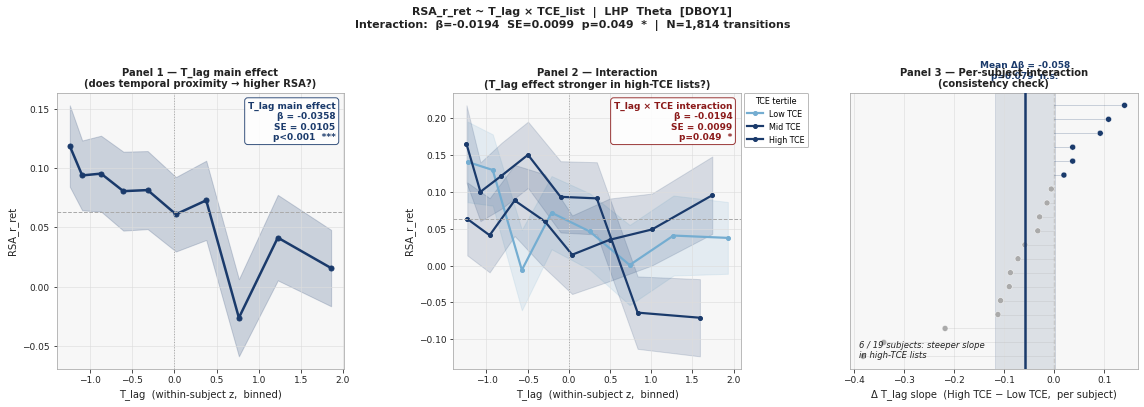

In [17]:
#!/usr/bin/env python3
"""
Single-stage transition-level LMM
==================================
RSA_r_ret ~ T_lag * TCE_list + (1 | subject / session / list)

Each row = one recall transition (word_i -> word_j) for one subject.
TCE_list = mean_T_clustering for that list, z-scored within subject.
T_lag    = temporal lag for that transition, z-scored within subject.

The interaction T_lag:TCE_list is the key term:
  "Do transitions with smaller T_lag show higher RSA,
   and is this effect stronger in lists with higher TCE?"

Random effects (nested):
  subject          — overall subject intercept
  subject/session  — session intercept within subject
  subject/session/list — list intercept within session

Outputs (./transition_lmm_tlag_tce/):
  transition_data_theta_lhp.csv   — merged transition-level table
  LMM_summary.txt                 — full statsmodels summary
  figure_transition_lmm.png       — 3-panel figure
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
COLOR_INT   = '#8B1A1A'   # interaction term
COLOR_NEG   = '#AAAAAA'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**'  if p < 0.01 else
            '*'   if p < 0.05  else 'n.s.')

def p_str(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# STEP 1 — Load RSA data (transition level)
# =============================================================================
print(f"\n{'='*65}")
print(f"Single-stage LMM  |  {REGION}  {BAND}  [{EXPERIMENT}]")
print(f"Model: {OUTCOME} ~ T_lag * TCE_list + random effects")
print(f"{'='*65}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)

print(f"\nTransitions loaded: {len(df):,}  ({df['subject'].nunique()} subjects)")
print(f"Columns: {df.columns.tolist()}")

# =============================================================================
# STEP 2 — Merge list-level TCE
# =============================================================================
tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

# Attach TCE_list to every transition row
df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
)
print(f"After TCE merge: {len(df):,} transitions  "
      f"({df['subject'].nunique()} subjects)")

# Drop rows missing outcome, T_lag, or TCE
df = df.dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])
print(f"After dropna:    {len(df):,} transitions")

# =============================================================================
# STEP 3 — Within-subject z-score T_lag and TCE_list
# =============================================================================
# Z-scoring within subject makes the betas interpretable as:
#   T_lag_z  : effect of T_lag at average TCE (main effect)
#   TCE_z    : effect of TCE at average T_lag (main effect)
#   T_lag_z:TCE_z : does the T_lag slope change with TCE? (interaction)

def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['TCE_z']   = df.groupby('subject')['mean_T_clustering'].transform(zscore_within)

# Grouping variables for nested random effects
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

# Save merged transition table
out_csv = OUT_DIR / f'transition_data_{BAND}_{REGION.lower()}.csv'
df.to_csv(out_csv, index=False)
print(f"\nSaved transition table: {out_csv.name}  ({len(df):,} rows)")

# =============================================================================
# STEP 4 — Fit LMM
#
# Model: RSA_r_ret ~ T_lag_z * TCE_z + random effects
#
# Random effects structure (nested):
#   groups     = subject          (top-level grouping)
#   vc_formula adds:
#     session within subject
#     list within session within subject
#
# This is the statsmodels way of specifying:
#   (1 | subject) + (1 | subject:session) + (1 | subject:session:list)
# =============================================================================
print(f"\nFitting LMM ...")
print(f"  Formula: {OUTCOME} ~ T_lag_z * TCE_z")
print(f"  Random:  (1|subject) + (1|subject:session) + (1|subject:session:list)")
print(f"  N transitions: {len(df):,}")
print(f"  N subjects:    {df['subject'].nunique()}")
print(f"  N sessions:    {df['subj_sess'].nunique()}")
print(f"  N lists:       {df['subj_sess_list'].nunique()}")

lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * TCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})  "
                  f"llf={lmm_result.llf:.2f}  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is None or not np.isfinite(lmm_result.llf):
    print("  WARNING: LMM did not converge.")
    raise RuntimeError("LMM failed — check data.")

# =============================================================================
# STEP 5 — Extract and print results
# =============================================================================
terms = {
    'Intercept':       'Intercept',
    'T_lag_z':         'T_lag  (main effect)',
    'TCE_z':           'TCE_list  (main effect)',
    'T_lag_z:TCE_z':   'T_lag × TCE_list  (interaction)',
}

print(f"\n{'='*65}")
print(f"LMM Results: {OUTCOME} ~ T_lag_z * TCE_z")
print(f"{'='*65}")
print(f"{'Term':<35} {'beta':>8} {'SE':>8} {'z':>7} {'p':>10} {'sig':>5}")
print(f"{'-'*65}")

results = {}
for col, label in terms.items():
    if col in lmm_result.params.index:
        b  = lmm_result.params[col]
        s  = lmm_result.bse[col]
        z  = lmm_result.tvalues[col]
        pv = lmm_result.pvalues[col]
        results[col] = dict(beta=b, se=s, z=z, p=pv, label=label)
        print(f"{label:<35} {b:>8.4f} {s:>8.4f} {z:>7.3f} "
              f"{pv:>10.4f} {sig_stars(pv):>5}")

print(f"{'-'*65}")
print(f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs):,} transitions")
print(f"{'='*65}")

# Save full summary
with open(OUT_DIR / 'LMM_summary.txt', 'w') as f:
    f.write(f"Model: {OUTCOME} ~ T_lag_z * TCE_z\n")
    f.write(f"Region: {REGION}  Band: {BAND}  Experiment: {EXPERIMENT}\n\n")
    f.write(str(lmm_result.summary()))
print(f"\nFull summary saved: LMM_summary.txt")

# =============================================================================
# FIGURE — 3-panel
# =============================================================================
fig = plt.figure(figsize=(16, 5.5))
fig.patch.set_facecolor('white')
axes = [fig.add_subplot(1, 3, i + 1) for i in range(3)]

# ── Panel 1: T_lag main effect
#    Mean RSA_r_ret by T_lag_z quintile  (collapsed across TCE)
# ──────────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
bin_stats = (df.groupby('tlag_bin')[OUTCOME]
               .agg(['mean', 'sem', lambda x: df.loc[x.index, 'T_lag_z'].mean()])
               .reset_index())
bin_stats.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(bin_stats['x_center'],
                bin_stats['mean'] - bin_stats['sem'],
                bin_stats['mean'] + bin_stats['sem'],
                color=COLOR, alpha=0.2)
ax.plot(bin_stats['x_center'], bin_stats['mean'],
        color=COLOR, lw=2.5, marker='o', ms=5)
ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--')
ax.axvline(0, color=SPINE_COLOR, lw=1, ls=':')

b_tlag = results.get('T_lag_z', {})
ax.text(0.97, 0.97,
        f"T_lag main effect\n"
        f"β = {b_tlag.get('beta', np.nan):.4f}\n"
        f"SE = {b_tlag.get('se', np.nan):.4f}\n"
        f"{p_str(b_tlag.get('p', np.nan))}  "
        f"{sig_stars(b_tlag.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR, alpha=0.85))

ax.set_xlabel('T_lag  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 1 — T_lag main effect\n(does temporal proximity → higher RSA?)',
             fontsize=10, fontweight='bold')

# ── Panel 2: Interaction — T_lag slope by TCE tertile
#    Split lists into low / mid / high TCE, plot RSA vs T_lag per group
# ──────────────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

df['tce_tertile'] = pd.qcut(df['TCE_z'], q=3, labels=['Low TCE', 'Mid TCE', 'High TCE'],
                              duplicates='drop')
tertile_colors = {'Low TCE': '#74ADD1', 'Mid TCE': COLOR, 'High TCE': '#1A3A6B'}

for tertile, tdf in df.groupby('tce_tertile', observed=True):
    tdf = tdf.copy()
    tdf['tlag_bin2'] = pd.qcut(tdf['T_lag_z'], q=8, labels=False,
                                duplicates='drop')
    bs = (tdf.groupby('tlag_bin2')[OUTCOME]
             .agg(['mean', 'sem',
                   lambda x: tdf.loc[x.index, 'T_lag_z'].mean()])
             .reset_index())
    bs.columns = ['bin', 'mean', 'sem', 'x_center']
    c = tertile_colors[str(tertile)]
    ax.fill_between(bs['x_center'],
                    bs['mean'] - bs['sem'],
                    bs['mean'] + bs['sem'],
                    color=c, alpha=0.15)
    ax.plot(bs['x_center'], bs['mean'],
            color=c, lw=2.2, marker='o', ms=4,
            label=str(tertile))

ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--')
ax.axvline(0, color=SPINE_COLOR, lw=1, ls=':')

b_int = results.get('T_lag_z:TCE_z', {})
ax.text(0.97, 0.97,
        f"T_lag × TCE interaction\n"
        f"β = {b_int.get('beta', np.nan):.4f}\n"
        f"SE = {b_int.get('se', np.nan):.4f}\n"
        f"{p_str(b_int.get('p', np.nan))}  "
        f"{sig_stars(b_int.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR_INT, alpha=0.85))

ax.set_xlabel('T_lag  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 2 — Interaction\n(T_lag effect stronger in high-TCE lists?)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.01, 1.0),
          borderaxespad=0, title='TCE tertile', title_fontsize=8)

# ── Panel 3: Per-subject interaction slopes (robustness check)
#    For each subject: OLS slope of RSA ~ T_lag_z separately
#    for low-TCE and high-TCE lists → ranked dot plot of difference
# ──────────────────────────────────────────────────────────────────
ax = axes[2]
style(ax)

subj_diffs = []
for subj, sg in df.groupby('subject'):
    sg = sg.dropna(subset=['T_lag_z', OUTCOME, 'tce_tertile'])
    lo = sg[sg['tce_tertile'] == 'Low TCE']
    hi = sg[sg['tce_tertile'] == 'High TCE']
    if len(lo) < 3 or len(hi) < 3:
        continue
    if lo['T_lag_z'].std() == 0 or hi['T_lag_z'].std() == 0:
        continue
    m_lo, _ = np.polyfit(lo['T_lag_z'].values, lo[OUTCOME].values, 1)
    m_hi, _ = np.polyfit(hi['T_lag_z'].values, hi[OUTCOME].values, 1)
    subj_diffs.append(m_hi - m_lo)   # positive = steeper slope in high-TCE lists

subj_diffs = np.array(subj_diffs)
n_sd       = len(subj_diffs)
order      = np.argsort(subj_diffs)
y_pos      = np.arange(n_sd)
ms_d       = subj_diffs.mean()
ci95_d     = 1.96 * subj_diffs.std() / np.sqrt(n_sd)
n_pos_d    = (subj_diffs > 0).sum()
from scipy.stats import ttest_1samp
t_d, p_d   = ttest_1samp(subj_diffs, 0)
p_d_str    = p_str(p_d)

dot_colors = [COLOR if s >= 0 else COLOR_NEG for s in subj_diffs[order]]
ax.scatter(subj_diffs[order], y_pos, c=dot_colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.4)
for yi, si, dc in zip(y_pos, subj_diffs[order], dot_colors):
    ax.plot([0, si], [yi, yi], color=dc, alpha=0.3, lw=0.7, zorder=2)

ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
ax.axvspan(ms_d - ci95_d, ms_d + ci95_d, color=COLOR, alpha=0.12, zorder=0)
ax.axvline(ms_d, color=COLOR, lw=2.5, zorder=4)
ax.text(ms_d, n_sd + 0.8,
        f'Mean Δβ = {ms_d:.3f}\n{p_d_str}  {sig_stars(p_d)}',
        ha='center', va='bottom', color=COLOR,
        fontsize=9, fontweight='bold')
ax.text(0.03, 0.04,
        f'{n_pos_d} / {n_sd} subjects: steeper slope\nin high-TCE lists',
        transform=ax.transAxes, fontsize=8.5,
        color=TEXT_COLOR, style='italic')

ax.set_yticks([])
ax.set_xlabel('Δ T_lag slope  (High TCE − Low TCE,  per subject)', fontsize=10)
ax.set_title('Panel 3 — Per-subject interaction\n(consistency check)',
             fontsize=10, fontweight='bold')

# ── Super-title ────────────────────────────────────────────────────────────────
b_int_val = results.get('T_lag_z:TCE_z', {})
fig.suptitle(
    f'{OUTCOME} ~ T_lag × TCE_list  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]\n'
    f'Interaction:  β={b_int_val.get("beta", np.nan):.4f}  '
    f'SE={b_int_val.get("se", np.nan):.4f}  '
    f'{p_str(b_int_val.get("p", np.nan))}  '
    f'{sig_stars(b_int_val.get("p", np.nan))}  '
    f'|  N={int(lmm_result.nobs):,} transitions',
    fontsize=11, fontweight='bold', y=1.02, color=TEXT_COLOR)

# Leave extra room on the right of Panel 2 for the outside legend
plt.tight_layout()
plt.subplots_adjust(wspace=0.38)   # a bit more horizontal space between panels
fig_path = OUT_DIR / 'figure_transition_lmm.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*65}")
print("DONE")
print(f"{'='*65}\n")

N transitions: 1,814  |  N subjects: 27
Converged (lbfgs)  AIC=nan

T_lag_z:      beta=-0.0358  SE=0.0105  p<0.001  ***
Interaction:  beta=-0.0194  SE=0.0099  p=0.049  *

Figure saved: transition_lmm_tlag_tce_zscore/figure_p1p2.png


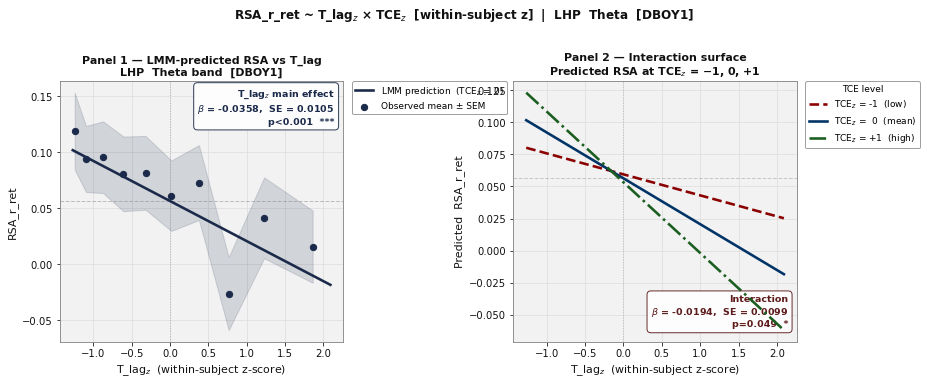

In [18]:
#!/usr/bin/env python3
"""
Figure: Panel 1 + Panel 2
==========================
Panel 1 — LMM-predicted RSA vs T_lag_z  (TCE_z = 0)
Panel 2 — Interaction: 3 lines at TCE_z = -1, 0, +1
White background, dark rich colors. Legends outside. No stats in title.
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce_zscore')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette — white background, dark rich colors ───────────────────────────────
BG          = 'white'
AX_COLOR    = '#F2F2F2'
GRID_COLOR  = '#DCDCDC'
SPINE_COLOR = '#888888'
TEXT_COLOR  = '#111111'

# Panel 1 — observed + prediction
COLOR_OBS  = '#1B2A4A'   # very dark navy

# Panel 2 — 3 interaction lines, clearly distinct, all dark
LINE_PROPS = {
    'TCE$_z$ = -1  (low)':  dict(color='#8B0000', ls='--',  lw=2.6),  # dark red
    'TCE$_z$ =  0  (mean)': dict(color='#003366', ls='-',   lw=2.6),  # dark blue
    'TCE$_z$ = +1  (high)': dict(color='#1B5E20', ls='-.',  lw=2.6),  # dark green
}

# annotation box color for interaction stats
COLOR_INT = '#5C1A1A'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.7, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.9)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# Load & prepare
# =============================================================================
df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)

tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
).dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])

def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['TCE_z']   = df.groupby('subject')['mean_T_clustering'].transform(zscore_within)
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

print(f"N transitions: {len(df):,}  |  N subjects: {df['subject'].nunique()}")

# =============================================================================
# Fit LMM
# =============================================================================
lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * TCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"Converged ({method})  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"{method} failed: {e}")

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge.")

b0     = lmm_result.params['Intercept']
b_t    = lmm_result.params['T_lag_z']
b_c    = lmm_result.params['TCE_z']
b_int  = lmm_result.params['T_lag_z:TCE_z']
se_t   = lmm_result.bse['T_lag_z']
se_int = lmm_result.bse['T_lag_z:TCE_z']
p_t    = lmm_result.pvalues['T_lag_z']
p_int  = lmm_result.pvalues['T_lag_z:TCE_z']

def predict(t, c):
    return b0 + b_t * t + b_c * c + b_int * t * c

t_grid = np.linspace(df['T_lag_z'].quantile(0.02),
                     df['T_lag_z'].quantile(0.98), 300)

print(f"\nT_lag_z:      beta={b_t:.4f}  SE={se_t:.4f}  {fmt_p(p_t)}  {sig_stars(p_t)}")
print(f"Interaction:  beta={b_int:.4f}  SE={se_int:.4f}  {fmt_p(p_int)}  {sig_stars(p_int)}")

# =============================================================================
# FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.patch.set_facecolor(BG)

# ── Panel 1 ───────────────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
obs = (df.groupby('tlag_bin')[OUTCOME]
         .agg(['mean', 'sem',
               lambda x: df.loc[x.index, 'T_lag_z'].mean()])
         .reset_index())
obs.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(obs['x_center'],
                obs['mean'] - obs['sem'],
                obs['mean'] + obs['sem'],
                color=COLOR_OBS, alpha=0.15, zorder=2)
ax.scatter(obs['x_center'], obs['mean'],
           color=COLOR_OBS, s=40, zorder=4,
           label='Observed mean ± SEM')
ax.plot(t_grid, predict(t_grid, 0.0),
        color=COLOR_OBS, lw=2.6, zorder=5,
        label='LMM prediction  (TCE$_z$ = 0)')

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.5)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.5)

ax.text(0.97, 0.97,
        f"T_lag$_z$ main effect\n"
        f"$\\beta$ = {b_t:.4f},  SE = {se_t:.4f}\n"
        f"{fmt_p(p_t)}  {sig_stars(p_t)}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
        color=COLOR_OBS, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_OBS, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(OUTCOME, fontsize=11)
ax.set_title(f'Panel 1 — LMM-predicted RSA vs T_lag\n'
             f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0)

# ── Panel 2 ───────────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

tce_levels = {
    'TCE$_z$ = -1  (low)':   -1.0,
    'TCE$_z$ =  0  (mean)':   0.0,
    'TCE$_z$ = +1  (high)':  +1.0,
}

for label, c_val in tce_levels.items():
    props = LINE_PROPS[label]
    ax.plot(t_grid, predict(t_grid, c_val),
            color=props['color'], ls=props['ls'], lw=props['lw'],
            label=label, zorder=4)

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.4)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.4)

ax.text(0.97, 0.05,
        f"Interaction\n"
        f"$\\beta$ = {b_int:.4f},  SE = {se_int:.4f}\n"
        f"{fmt_p(p_int)}  {sig_stars(p_int)}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_INT, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(f'Predicted  {OUTCOME}', fontsize=11)
ax.set_title(f'Panel 2 — Interaction surface\n'
             f'Predicted RSA at TCE$_z$ = \u22121, 0, +1',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0, title='TCE level', title_fontsize=9)

# ── Shared super-title (no stats) ─────────────────────────────────────────────
fig.suptitle(
    f'{OUTCOME} ~ T_lag$_z$ \u00d7 TCE$_z$  '
    f'[within-subject z]  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]',
    fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
fig_path = OUT_DIR / 'figure_p1p2.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"\nFigure saved: {fig_path}")